## Setup and verified binary labels

Malignant: BCC/MEL/SCC = indices 1/4/6. AK is grouped as non-malignant for this task, not as healthy skin. Re-running setup creates a new run folder.


In [1]:
import hashlib
import importlib.metadata
import json
import math
import os
import platform
import random
import sys
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from scipy.optimize import minimize_scalar
from scipy.special import expit, logsumexp, softmax
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

# CHANGE ONLY THIS PATH if the project is in a different folder.
PROJECT_PATH = Path(r"C:\SRS(ISIC_2019)")
DATASET_PATH = PROJECT_PATH / "Dataset"
# Optional ISIC metadata CSV with columns image and lesion_id (or patient_id).
METADATA_CSV = DATASET_PATH / "ISIC_2019_Training_Metadata.csv"

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 4
ACCUMULATION_STEPS = 4
MAX_EPOCHS = 20
WARMUP_EPOCHS = 3
PATIENCE = 4
MIN_DELTA = 1e-4
CHECK_EXACT_DUPLICATES = True
NUM_WORKERS = 0  # Safe for Windows notebooks.
RUN_FL = False  # The old FL section is an inactive reference only.

LABEL_NAMES = ("AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC")
classes = list(LABEL_NAMES)
MALIGNANT_INDICES = (1, 4, 6)
malignant_classes = list(MALIGNANT_INDICES)


def get_binary_label(label):
    label = int(label)
    if not 0 <= label < 8:
        raise ValueError(f"Invalid class label: {label}")
    return int(label in MALIGNANT_INDICES)


assert [get_binary_label(i) for i in range(8)] == [0, 1, 0, 0, 1, 0, 1, 0]


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"

if not DATASET_PATH.is_dir():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_PATH}. Fix PROJECT_PATH first."
    )

RUN_DIR = (
    PROJECT_PATH
    / "centralized_runs"
    / (datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + "_" + uuid4().hex[:8])
)
RUN_DIR.mkdir(parents=True, exist_ok=False)

config = {
    "seed": SEED,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "accumulation_steps": ACCUMULATION_STEPS,
    "max_epochs": MAX_EPOCHS,
    "warmup_epochs": WARMUP_EPOCHS,
    "patience": PATIENCE,
    "min_delta": MIN_DELTA,
    "classes": list(LABEL_NAMES),
    "malignant_indices": list(MALIGNANT_INDICES),
    "initialization": "Fresh ImageNet backbones; fresh task heads; no old ISIC checkpoint",
    "binary_loss_weight": 0.5,
    "training_class_weights": "normalized inverse square root counts",
    "protocol": "centralized only; train/validation/calibration/test separated",
    "python": platform.python_version(),
    "device": str(device),
}
(RUN_DIR / "config.json").write_text(
    json.dumps(config, indent=2), encoding="utf-8"
)

packages = [
    "torch",
    "torchvision",
    "timm",
    "numpy",
    "pandas",
    "scikit-learn",
    "scipy",
    "pillow",
    "matplotlib",
    "tqdm",
]
(RUN_DIR / "environment.txt").write_text(
    "\n".join(
        f"{name}=={importlib.metadata.version(name)}" for name in packages
    ),
    encoding="utf-8",
)

print("Binary label mapping verified:", malignant_classes)
print("Device:", device, "| Run:", RUN_DIR)
if device.type == "cpu":
    print(
        "CPU selected: four-backbone training will be slow. Check the notebook GPU environment."
    )


Binary label mapping verified: [1, 4, 6]
Device: cuda | Run: C:\SRS(ISIC_2019)\centralized_runs\20260923_022915_3c7da17d


### Step 1 — Backup baseline and prepare fine-tuning folder(2nd tuning)

In [2]:
from pathlib import Path
from datetime import datetime
from uuid import uuid4
import hashlib
import json
import shutil
import os


PROJECT_PATH = Path(r"C:\SRS(ISIC_2019)")

# আগের সম্পূর্ণ training run।
BASELINE_RUN = (
    PROJECT_PATH
    / "centralized_runs"
    / "20260922_025359_c4131415"
)

BASELINE_MODEL_PATH = BASELINE_RUN / "best_centralized_model.pth"

# একই baseline-এর backup বারবার তৈরি হবে না।
BACKUP_DIR = PROJECT_PATH / "baseline_backups" / BASELINE_RUN.name


def sha256_file(path):
    hasher = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(block)
    return hasher.hexdigest()


# 1. প্রয়োজনীয় source files আছে কি না দেখো।
required_files = [
    "best_centralized_model.pth",
    "calibration.json",
    "config.json",
    "split_train.csv",
    "split_validation.csv",
    "split_calibration.csv",
    "split_test.csv",
    "training_history.csv",
]

missing = [
    name for name in required_files
    if not (BASELINE_RUN / name).is_file()
]

if missing:
    raise FileNotFoundError(
        f"Missing files in {BASELINE_RUN}:\n"
        + "\n".join(missing)
    )

source_files = sorted(
    path for path in BASELINE_RUN.rglob("*")
    if path.is_file()
)

if not source_files:
    raise RuntimeError("Baseline folder is empty.")


# 2. পুরো baseline folder backup করো।
# অসম্পূর্ণ copy-কে final backup হিসেবে ব্যবহার করা হবে না।
if not BACKUP_DIR.exists():
    BACKUP_DIR.parent.mkdir(parents=True, exist_ok=True)

    temporary_backup = BACKUP_DIR.with_name(
        BACKUP_DIR.name + "_copying_" + uuid4().hex[:8]
    )

    print("Copying baseline model and results...")

    shutil.copytree(BASELINE_RUN, temporary_backup)

    for source in source_files:
        relative = source.relative_to(BASELINE_RUN)
        copied = temporary_backup / relative

        if sha256_file(source) != sha256_file(copied):
            raise RuntimeError(
                f"Backup verification failed: {relative}\n"
                f"Incomplete copy retained at: {temporary_backup}"
            )

    os.replace(temporary_backup, BACKUP_DIR)
    print("Baseline backup created and verified.")

else:
    # পুরোনো backup overwrite না করে যাচাই করো।
    print("Existing backup found. Verifying...")

    for source in source_files:
        relative = source.relative_to(BASELINE_RUN)
        copied = BACKUP_DIR / relative

        if not copied.is_file():
            raise RuntimeError(
                f"Existing backup is missing: {relative}"
            )

        if sha256_file(source) != sha256_file(copied):
            raise RuntimeError(
                f"Source and backup differ: {relative}. "
                "Neither file was overwritten."
            )

    print("Existing baseline backup verified.")


# 3. এই kernel session-এ cell আবার চালালে একই folder রাখবে।
if "FT_RUN_DIR" not in globals():
    run_name = (
        "cb_finetune_"
        + datetime.now().strftime("%Y%m%d_%H%M%S")
        + "_"
        + uuid4().hex[:8]
    )

    FT_RUN_DIR = PROJECT_PATH / "centralized_finetuning_runs" / run_name
    FT_RUN_DIR.mkdir(parents=True, exist_ok=False)

    experiment_info = {
        "baseline_run": str(BASELINE_RUN),
        "baseline_backup": str(BACKUP_DIR),
        "baseline_model_sha256": sha256_file(BASELINE_MODEL_PATH),
        "planned_multiclass_loss": "Effective-number Class-Balanced CE",
        "split_policy": "Reuse saved baseline splits",
        "status": "Prepared; training has not started",
    }

    (FT_RUN_DIR / "experiment_info.json").write_text(
        json.dumps(experiment_info, indent=2),
        encoding="utf-8",
    )

else:
    FT_RUN_DIR = Path(FT_RUN_DIR)
    info_path = FT_RUN_DIR / "experiment_info.json"

    if not info_path.is_file():
        raise RuntimeError(
            "FT_RUN_DIR exists in memory but its experiment file is missing."
        )

    experiment_info = json.loads(info_path.read_text(encoding="utf-8"))

    if (
        experiment_info["baseline_model_sha256"]
        != sha256_file(BASELINE_MODEL_PATH)
    ):
        raise RuntimeError("Fine-tuning folder refers to another baseline.")

    print("Reusing this session's fine-tuning folder.")


print("\nSTEP 1 COMPLETED")
print("Baseline model:", BASELINE_MODEL_PATH)
print("Verified backup:", BACKUP_DIR)
print("Fine-tuning output:", FT_RUN_DIR)
print("Training started: NO")
print("Original model and results: unchanged")

Existing backup found. Verifying...
Existing baseline backup verified.

STEP 1 COMPLETED
Baseline model: C:\SRS(ISIC_2019)\centralized_runs\20260922_025359_c4131415\best_centralized_model.pth
Verified backup: C:\SRS(ISIC_2019)\baseline_backups\20260922_025359_c4131415
Fine-tuning output: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_20260923_082916_350c91c8
Training started: NO
Original model and results: unchanged


## Original data and disjoint splits(2nd tuning)


In [3]:
from pathlib import Path
from itertools import combinations
import hashlib
import shutil

import numpy as np
import pandas as pd
from IPython.display import display


# Step 1 চালানো হয়েছে কি না পরীক্ষা।
if not all(
    name in globals()
    for name in ("BASELINE_RUN", "BACKUP_DIR", "FT_RUN_DIR")
):
    raise RuntimeError("আগে Step 1 backup cell চালাও।")

LABEL_NAMES = (
    "AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"
)
MALIGNANT_INDICES = (1, 4, 6)

split_names = ("train", "validation", "calibration", "test")
required_columns = (
    "image_path", "image_id", "label", "group_id", "sha256"
)


def split_file_hash(path):
    hasher = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(block)
    return hasher.hexdigest()


# 1. Baseline-এর manifest backup-এর সঙ্গে মিলিয়ে load।
restored_splits = {}

for name in split_names:
    source = BASELINE_RUN / f"split_{name}.csv"
    backup = BACKUP_DIR / source.name

    if not source.is_file() or not backup.is_file():
        raise FileNotFoundError(
            f"Source or backup manifest missing: {source.name}"
        )

    if split_file_hash(source) != split_file_hash(backup):
        raise ValueError(
            f"Baseline manifest changed after backup: {source.name}"
        )

    frame = pd.read_csv(
        source,
        dtype={
            "image_path": str,
            "image_id": str,
            "group_id": str,
            "sha256": str,
        },
    )

    if not set(required_columns).issubset(frame.columns):
        raise ValueError(f"Missing manifest columns: {name}")

    if frame.empty or frame[list(required_columns)].isna().any().any():
        raise ValueError(f"Empty or incomplete manifest: {name}")

    for column in ("image_path", "image_id", "group_id", "sha256"):
        if frame[column].str.strip().eq("").any():
            raise ValueError(f"Blank {column} in {name}")

    labels = pd.to_numeric(frame["label"], errors="raise")

    if not labels.isin(range(len(LABEL_NAMES))).all():
        raise ValueError(f"Invalid class labels: {name}")

    frame["label"] = labels.astype(int)

    if set(frame["label"]) != set(range(len(LABEL_NAMES))):
        raise ValueError(f"A class is missing from {name}")

    if frame["image_id"].str.casefold().duplicated().any():
        raise ValueError(f"Repeated image IDs in {name}")

    if not frame["sha256"].str.fullmatch(r"[0-9a-fA-F]{64}").all():
        raise ValueError(f"Invalid image hashes in {name}")

    restored_splits[name] = frame.reset_index(drop=True)


# 2. Split-গুলোর মধ্যে image, group ও recorded hash overlap পরীক্ষা।
for (name_a, a), (name_b, b) in combinations(
    restored_splits.items(), 2
):
    for column in ("image_id", "group_id", "sha256"):
        values_a = a[column]
        values_b = b[column]

        if column in ("image_id", "sha256"):
            values_a = values_a.str.casefold()
            values_b = values_b.str.casefold()

        if not set(values_a).isdisjoint(set(values_b)):
            raise ValueError(
                f"{column} overlap: {name_a} / {name_b}"
            )


# 3. Recorded image hashes-এর label conflict পরীক্ষা।
combined = pd.concat(restored_splits.values(), ignore_index=True)
combined["_hash"] = combined["sha256"].str.lower()

if combined.groupby("_hash")["label"].nunique().gt(1).any():
    raise ValueError("Conflicting labels remain in the saved manifests.")


# 4. সব image path এখনো পাওয়া যাচ্ছে কি না দেখো।
missing_images = [
    path for path in combined["image_path"]
    if not Path(path).is_file()
]

if missing_images:
    raise FileNotFoundError(
        f"{len(missing_images)} images were not found. Examples:\n"
        + "\n".join(missing_images[:5])
    )


# 5. নতুন experiment folder-এ exact manifest copies রাখো।
FT_RUN_DIR = Path(FT_RUN_DIR)

for name in split_names:
    source = BASELINE_RUN / f"split_{name}.csv"
    destination = FT_RUN_DIR / source.name

    if destination.exists():
        if split_file_hash(source) != split_file_hash(destination):
            raise ValueError(
                f"Fine-tuning manifest differs: {destination.name}"
            )
    else:
        shutil.copy2(source, destination)

    if split_file_hash(source) != split_file_hash(destination):
        raise RuntimeError(f"Copy verification failed: {source.name}")


# 6. পরের loader cell-এর জন্য variables।
train_df = restored_splits["train"]
val_df = restored_splits["validation"]
calibration_df = restored_splits["calibration"]
test_df = restored_splits["test"]

splits = restored_splits

# পরবর্তী output নতুন fine-tuning folder-এ যাবে।
RUN_DIR = FT_RUN_DIR


# 7. Class counts দেখাও।
summary = pd.DataFrame({
    name: frame["label"].value_counts()
    for name, frame in restored_splits.items()
}).reindex(range(len(LABEL_NAMES))).fillna(0).astype(int)

summary.index = LABEL_NAMES
summary.index.name = "class"

summary.to_csv(FT_RUN_DIR / "split_counts.csv")

print("STEP 2 COMPLETED")
print("Saved baseline splits restored.")
print("Manifest image/group/hash overlap checks: PASSED")
print("Image paths available:", len(combined))
print("New splitting or oversampling: NO")
print("Training started: NO")
print("\nClass distribution:")
display(summary)

print("\nTotals:", {
    name: len(frame)
    for name, frame in restored_splits.items()
})
print("\nFine-tuning output folder:", FT_RUN_DIR)

STEP 2 COMPLETED
Saved baseline splits restored.
Manifest image/group/hash overlap checks: PASSED
Image paths available: 25327
New splitting or oversampling: NO
Training started: NO

Class distribution:


,train,validation,calibration,test
class,,,,
AK,609,86,43,129
BCC,2327,332,166,498
BKL,1835,262,132,395
DF,168,24,12,35
MEL,3164,452,226,678
NV,9012,1287,643,1931
SCC,438,63,32,95
VASC,178,26,12,37



Totals: {'train': 17731, 'validation': 2532, 'calibration': 1266, 'test': 3798}

Fine-tuning output folder: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_20260923_082916_350c91c8


## Transforms and loaders(2nd Tuning)

No oversampling. Augmentation applies to training only. Batch size 4 with four gradient accumulation steps gives a nominal effective batch size 16; BatchNorm still sees physical batches of 4.


In [4]:
import random

import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


# Step 2-এর restored dataframes প্রয়োজন।
required_variables = (
    "train_df", "val_df", "calibration_df", "test_df"
)

if not all(name in globals() for name in required_variables):
    raise RuntimeError("আগে Step 2 saved split restore cell চালাও।")


SEED = 42
IMG_SIZE = 224

# আগের baseline-এর batch settings।
BATCH_SIZE = 4
ACCUMULATION_STEPS = 4

# Windows notebook-এর জন্য আগের setting রাখছি।
NUM_WORKERS = 0

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
USE_AMP = device.type == "cuda"


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


seed_everything(SEED)


# 1. Augmentation শুধু training images-এর জন্য।
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


# 2. Validation/calibration/test-এর জন্য deterministic transform।
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class ISICDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long,
        )

        return image, label


def make_loader(frame, training=False):
    return DataLoader(
        dataset=ISICDataset(
            frame,
            train_transform if training else val_transform,
        ),
        batch_size=BATCH_SIZE,
        shuffle=training,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
        generator=torch.Generator().manual_seed(SEED),
    )


# 3. Restored splits থেকে loaders।
train_loader = make_loader(train_df, training=True)
val_loader = make_loader(val_df)
calibration_loader = make_loader(calibration_df)
test_loader = make_loader(test_df)


# 4. Validation batch দিয়ে shape এবং values পরীক্ষা।
# Training loader-এর shuffle/augmentation state বদলাবে না।
sample_images, sample_labels = next(iter(val_loader))

if tuple(sample_images.shape[1:]) != (3, IMG_SIZE, IMG_SIZE):
    raise ValueError("Unexpected image tensor shape.")

if not torch.isfinite(sample_images).all():
    raise ValueError("Non-finite values found in image tensors.")

if sample_labels.dtype != torch.long:
    raise ValueError("Class labels must have torch.long dtype.")

if not ((sample_labels >= 0) & (sample_labels < 8)).all():
    raise ValueError("Invalid class labels.")


print("STEP 3 COMPLETED")
print("Configured compute device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(device))

print("\nDataset sizes:")
print("Train:", len(train_loader.dataset))
print("Validation:", len(val_loader.dataset))
print("Calibration:", len(calibration_loader.dataset))
print("Test:", len(test_loader.dataset))

print("\nBatches per epoch:")
print("Train:", len(train_loader))
print("Validation:", len(val_loader))
print("Calibration:", len(calibration_loader))
print("Test:", len(test_loader))

print("\nValidation batch shape:", tuple(sample_images.shape))
print("Label batch shape:", tuple(sample_labels.shape))
print("Batch checks: PASSED")

print("\nPhysical batch size:", BATCH_SIZE)
print("Gradient accumulation steps:", ACCUMULATION_STEPS)
print(
    "Nominal effective training batch:",
    BATCH_SIZE * ACCUMULATION_STEPS,
)

print("Training sampler:", type(train_loader.sampler).__name__)
print("Oversampling: NO")
print("Training started: NO")

STEP 3 COMPLETED
Configured compute device: cuda
GPU: NVIDIA GeForce RTX 4090

Dataset sizes:
Train: 17731
Validation: 2532
Calibration: 1266
Test: 3798

Batches per epoch:
Train: 4433
Validation: 633
Calibration: 317
Test: 950

Validation batch shape: (4, 3, 224, 224)
Label batch shape: (4,)
Batch checks: PASSED

Physical batch size: 4
Gradient accumulation steps: 4
Nominal effective training batch: 16
Training sampler: RandomSampler
Oversampling: NO
Training started: NO


## Four-backbone fusion model

Preserves EfficientNet-B3, ResNet50, DenseNet121 and ViT-small. Fresh task heads are trained on corrected targets. Backbone ImageNet weights are used, not the old ISIC checkpoint.


In [5]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Channel attention
        ca = self.channel_attention(x)
        x = x * ca

        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sa = self.spatial_attention(torch.cat([avg_out, max_out], dim=1))
        x = x * sa

        return x


class MultiSampleDropout(nn.Module):
    def __init__(self, dropout_num=4, dropout_rate=0.5):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(dropout_rate) for _ in range(dropout_num)])

    def forward(self, x):
        outputs = []
        for dropout in self.dropouts:
            outputs.append(dropout(x))
        return outputs


class FeatureExtractor(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.efficientnet = timm.create_model("efficientnet_b3", pretrained=pretrained, features_only=True)
        self.resnet = timm.create_model("resnet50", pretrained=pretrained, features_only=True)
        self.densenet = timm.create_model("densenet121", pretrained=pretrained, features_only=True)
        self.vit = timm.create_model("vit_small_patch16_224", pretrained=pretrained)

    def forward(self, x):
        eff = self.efficientnet(x)[-1]
        res = self.resnet(x)[-1]
        dense = self.densenet(x)[-1]
        vit = self.vit.forward_features(x)

        return eff, res, dense, vit


class ISIC_Fusion_Model(nn.Module):
    def __init__(self, num_classes=8, pretrained=True):
        super().__init__()
        self.features = FeatureExtractor(pretrained=pretrained)

        # Actual feature channels: EfficientNet=384, ResNet=2048, DenseNet=1024, ViT=384 (Total = 3840)
        self.fusion = nn.Sequential(
            nn.Conv2d(3840, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        self.cbam = CBAM(512)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = MultiSampleDropout(dropout_num=4, dropout_rate=0.5)
        self.binary_classifier = nn.Linear(512, 1)
        self.class_classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        eff, res, dense, vit = self.features(x)

        # -----------------------------
        # ViT Feature Handling
        # -----------------------------
        if len(vit.shape) == 3:
            B, N, C = vit.shape

            # Remove CLS token (ViT output = [B, 197, 384])
            if N == 197:
                vit = vit[:, 1:, :]
                N = vit.shape[1]

            size = int(N ** 0.5)
            if size * size != N:
                raise ValueError(f"Unexpected ViT token count: {N}")
            vit = vit.permute(0, 2, 1)
            vit = vit.reshape(B, C, size, size)

        # -----------------------------
        # Resize feature maps
        # -----------------------------
        target_size = eff.shape[-2:]
        res = F.interpolate(res, size=target_size, mode="bilinear", align_corners=False)
        dense = F.interpolate(dense, size=target_size, mode="bilinear", align_corners=False)
        vit = F.interpolate(vit, size=target_size, mode="bilinear", align_corners=False)

        # -----------------------------
        # Feature Fusion
        # -----------------------------
        combined = torch.cat([eff, res, dense, vit], dim=1)
        x = self.fusion(combined)

        # CBAM Attention & Global pooling
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)

        # -----------------------------
        # Multi Sample Dropout
        # -----------------------------
        outputs = []
        dropout_features = self.dropout(x)

        for feature in dropout_features:
            binary_out = self.binary_classifier(feature)
            class_out = self.class_classifier(feature)
            outputs.append((binary_out, class_out))

        return outputs


### Step 4 — Load baseline weights for fine-tuning(2nd tuning)

In [6]:
from pathlib import Path
import hashlib

import torch


# আগের steps-এর প্রয়োজনীয় variables।
required_variables = (
    "BASELINE_MODEL_PATH",
    "FT_RUN_DIR",
    "ISIC_Fusion_Model",
    "LABEL_NAMES",
    "MALIGNANT_INDICES",
    "device",
    "IMG_SIZE",
)

missing = [
    name for name in required_variables
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "আগের steps ও architecture cell চালাও। Missing: "
        + ", ".join(missing)
    )


def checkpoint_sha256(path):
    hasher = hashlib.sha256()

    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(block)

    return hasher.hexdigest()


# 1. Baseline checkpoint load।
BASELINE_MODEL_PATH = Path(BASELINE_MODEL_PATH)

if not BASELINE_MODEL_PATH.is_file():
    raise FileNotFoundError(BASELINE_MODEL_PATH)

baseline_checkpoint = torch.load(
    BASELINE_MODEL_PATH,
    map_location="cpu",
    weights_only=True,
)

if tuple(baseline_checkpoint["classes"]) != tuple(LABEL_NAMES):
    raise ValueError("Checkpoint class order mismatch.")

if tuple(baseline_checkpoint["malignant_indices"]) != tuple(
    MALIGNANT_INDICES
):
    raise ValueError("Checkpoint binary label mapping mismatch.")

checkpoint_image_size = baseline_checkpoint.get(
    "config", {}
).get("image_size")

if (
    checkpoint_image_size is not None
    and int(checkpoint_image_size) != IMG_SIZE
):
    raise ValueError("Checkpoint image size differs from preprocessing.")

BASELINE_EPOCH = int(baseline_checkpoint["epoch"])

if BASELINE_EPOCH != 9:
    raise ValueError(
        f"Expected the selected epoch 9 checkpoint, found epoch "
        f"{BASELINE_EPOCH}. Check BASELINE_MODEL_PATH."
    )

BASELINE_SHA256 = checkpoint_sha256(BASELINE_MODEL_PATH)


# 2. আলাদা model object তৈরি করে trained weights বসাও।
# এই cell training শুরু হওয়ার পরে আবার চালাবে না:
# আবার চালালে in-memory ft_model baseline weights-এ ফিরে যাবে।
if "ft_model" in globals():
    del ft_model

if device.type == "cuda":
    torch.cuda.empty_cache()

ft_model = ISIC_Fusion_Model(
    num_classes=len(LABEL_NAMES),
    pretrained=False,
)

ft_model.load_state_dict(
    baseline_checkpoint["state_dict"],
    strict=True,
)

ft_model = ft_model.to(device)
ft_model.eval()


# 3. Fine-tuning শুরু না হওয়া পর্যন্ত gradients বন্ধ রাখো।
# Training configuration cell-এ প্রয়োজনীয় parameters unfreeze করব।
for parameter in ft_model.parameters():
    parameter.requires_grad = False


# 4. প্রথম validation batch দিয়ে forward-pass পরীক্ষা।
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.inference_mode():
    with torch.autocast(
        device_type=device.type,
        enabled=USE_AMP,
    ):
        outputs = ft_model(images)

        binary_logits = torch.stack([
            binary.squeeze(1).float()
            for binary, multiclass in outputs
        ]).mean(dim=0)

        multiclass_logits = torch.stack([
            multiclass.float()
            for binary, multiclass in outputs
        ]).mean(dim=0)

if binary_logits.shape != (len(labels),):
    raise ValueError("Unexpected binary output shape.")

if multiclass_logits.shape != (len(labels), len(LABEL_NAMES)):
    raise ValueError("Unexpected multiclass output shape.")

if (
    not torch.isfinite(binary_logits).all()
    or not torch.isfinite(multiclass_logits).all()
):
    raise ValueError("Non-finite model outputs.")


# 5. পরের ধাপগুলোর জন্য baseline তথ্য রাখো।
BASELINE_SAVED_METRICS = dict(
    baseline_checkpoint.get("metrics", {})
)

# CPU checkpoint tensors-এর অতিরিক্ত memory ছেড়ে দাও।
del baseline_checkpoint

print("STEP 4 COMPLETED")
print("Baseline epoch loaded:", BASELINE_EPOCH)
print("Weights loaded strictly: YES")
print("Model device:", next(ft_model.parameters()).device)
print("Evaluation mode:", not ft_model.training)

print("\nForward-pass checks:")
print("Binary logits shape:", tuple(binary_logits.shape))
print("Multiclass logits shape:", tuple(multiclass_logits.shape))
print("Finite outputs: YES")

print("\nParameters temporarily frozen: YES")
print("Fine-tuning model variable: ft_model")
print("Training started: NO")
print("Baseline checkpoint on disk: unchanged")
print("Fine-tuning output folder:", FT_RUN_DIR)

del images, outputs, binary_logits, multiclass_logits

STEP 4 COMPLETED
Baseline epoch loaded: 9
Weights loaded strictly: YES
Model device: cuda:0
Evaluation mode: True

Forward-pass checks:
Binary logits shape: (4,)
Multiclass logits shape: (4, 8)
Finite outputs: YES

Parameters temporarily frozen: YES
Fine-tuning model variable: ft_model
Training started: NO
Baseline checkpoint on disk: unchanged
Fine-tuning output folder: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_20260923_082916_350c91c8


## Training and validation functions(2nd)

In [8]:
import os
from pathlib import Path
from uuid import uuid4

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from scipy.special import logsumexp
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
)
from tqdm.auto import tqdm
from IPython.display import display


# --------------------------------------------------
# 1. আগের steps পরীক্ষা
# --------------------------------------------------
required = (
    "ft_model", "train_df", "train_loader", "val_loader",
    "FT_RUN_DIR", "BASELINE_MODEL_PATH", "BASELINE_SHA256",
    "BASELINE_EPOCH", "LABEL_NAMES", "MALIGNANT_INDICES",
    "device", "USE_AMP", "ACCUMULATION_STEPS",
)

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "আগের steps চালাও। Missing: " + ", ".join(missing)
    )

if tuple(MALIGNANT_INDICES) != (1, 4, 6):
    raise ValueError("Expected malignant indices: BCC/MEL/SCC = 1/4/6.")


# --------------------------------------------------
# 2. Fine-tuning configuration
# --------------------------------------------------
FT_BETA = 0.999
FT_MAX_EPOCHS = 8
FT_PATIENCE = 3

FT_HEAD_LR = 1e-5
FT_BACKBONE_LR = 2e-6
FT_WEIGHT_DECAY = 1e-3

FT_MIN_F1_GAIN = 0.002

# Baseline binary AUC থেকে সর্বোচ্চ অনুমোদিত absolute drop।
# 0.01 = এক percentage point।
FT_MAX_BINARY_AUC_DROP = 0.01

BINARY_LOSS_WEIGHT = 0.5

FT_RUN_DIR = Path(FT_RUN_DIR)
FT_BEST_PATH = FT_RUN_DIR / "best_centralized_model.pth"
FT_LAST_PATH = FT_RUN_DIR / "last_centralized_model.pth"


# --------------------------------------------------
# 3. Training counts থেকে effective-number weights
# --------------------------------------------------
counts = (
    train_df["label"]
    .value_counts()
    .reindex(range(len(LABEL_NAMES)), fill_value=0)
    .to_numpy(dtype=np.float64)
)

if np.any(counts <= 0):
    raise ValueError("Training split must contain every class.")

# Numerically stable calculation of 1 - beta**n.
effective_denominator = -np.expm1(counts * np.log(FT_BETA))
cb_weights = (1.0 - FT_BETA) / effective_denominator
cb_weights /= cb_weights.mean()

# তুলনার জন্য আগের weighting।
previous_weights = np.sqrt(counts.sum() / counts)
previous_weights /= previous_weights.mean()

weight_table = pd.DataFrame({
    "class": LABEL_NAMES,
    "train_images": counts.astype(int),
    "previous_weight": previous_weights,
    "new_cb_weight": cb_weights,
})

ft_class_criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(
        cb_weights,
        dtype=torch.float32,
        device=device,
    ),
    label_smoothing=0.05,
)

ft_binary_criterion = nn.BCEWithLogitsLoss()


def binary_targets(labels):
    return (
        (labels == 1) | (labels == 4) | (labels == 6)
    ).float()


def averaged_logits(outputs):
    binary = torch.stack([
        b.squeeze(1).float() for b, _ in outputs
    ]).mean(dim=0)

    multiclass = torch.stack([
        c.float() for _, c in outputs
    ]).mean(dim=0)

    return binary, multiclass


def ft_combined_loss(outputs, labels):
    target_binary = binary_targets(labels)
    losses = []

    for binary_logits, class_logits in outputs:
        multi_loss = ft_class_criterion(
            class_logits.float(), labels
        )
        binary_loss = ft_binary_criterion(
            binary_logits.squeeze(1).float(),
            target_binary,
        )
        losses.append(
            multi_loss + BINARY_LOSS_WEIGHT * binary_loss
        )

    return torch.stack(losses).mean()


# --------------------------------------------------
# 4. Optimizer factory
# এই function শুধু training-start cell থেকে call হবে।
# --------------------------------------------------
def make_ft_optimizer(model):
    for parameter in model.parameters():
        parameter.requires_grad = True

    # ViT-এর original classifier আমাদের forward-এ ব্যবহৃত হয় না।
    for parameter in model.features.vit.head.parameters():
        parameter.requires_grad = False

    backbone_parameters = []
    head_parameters = []

    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue

        if name.startswith("features."):
            backbone_parameters.append(parameter)
        else:
            head_parameters.append(parameter)

    return torch.optim.AdamW(
        [
            {"params": head_parameters, "lr": FT_HEAD_LR},
            {"params": backbone_parameters, "lr": FT_BACKBONE_LR},
        ],
        weight_decay=FT_WEIGHT_DECAY,
    )


# --------------------------------------------------
# 5. এক epoch training function
# --------------------------------------------------
def train_ft_one_epoch(model, loader, optimizer, scaler):
    model.train()

    # ছোট physical batch-এর জন্য backbone BN statistics freeze।
    for module in model.features.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()

    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    seen = 0
    loop = tqdm(loader, desc="Fine-tuning")

    for step, (images, labels) in enumerate(loop):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        window_start = (
            step // ACCUMULATION_STEPS
        ) * ACCUMULATION_STEPS

        window_size = min(
            ACCUMULATION_STEPS,
            len(loader) - window_start,
        )

        with torch.autocast(
            device_type=device.type,
            enabled=USE_AMP,
        ):
            loss = ft_combined_loss(model(images), labels)

        if not torch.isfinite(loss):
            optimizer.zero_grad(set_to_none=True)
            raise RuntimeError("Non-finite training loss.")

        scaler.scale(loss / window_size).backward()

        update_now = (
            (step + 1) % ACCUMULATION_STEPS == 0
            or step + 1 == len(loader)
        )

        if update_now:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
                error_if_nonfinite=True,
            )
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += float(loss.detach()) * len(labels)
        seen += len(labels)
        loop.set_postfix(loss=f"{total_loss / seen:.4f}")

    return total_loss / seen


# --------------------------------------------------
# 6. Evaluation functions
# Validation loss unweighted থাকবে—baseline-এর সঙ্গে তুলনার জন্য।
# --------------------------------------------------
@torch.inference_mode()
def collect_logits(model, loader, description="Evaluation"):
    model.eval()
    binary_rows, class_rows, label_rows = [], [], []

    for images, labels in tqdm(loader, desc=description):
        images = images.to(device, non_blocking=True)

        with torch.autocast(
            device_type=device.type,
            enabled=USE_AMP,
        ):
            binary, multiclass = averaged_logits(model(images))

        binary_rows.append(binary.cpu().numpy())
        class_rows.append(multiclass.cpu().numpy())
        label_rows.append(labels.cpu().numpy())

    if not label_rows:
        raise ValueError("Evaluation loader is empty.")

    return (
        np.concatenate(binary_rows),
        np.concatenate(class_rows),
        np.concatenate(label_rows),
    )


def evaluate_ft_model(model):
    binary, multiclass, labels = collect_logits(
        model, val_loader, "Validation"
    )

    binary = binary.astype(np.float64)
    multiclass = multiclass.astype(np.float64)

    if (
        not np.isfinite(binary).all()
        or not np.isfinite(multiclass).all()
    ):
        raise RuntimeError("Non-finite validation logits.")

    binary_labels = np.isin(
        labels, MALIGNANT_INDICES
    ).astype(int)

    predictions = multiclass.argmax(axis=1)

    multi_nll = np.mean(
        logsumexp(multiclass, axis=1)
        - multiclass[np.arange(len(labels)), labels]
    )

    binary_nll = np.mean(
        np.logaddexp(0.0, binary) - binary_labels * binary
    )

    class_recalls = recall_score(
        labels,
        predictions,
        labels=list(range(len(LABEL_NAMES))),
        average=None,
        zero_division=0,
    )

    return {
        "val_loss": float(
            multi_nll + BINARY_LOSS_WEIGHT * binary_nll
        ),
        "val_multi_nll": float(multi_nll),
        "val_binary_nll": float(binary_nll),
        "val_accuracy": float(
            accuracy_score(labels, predictions)
        ),
        "val_balanced_accuracy": float(
            balanced_accuracy_score(labels, predictions)
        ),
        "val_macro_f1": float(
            f1_score(
                labels, predictions,
                average="macro", zero_division=0,
            )
        ),
        "val_binary_auc": float(
            roc_auc_score(binary_labels, binary)
        ),
        "val_mel_recall": float(class_recalls[4]),
        "val_scc_recall": float(class_recalls[6]),
    }


# --------------------------------------------------
# 7. Model selection rule
# --------------------------------------------------
def qualifies_as_ft_best(metrics, best_f1, baseline_auc):
    return (
        metrics["val_macro_f1"] >= best_f1 + FT_MIN_F1_GAIN
        and metrics["val_binary_auc"]
        >= baseline_auc - FT_MAX_BINARY_AUC_DROP
    )


FT_CONFIG = {
    "image_size": int(IMG_SIZE),
    "classes": list(LABEL_NAMES),
    "malignant_indices": list(MALIGNANT_INDICES),
    "class_balancing": "effective_number",
    "beta": FT_BETA,
    "class_weights": cb_weights.tolist(),
    "label_smoothing": 0.05,
    "binary_loss_weight": BINARY_LOSS_WEIGHT,
    "head_lr": FT_HEAD_LR,
    "backbone_lr": FT_BACKBONE_LR,
    "weight_decay": FT_WEIGHT_DECAY,
    "max_epochs": FT_MAX_EPOCHS,
    "patience": FT_PATIENCE,
    "minimum_macro_f1_gain": FT_MIN_F1_GAIN,
    "maximum_binary_auc_drop": FT_MAX_BINARY_AUC_DROP,
    "baseline_epoch": BASELINE_EPOCH,
    "baseline_sha256": BASELINE_SHA256,
    "selection": "validation macro F1 with baseline binary AUC guard",
}


# --------------------------------------------------
# 8. Atomic checkpoint saving
# --------------------------------------------------
def save_ft_checkpoint(model, path, ft_epoch, metrics):
    path = Path(path)

    if path.resolve().parent != FT_RUN_DIR.resolve():
        raise ValueError(
            "Checkpoint must be saved inside FT_RUN_DIR."
        )

    if path.resolve() == Path(BASELINE_MODEL_PATH).resolve():
        raise ValueError("Cannot overwrite baseline checkpoint.")

    payload = {
        "state_dict": {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        },
        # 0 = baseline before additional fine-tuning।
        "epoch": int(ft_epoch),
        "baseline_epoch": int(BASELINE_EPOCH),
        "metrics": dict(metrics),
        "classes": list(LABEL_NAMES),
        "malignant_indices": list(MALIGNANT_INDICES),
        "config": dict(FT_CONFIG),
    }

    temporary = path.with_name(
        path.name + "." + uuid4().hex + ".tmp"
    )

    try:
        with temporary.open("wb") as file:
            torch.save(payload, file)
            file.flush()
            os.fsync(file.fileno())

        os.replace(temporary, path)

    finally:
        temporary.unlink(missing_ok=True)


print("STEP 5 COMPLETED")
display(weight_table.round(4))

print("\nMulticlass loss: Effective-number Class-Balanced CE")
print("Beta:", FT_BETA)
print("Binary loss: Unweighted BCE, weight = 0.5")
print("Head LR:", FT_HEAD_LR)
print("Backbone LR:", FT_BACKBONE_LR)
print("Maximum additional epochs:", FT_MAX_EPOCHS)
print("Early-stopping patience:", FT_PATIENCE)
print("Training functions ready.")
print("Training started: NO")
print("Model weights changed: NO")

STEP 5 COMPLETED


,class,train_images,previous_weight,new_cb_weight
0,AK,609,1.0364,0.7990
1,BCC,2327,0.5302,0.4039
2,BKL,1835,0.5971,0.4337
3,DF,168,1.9732,2.3562
4,MEL,3164,0.4547,0.3806
5,NV,9012,0.2694,0.3646
6,SCC,438,1.2221,1.0274
7,VASC,178,1.9170,2.2346



Multiclass loss: Effective-number Class-Balanced CE
Beta: 0.999
Binary loss: Unweighted BCE, weight = 0.5
Head LR: 1e-05
Backbone LR: 2e-06
Maximum additional epochs: 8
Early-stopping patience: 3
Training functions ready.
Training started: NO
Model weights changed: NO


## Train centralized model(2nd tuning)


In [29]:
import json
import os
import shutil
from datetime import datetime
from pathlib import Path
from uuid import uuid4

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from tqdm.auto import tqdm


# --------------------------------------------------
# 1. প্রয়োজনীয় আগের definitions পরীক্ষা
# --------------------------------------------------
required = (
    "ft_model", "FT_RUN_DIR",
    "BASELINE_MODEL_PATH", "BASELINE_SHA256",
    "FT_CONFIG", "FT_MAX_EPOCHS", "FT_PATIENCE",
    "FT_MIN_F1_GAIN", "FT_MAX_BINARY_AUC_DROP",
    "train_loader", "val_loader",
    "device", "USE_AMP", "SEED", "ACCUMULATION_STEPS",
    "seed_everything", "checkpoint_sha256",
    "ft_combined_loss", "make_ft_optimizer",
    "evaluate_ft_model", "qualifies_as_ft_best",
    "save_ft_checkpoint",
)

missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "আগের steps চালাও। Missing: " + ", ".join(missing)
    )


# --------------------------------------------------
# 2. Failed attempt থাকলে নিরাপদ retry folder
# --------------------------------------------------
def prepare_training_folder():
    global FT_RUN_DIR, FT_BEST_PATH, FT_LAST_PATH, RUN_DIR

    current_run = Path(FT_RUN_DIR)

    if not current_run.is_dir():
        raise FileNotFoundError(current_run)

    checkpoint_paths = [
        current_run / "best_centralized_model.pth",
        current_run / "last_centralized_model.pth",
    ]

    existing = [path for path in checkpoint_paths if path.is_file()]

    if existing:
        # শুধু baseline checkpoint থাকলেই নতুন করে retry।
        for path in existing:
            saved = torch.load(
                path,
                map_location="cpu",
                weights_only=True,
            )

            epoch = int(saved["epoch"])
            source_hash = saved.get("config", {}).get(
                "baseline_sha256"
            )
            del saved

            if epoch != 0:
                raise RuntimeError(
                    f"{path.name} contains completed fine-tuning "
                    f"epoch {epoch}. এই cell দিয়ে restart করবে না; "
                    "saved model load করতে হবে।"
                )

            if source_hash != BASELINE_SHA256:
                raise ValueError(
                    "Existing checkpoint baseline mismatch."
                )

        history_path = current_run / "training_history.csv"

        if history_path.is_file():
            previous_history = pd.read_csv(history_path)

            if (
                "epoch" not in previous_history.columns
                or (previous_history["epoch"] > 0).any()
            ):
                raise RuntimeError(
                    "History contains completed epochs or is invalid. "
                    "Automatic restart stopped."
                )

        split_files = [
            "split_train.csv",
            "split_validation.csv",
            "split_calibration.csv",
            "split_test.csv",
        ]

        for name in split_files:
            if not (current_run / name).is_file():
                raise FileNotFoundError(current_run / name)

        retry_run = current_run.parent / (
            "cb_finetune_retry_"
            + datetime.now().strftime("%Y%m%d_%H%M%S")
            + "_"
            + uuid4().hex[:8]
        )

        retry_run.mkdir(parents=True, exist_ok=False)

        for name in split_files:
            source = current_run / name
            destination = retry_run / name
            shutil.copy2(source, destination)

            if checkpoint_sha256(source) != checkpoint_sha256(
                destination
            ):
                raise RuntimeError(
                    f"Manifest copy verification failed: {name}"
                )

        for name in (
            "split_counts.csv",
            "split_limitations.txt",
            "excluded_label_conflicts.csv",
        ):
            source = current_run / name
            if source.is_file():
                shutil.copy2(source, retry_run / name)

        (retry_run / "experiment_info.json").write_text(
            json.dumps({
                "baseline_model": str(BASELINE_MODEL_PATH),
                "baseline_model_sha256": BASELINE_SHA256,
                "previous_failed_attempt": str(current_run),
                "restart_from": "original baseline weights",
                "reason": "AMP gradient overflow recovery",
            }, indent=2),
            encoding="utf-8",
        )

        print("Previous attempt preserved:", current_run)
        current_run = retry_run
        print("New retry folder:", current_run)

    FT_RUN_DIR = current_run
    RUN_DIR = current_run
    FT_BEST_PATH = current_run / "best_centralized_model.pth"
    FT_LAST_PATH = current_run / "last_centralized_model.pth"


# --------------------------------------------------
# 3. Corrected training function
# --------------------------------------------------
def train_ft_one_epoch(model, loader, optimizer, scaler):
    model.train()

    # Backbone BatchNorm running statistics freeze।
    for module in model.features.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()

    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    seen = 0
    successful_updates = 0
    skipped_updates = 0
    consecutive_overflows = 0

    loop = tqdm(loader, desc="Fine-tuning")

    for step, (images, labels) in enumerate(loop):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        window_start = (
            step // ACCUMULATION_STEPS
        ) * ACCUMULATION_STEPS

        window_size = min(
            ACCUMULATION_STEPS,
            len(loader) - window_start,
        )

        with torch.autocast(
            device_type=device.type,
            enabled=USE_AMP,
        ):
            loss = ft_combined_loss(model(images), labels)

        if not torch.isfinite(loss):
            optimizer.zero_grad(set_to_none=True)
            raise RuntimeError(
                "Forward loss is non-finite. "
                "Previously saved checkpoints remain available."
            )

        scaler.scale(loss / window_size).backward()

        update_now = (
            (step + 1) % ACCUMULATION_STEPS == 0
            or step + 1 == len(loader)
        )

        if update_now:
            scaler.unscale_(optimizer)

            parameters = [
                parameter
                for group in optimizer.param_groups
                for parameter in group["params"]
                if parameter.grad is not None
            ]

            if not parameters:
                raise RuntimeError("No gradients were produced.")

            gradients_finite = bool(
                torch.stack([
                    torch.isfinite(parameter.grad).all()
                    for parameter in parameters
                ]).all().item()
            )

            if gradients_finite:
                torch.nn.utils.clip_grad_norm_(
                    parameters,
                    max_norm=1.0,
                    error_if_nonfinite=True,
                )

                scaler.step(optimizer)
                scaler.update()

                successful_updates += 1
                consecutive_overflows = 0

            elif scaler.is_enabled():
                previous_scale = scaler.get_scale()

                # unscale_ detected Inf/NaN.
                # GradScaler will skip this optimizer update.
                scaler.step(optimizer)
                scaler.update()

                skipped_updates += 1
                consecutive_overflows += 1

                tqdm.write(
                    "AMP overflow: update skipped; "
                    f"scale {previous_scale:g} -> "
                    f"{scaler.get_scale():g}"
                )

            else:
                optimizer.zero_grad(set_to_none=True)
                raise RuntimeError(
                    "Non-finite gradients with AMP disabled."
                )

            optimizer.zero_grad(set_to_none=True)

            if (
                consecutive_overflows >= 8
                or skipped_updates >= 50
            ):
                raise RuntimeError(
                    "Repeated gradient overflow. Training stopped. "
                    "Further numerical diagnosis is needed."
                )

        total_loss += float(loss.detach()) * len(labels)
        seen += len(labels)

        loop.set_postfix(
            loss=f"{total_loss / seen:.4f}",
            updates=successful_updates,
            skipped=skipped_updates,
        )

    if successful_updates == 0:
        raise RuntimeError("No successful optimizer updates.")

    # Epoch-level diagnostics for the saved history.
    train_ft_one_epoch.last_diagnostics = {
        "optimizer_updates": successful_updates,
        "overflow_skips": skipped_updates,
    }

    print(
        f"Epoch updates: {successful_updates}; "
        f"overflow skips: {skipped_updates}"
    )

    return total_loss / seen


# --------------------------------------------------
# 4. Atomic history saving
# --------------------------------------------------
def save_ft_history(rows):
    path = FT_RUN_DIR / "training_history.csv"
    temporary = path.with_name(
        path.name + "." + uuid4().hex + ".tmp"
    )

    try:
        with temporary.open(
            "w", encoding="utf-8", newline=""
        ) as file:
            pd.DataFrame(rows).to_csv(file, index=False)
            file.flush()
            os.fsync(file.fileno())

        os.replace(temporary, path)

    finally:
        temporary.unlink(missing_ok=True)


# --------------------------------------------------
# 5. Controlled fine-tuning
# --------------------------------------------------
def run_controlled_finetuning():
    if checkpoint_sha256(BASELINE_MODEL_PATH) != BASELINE_SHA256:
        raise ValueError("Baseline checkpoint file has changed.")

    prepare_training_folder()

    # Clear gradients left by the failed attempt.
    ft_model.zero_grad(set_to_none=True)

    source = torch.load(
        BASELINE_MODEL_PATH,
        map_location="cpu",
        weights_only=True,
    )

    ft_model.load_state_dict(source["state_dict"], strict=True)
    del source

    ft_model.to(device).eval()

    seed_everything(SEED)

    if train_loader.generator is not None:
        train_loader.generator.manual_seed(SEED)

    FT_CONFIG.update({
        "amp_enabled": bool(USE_AMP),
        "amp_init_scale": 1024.0,
        "amp_growth_interval": 2000,
        "amp_overflow_handling": (
            "Skip non-finite gradient updates; "
            "stop on repeated overflow"
        ),
    })

    (FT_RUN_DIR / "finetuning_config.json").write_text(
        json.dumps(FT_CONFIG, indent=2),
        encoding="utf-8",
    )

    # Baseline validation।
    print("\nMeasuring baseline validation before fine-tuning...")
    baseline_metrics = evaluate_ft_model(ft_model)

    if not all(np.isfinite(v) for v in baseline_metrics.values()):
        raise RuntimeError("Invalid baseline validation metrics.")

    print("\nBASELINE VALIDATION")
    display(
        pd.Series(
            baseline_metrics, name="value"
        ).to_frame().round(4)
    )

    baseline_auc = baseline_metrics["val_binary_auc"]
    best_f1 = baseline_metrics["val_macro_f1"]
    bad_epochs = 0

    save_ft_checkpoint(
        ft_model, FT_BEST_PATH, 0, baseline_metrics
    )
    save_ft_checkpoint(
        ft_model, FT_LAST_PATH, 0, baseline_metrics
    )

    history_rows = [{
        "epoch": 0,
        "stage": "baseline",
        "train_loss": np.nan,
        "head_lr": 0.0,
        "backbone_lr": 0.0,
        "optimizer_updates": 0,
        "overflow_skips": 0,
        "selected_as_best": True,
        **baseline_metrics,
    }]

    save_ft_history(history_rows)
    print("Baseline saved as the initial best checkpoint.")

    optimizer = make_ft_optimizer(ft_model)

    # Smaller initial scale than the previous default.
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
        init_scale=1024.0,
        growth_interval=2000,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
    )
    scheduler.step(best_f1)

    try:
        for epoch in range(1, FT_MAX_EPOCHS + 1):
            head_lr = optimizer.param_groups[0]["lr"]
            backbone_lr = optimizer.param_groups[1]["lr"]

            print(
                f"\nFine-tuning epoch {epoch}/{FT_MAX_EPOCHS}"
                f" | Head LR: {head_lr:.2e}"
                f" | Backbone LR: {backbone_lr:.2e}"
            )

            train_loss = train_ft_one_epoch(
                ft_model,
                train_loader,
                optimizer,
                scaler,
            )

            metrics = evaluate_ft_model(ft_model)

            if not all(np.isfinite(v) for v in metrics.values()):
                raise RuntimeError("Invalid validation metrics.")

            save_ft_checkpoint(
                ft_model, FT_LAST_PATH, epoch, metrics
            )

            improved = qualifies_as_ft_best(
                metrics,
                best_f1=best_f1,
                baseline_auc=baseline_auc,
            )

            if improved:
                save_ft_checkpoint(
                    ft_model, FT_BEST_PATH, epoch, metrics
                )
                best_f1 = metrics["val_macro_f1"]
                bad_epochs = 0
                print("NEW BEST MODEL SAVED.")

            else:
                bad_epochs += 1

                f1_ok = (
                    metrics["val_macro_f1"]
                    >= best_f1 + FT_MIN_F1_GAIN
                )
                auc_ok = (
                    metrics["val_binary_auc"]
                    >= baseline_auc - FT_MAX_BINARY_AUC_DROP
                )

                print(
                    "Best model unchanged."
                    f" F1 condition: {f1_ok};"
                    f" binary AUC condition: {auc_ok}"
                )
                print(
                    f"Epochs without eligible improvement: "
                    f"{bad_epochs}/{FT_PATIENCE}"
                )

            history_rows.append({
                "epoch": epoch,
                "stage": "fine_tune",
                "train_loss": float(train_loss),
                "head_lr": head_lr,
                "backbone_lr": backbone_lr,
                "selected_as_best": bool(improved),
                **train_ft_one_epoch.last_diagnostics,
                **metrics,
            })

            save_ft_history(history_rows)
            scheduler.step(metrics["val_macro_f1"])

            print({
                key: round(value, 4)
                for key, value in metrics.items()
            })

            if bad_epochs >= FT_PATIENCE:
                print("\nEarly stopping triggered.")
                break

    except (Exception, KeyboardInterrupt):
        optimizer.zero_grad(set_to_none=True)
        print("\nTraining stopped before normal completion.")
        print("Previously saved best checkpoint:", FT_BEST_PATH)
        print("Previously saved last checkpoint:", FT_LAST_PATH)
        print("Original baseline remains unchanged.")
        raise

    # Selected best model restore।
    selected = torch.load(
        FT_BEST_PATH,
        map_location="cpu",
        weights_only=True,
    )

    ft_model.load_state_dict(selected["state_dict"], strict=True)
    ft_model.eval()

    best_ft_epoch = int(selected["epoch"])
    selected_metrics = dict(selected["metrics"])
    del selected

    comparison = pd.DataFrame({
        "baseline": baseline_metrics,
        "selected_model": selected_metrics,
    })
    comparison["change"] = (
        comparison["selected_model"] - comparison["baseline"]
    )

    comparison.to_csv(
        FT_RUN_DIR / "baseline_vs_selected_validation.csv"
    )

    print("\nFINE-TUNING COMPLETED")
    print("Selected fine-tuning epoch:", best_ft_epoch)

    if best_ft_epoch == 0:
        print(
            "No candidate met the improvement conditions. "
            "Original baseline weights retained."
        )
    else:
        print("Candidate selected by validation rules.")

    display(comparison.round(4))

    print("\nBest model saved:", FT_BEST_PATH)
    print("Last completed epoch saved:", FT_LAST_PATH)
    print("Original baseline file:", BASELINE_MODEL_PATH)

    return ft_model, pd.DataFrame(history_rows)


# --------------------------------------------------
# 6. Training starts here
# --------------------------------------------------
# Prevent accidental use of old calibration during this experiment.
calibration = None

best_model, training_history = run_controlled_finetuning()

RUN_DIR = FT_RUN_DIR
BEST_PATH = FT_BEST_PATH

best_info = torch.load(
    BEST_PATH,
    map_location="cpu",
    weights_only=True,
)

print("\nSTEP 6 COMPLETED")
print("Selected model is loaded as: best_model")
print("Next step: selected-model calibration.")

Previous attempt preserved: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_20260922_183948_69fb119f
New retry folder: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476

Measuring baseline validation before fine-tuning...


Validation:   0%|          | 0/633 [00:00<?, ?it/s]


BASELINE VALIDATION


,value
val_loss,0.7496
val_multi_nll,0.6035
val_binary_nll,0.2923
val_accuracy,0.8219
val_balanced_accuracy,0.7426
val_macro_f1,0.7319
val_binary_auc,0.9443
val_mel_recall,0.6150
val_scc_recall,0.5079


Baseline saved as the initial best checkpoint.

Fine-tuning epoch 1/8 | Head LR: 1.00e-05 | Backbone LR: 2.00e-06


...

AMP overflow: update skipped; scale 8192 -> 4096
AMP overflow: update skipped; scale 4096 -> 2048
Epoch updates: 1107; overflow skips: 2


Validation:   0%|          | 0/633 [00:00<?, ?it/s]

Best model unchanged. F1 condition: False; binary AUC condition: True
Epochs without eligible improvement: 1/3
{'val_loss': 0.7667, 'val_multi_nll': 0.5967, 'val_binary_nll': 0.3401, 'val_accuracy': 0.8349, 'val_balanced_accuracy': 0.787, 'val_macro_f1': 0.7599, 'val_binary_auc': 0.9509, 'val_mel_recall': 0.7544, 'val_scc_recall': 0.7778}

FINE-TUNING COMPLETED
Selected fine-tuning epoch: 7
Candidate selected by validation rules.


,baseline,selected_model,change
val_loss,0.7496,0.7461,-0.0035
val_multi_nll,0.6035,0.5819,-0.0216
val_binary_nll,0.2923,0.3285,0.0363
val_accuracy,0.8219,0.8389,0.0170
val_balanced_accuracy,0.7426,0.7847,0.0421
val_macro_f1,0.7319,0.7642,0.0323
val_binary_auc,0.9443,0.9503,0.0060
val_mel_recall,0.6150,0.7389,0.1239
val_scc_recall,0.5079,0.7778,0.2698



Best model saved: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476\best_centralized_model.pth
Last completed epoch saved: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476\last_centralized_model.pth
Original baseline file: C:\SRS(ISIC_2019)\centralized_runs\20260922_025359_c4131415\best_centralized_model.pth

STEP 6 COMPLETED
Selected model is loaded as: best_model
Next step: selected-model calibration.


### Best model load and probability calibration(2nd tuning)

In [9]:
import hashlib
import json
import os
from pathlib import Path
from uuid import uuid4

import numpy as np
import pandas as pd
import torch

from scipy.optimize import minimize_scalar
from scipy.special import expit, logsumexp
from torch.utils.data import DataLoader
from IPython.display import display


# --------------------------------------------------
# 1. নির্বাচিত fine-tuning run
# --------------------------------------------------
SELECTED_RUN = Path(
    r"C:\SRS(ISIC_2019)\centralized_finetuning_runs"
    r"\cb_finetune_retry_20260922_191654_cb7c0476"
)

SELECTED_MODEL_PATH = SELECTED_RUN / "best_centralized_model.pth"
CALIBRATION_FILE = SELECTED_RUN / "calibration.json"

required = (
    "ISIC_Fusion_Model",
    "ISICDataset",
    "val_transform",
    "collect_logits",
    "device",
    "USE_AMP",
)

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "আগের imports, transforms, architecture ও evaluation "
        "function definitions চালাও। Training চালাবে না। Missing: "
        + ", ".join(missing)
    )

EXPECTED_CLASSES = (
    "AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"
)
EXPECTED_MALIGNANT = (1, 4, 6)


def calibration_file_hash(path):
    hasher = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(block)
    return hasher.hexdigest()


def save_calibration_json(path, data):
    temporary = path.with_name(
        path.name + "." + uuid4().hex + ".tmp"
    )
    try:
        with temporary.open("w", encoding="utf-8") as file:
            json.dump(data, file, indent=2, allow_nan=False)
            file.flush()
            os.fsync(file.fileno())
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


if not SELECTED_MODEL_PATH.is_file():
    raise FileNotFoundError(SELECTED_MODEL_PATH)

selected_info = torch.load(
    SELECTED_MODEL_PATH,
    map_location="cpu",
    weights_only=True,
)

if tuple(selected_info["classes"]) != EXPECTED_CLASSES:
    raise ValueError("Checkpoint class mapping mismatch.")

if tuple(selected_info["malignant_indices"]) != EXPECTED_MALIGNANT:
    raise ValueError("Checkpoint binary mapping mismatch.")

if int(selected_info["epoch"]) != 7:
    raise ValueError(
        f"Expected selected fine-tuning epoch 7; "
        f"found {selected_info['epoch']}."
    )

model_hash = calibration_file_hash(SELECTED_MODEL_PATH)


# --------------------------------------------------
# 2. Model restore
# একই session হলে existing model object ব্যবহার।
# --------------------------------------------------
if "best_model" not in globals():
    best_model = ISIC_Fusion_Model(
        num_classes=8,
        pretrained=False,
    )

best_model.load_state_dict(
    selected_info["state_dict"],
    strict=True,
)
best_model.to(device).eval()

RUN_DIR = SELECTED_RUN
BEST_PATH = SELECTED_MODEL_PATH
LABEL_NAMES = EXPECTED_CLASSES
MALIGNANT_INDICES = EXPECTED_MALIGNANT

# বড় state_dict-এর অতিরিক্ত CPU copy ধরে রাখার প্রয়োজন নেই।
best_info = {
    key: value
    for key, value in selected_info.items()
    if key != "state_dict"
}
del selected_info

print("Selected fine-tuning epoch loaded:", best_info["epoch"])
print("Model device:", next(best_model.parameters()).device)


# --------------------------------------------------
# 3. Saved calibration manifest restore
# --------------------------------------------------
manifest_path = SELECTED_RUN / "split_calibration.csv"
calibration_df = pd.read_csv(manifest_path)

required_columns = {"image_path", "image_id", "label", "sha256"}

if not required_columns.issubset(calibration_df.columns):
    raise ValueError("Calibration manifest columns are incomplete.")

if (
    calibration_df.empty
    or calibration_df[list(required_columns)].isna().any().any()
    or not calibration_df.image_id.is_unique
):
    raise ValueError("Invalid calibration manifest.")

if not calibration_df.label.isin(range(8)).all():
    raise ValueError("Invalid calibration labels.")

calibration_df["label"] = calibration_df["label"].astype(int)

if set(calibration_df.label) != set(range(8)):
    raise ValueError("Calibration split is missing a class.")

manifest_hash = calibration_file_hash(manifest_path)

# Calibration images অন্য split-এ আছে কি না পরীক্ষা।
for name in ("train", "validation", "test"):
    other = pd.read_csv(SELECTED_RUN / f"split_{name}.csv")

    for column in ("image_id", "sha256", "group_id"):
        if column not in calibration_df or column not in other:
            raise ValueError(f"Missing {column} in split manifests.")

        a = calibration_df[column].astype(str)
        b = other[column].astype(str)

        if column in ("image_id", "sha256"):
            a = a.str.casefold()
            b = b.str.casefold()

        if not set(a).isdisjoint(set(b)):
            raise ValueError(
                f"Calibration/{name} overlap: {column}"
            )


# --------------------------------------------------
# 4. Stable NLL এবং temperature fitting
# --------------------------------------------------
def temperature_nll(logits, labels, temperature, binary=False):
    z = np.asarray(logits, dtype=np.float64) / temperature
    y = np.asarray(labels, dtype=int)

    if binary:
        return float(np.mean(
            np.logaddexp(0.0, z) - y * z
        ))

    return float(np.mean(
        logsumexp(z, axis=1) - z[np.arange(len(y)), y]
    ))


def fit_temperature(logits, labels, binary=False):
    logits = np.asarray(logits, dtype=np.float64)
    labels = np.asarray(labels, dtype=int)

    if not np.isfinite(logits).all():
        raise ValueError("Non-finite calibration logits.")

    raw_nll = temperature_nll(
        logits, labels, 1.0, binary=binary
    )

    fitted = minimize_scalar(
        lambda log_t: temperature_nll(
            logits, labels, np.exp(log_t), binary=binary
        ),
        bounds=(np.log(0.05), np.log(20.0)),
        method="bounded",
    )

    # Calibration NLL না কমলে temperature 1 রাখো।
    if (
        fitted.success
        and np.isfinite(fitted.fun)
        and fitted.fun < raw_nll
    ):
        return float(np.exp(fitted.x))

    return 1.0


# --------------------------------------------------
# 5. আগে calibration করা থাকলে সেটিই restore
# --------------------------------------------------
if CALIBRATION_FILE.is_file():
    calibration = json.loads(
        CALIBRATION_FILE.read_text(encoding="utf-8")
    )

    if calibration.get("checkpoint_sha256") != model_hash:
        raise ValueError(
            "Existing calibration does not match this checkpoint."
        )

    if calibration.get("calibration_manifest_sha256") != manifest_hash:
        raise ValueError(
            "Existing calibration uses a different manifest."
        )

    if (
        tuple(calibration["classes"]) != EXPECTED_CLASSES
        or tuple(calibration["malignant_indices"]) != EXPECTED_MALIGNANT
        or int(calibration["best_epoch"]) != 7
    ):
        raise ValueError("Saved calibration metadata mismatch.")

    print("Existing matching calibration restored. No refitting.")

else:
    # Image files saved manifest-এর bytes-এর সঙ্গে মেলে কি না।
    print("Verifying calibration image files...")

    for row in calibration_df.itertuples(index=False):
        if calibration_file_hash(row.image_path) != row.sha256.lower():
            raise ValueError(
                f"Calibration image changed: {row.image_id}"
            )

    calibration_loader = DataLoader(
        ISICDataset(calibration_df, val_transform),
        batch_size=4,
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )

    cal_b, cal_c, cal_y = collect_logits(
        best_model,
        calibration_loader,
        "Calibration",
    )

    if not np.array_equal(cal_y, calibration_df.label.to_numpy()):
        raise ValueError("Calibration prediction order mismatch.")

    cal_yb = np.isin(cal_y, MALIGNANT_INDICES).astype(int)

    binary_temperature = fit_temperature(
        cal_b, cal_yb, binary=True
    )
    multiclass_temperature = fit_temperature(
        cal_c, cal_y, binary=False
    )

    raw_p = expit(cal_b.astype(np.float64))
    calibrated_p = expit(
        cal_b.astype(np.float64) / binary_temperature
    )

    calibration_metrics = {
        "binary_nll": {
            "before": temperature_nll(cal_b, cal_yb, 1.0, True),
            "after": temperature_nll(
                cal_b, cal_yb, binary_temperature, True
            ),
        },
        "multiclass_nll": {
            "before": temperature_nll(cal_c, cal_y, 1.0),
            "after": temperature_nll(
                cal_c, cal_y, multiclass_temperature
            ),
        },
        "binary_brier": {
            "before": float(np.mean((raw_p - cal_yb) ** 2)),
            "after": float(np.mean((calibrated_p - cal_yb) ** 2)),
        },
    }

    calibration = {
        "binary_temperature": binary_temperature,
        "multiclass_temperature": multiclass_temperature,
        "binary_threshold": 0.5,
        "threshold_status": "default; validation selection pending",
        "fit_split": "calibration only",
        "n_calibration": int(len(cal_y)),
        "best_epoch": int(best_info["epoch"]),
        "baseline_epoch": int(best_info["baseline_epoch"]),
        "checkpoint_sha256": model_hash,
        "calibration_manifest_sha256": manifest_hash,
        "classes": list(LABEL_NAMES),
        "malignant_indices": list(MALIGNANT_INDICES),
        "calibration_metrics": calibration_metrics,
    }

    save_calibration_json(CALIBRATION_FILE, calibration)
    print("New calibration saved.")


binary_temperature = float(calibration["binary_temperature"])
multiclass_temperature = float(
    calibration["multiclass_temperature"]
)

for value in (binary_temperature, multiclass_temperature):
    if not np.isfinite(value) or value <= 0:
        raise ValueError("Invalid saved temperature.")

comparison = pd.DataFrame(
    calibration["calibration_metrics"]
).T

comparison["change"] = (
    comparison["after"] - comparison["before"]
)

comparison.to_csv(
    SELECTED_RUN / "calibration_before_after.csv"
)

print("\nSTEP 7 COMPLETED")
print("Calibration images:", calibration["n_calibration"])
print("Binary temperature:", round(binary_temperature, 4))
print("Multiclass temperature:", round(multiclass_temperature, 4))
print("\nCalibration-set comparison — lower is better:")
display(comparison.round(5))

print("\nSaved:", CALIBRATION_FILE)
print("Model weights changed: NO")
print("Training performed: NO")
print("Test inference performed: NO")

Selected fine-tuning epoch loaded: 7
Model device: cuda:0
Existing matching calibration restored. No refitting.

STEP 7 COMPLETED
Calibration images: 1266
Binary temperature: 1.9481
Multiclass temperature: 0.9582

Calibration-set comparison — lower is better:


,before,after,change
binary_nll,0.36187,0.28738,-0.07449
multiclass_nll,0.58645,0.58551,-0.00094
binary_brier,0.09181,0.08554,-0.00627



Saved: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476\calibration.json
Model weights changed: NO
Training performed: NO
Test inference performed: NO


### Step 8 — Validation-based binary threshold selection(2nd tuning)

In [10]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from scipy.special import expit
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_curve,
)
from torch.utils.data import DataLoader
from IPython.display import display


# --------------------------------------------------
# 1. Step 7-এর variables ও saved files যাচাই
# --------------------------------------------------
required = (
    "SELECTED_RUN", "SELECTED_MODEL_PATH",
    "CALIBRATION_FILE", "best_model",
    "ISICDataset", "val_transform", "collect_logits",
    "calibration_file_hash", "save_calibration_json",
    "device", "MALIGNANT_INDICES",
)

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "আগে Step 7 চালাও। Missing: " + ", ".join(missing)
    )

TARGET_SENSITIVITY = 0.90

POLICY_PATH = SELECTED_RUN / "decision_policy.json"
VAL_MANIFEST_PATH = SELECTED_RUN / "split_validation.csv"

# Disk-এর calibration-ই ব্যবহার করব।
calibration = json.loads(
    CALIBRATION_FILE.read_text(encoding="utf-8")
)

checkpoint_hash = calibration_file_hash(SELECTED_MODEL_PATH)

if calibration["checkpoint_sha256"] != checkpoint_hash:
    raise ValueError("Calibration and selected checkpoint mismatch.")

binary_temperature = float(calibration["binary_temperature"])

if not np.isfinite(binary_temperature) or binary_temperature <= 0:
    raise ValueError("Invalid binary temperature.")

val_manifest = pd.read_csv(VAL_MANIFEST_PATH)

required_columns = {
    "image_path", "image_id", "label", "sha256", "group_id"
}

if not required_columns.issubset(val_manifest.columns):
    raise ValueError("Validation manifest columns are incomplete.")

if (
    val_manifest.empty
    or val_manifest[list(required_columns)].isna().any().any()
    or not val_manifest.image_id.is_unique
):
    raise ValueError("Invalid validation manifest.")

if not val_manifest.label.isin(range(8)).all():
    raise ValueError("Invalid validation labels.")

val_manifest["label"] = val_manifest["label"].astype(int)

if set(val_manifest.label) != set(range(8)):
    raise ValueError("Validation split is missing a class.")

# অন্য split-এর সঙ্গে validation overlap পরীক্ষা।
for split_name in ("train", "calibration", "test"):
    other = pd.read_csv(
        SELECTED_RUN / f"split_{split_name}.csv"
    )

    for column in ("image_id", "sha256", "group_id"):
        if column not in other:
            raise ValueError(
                f"Missing {column} in {split_name} manifest."
            )

        a = val_manifest[column].astype(str)
        b = other[column].astype(str)

        if column in ("image_id", "sha256"):
            a = a.str.casefold()
            b = b.str.casefold()

        if not set(a).isdisjoint(set(b)):
            raise ValueError(
                f"Validation/{split_name} overlap: {column}"
            )


# Model, calibration ও validation split-এর পরিচয়।
policy_identity = {
    "checkpoint_sha256": checkpoint_hash,
    "calibration_sha256": calibration_file_hash(CALIBRATION_FILE),
    "validation_manifest_sha256": calibration_file_hash(
        VAL_MANIFEST_PATH
    ),
    "binary_temperature": binary_temperature,
    "target_sensitivity": TARGET_SENSITIVITY,
}


# --------------------------------------------------
# 2. Threshold অনুযায়ী metrics
# --------------------------------------------------
def threshold_metrics(labels, probabilities, threshold):
    predicted = (
        np.asarray(probabilities) >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels, predicted, labels=[0, 1]
    ).ravel()

    return {
        "threshold": float(threshold),
        "sensitivity": float(tp / (tp + fn)),
        "specificity": float(tn / (tn + fp)),
        "precision": float(tp / (tp + fp)) if tp + fp else 0.0,
        "accuracy": float((tp + tn) / len(labels)),
        "f1": float(f1_score(
            labels, predicted, zero_division=0
        )),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


# --------------------------------------------------
# 3. আগে threshold নির্ধারিত থাকলে সেটিই restore
# --------------------------------------------------
if POLICY_PATH.is_file():
    decision_policy = json.loads(
        POLICY_PATH.read_text(encoding="utf-8")
    )

    for key, value in policy_identity.items():
        if decision_policy.get(key) != value:
            raise ValueError(
                f"Saved decision policy mismatch: {key}. "
                "Existing policy was not overwritten."
            )

    print("Existing matching threshold restored.")
    print("No threshold refitting performed.")

else:
    # নিশ্চিতভাবে selected checkpoint-এর weights।
    selected = torch.load(
        SELECTED_MODEL_PATH,
        map_location="cpu",
        weights_only=True,
    )

    best_model.load_state_dict(
        selected["state_dict"], strict=True
    )
    best_model.to(device).eval()
    selected_epoch = int(selected["epoch"])
    del selected

    # Validation image bytes manifest-এর সঙ্গে যাচাই।
    print("Verifying validation image files...")

    for row in val_manifest.itertuples(index=False):
        if (
            calibration_file_hash(row.image_path)
            != str(row.sha256).lower()
        ):
            raise ValueError(
                f"Validation image changed: {row.image_id}"
            )

    threshold_loader = DataLoader(
        ISICDataset(val_manifest, val_transform),
        batch_size=4,
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )

    val_binary_logits, _, val_labels = collect_logits(
        best_model,
        threshold_loader,
        "Validation threshold",
    )

    if not np.array_equal(
        val_labels, val_manifest.label.to_numpy()
    ):
        raise ValueError("Validation prediction order mismatch.")

    val_binary_labels = np.isin(
        val_labels, MALIGNANT_INDICES
    ).astype(int)

    if set(np.unique(val_binary_labels)) != {0, 1}:
        raise ValueError("Both binary classes are required.")

    if not np.isfinite(val_binary_logits).all():
        raise ValueError("Non-finite validation logits.")

    val_probabilities = expit(
        val_binary_logits.astype(np.float64)
        / binary_temperature
    )

    # সব observed threshold পরীক্ষা; test predictions ব্যবহার নয়।
    fpr, tpr, thresholds = roc_curve(
        val_binary_labels,
        val_probabilities,
        drop_intermediate=False,
    )

    eligible = np.flatnonzero(
        np.isfinite(thresholds)
        & (thresholds >= 0)
        & (thresholds <= 1)
        & (tpr >= TARGET_SENSITIVITY)
    )

    if len(eligible) == 0:
        raise RuntimeError(
            "No threshold met the validation sensitivity target."
        )

    # Highest specificity = lowest false-positive rate।
    # সমান specificity হলে সবচেয়ে বড় threshold।
    chosen_index = sorted(
        eligible,
        key=lambda i: (fpr[i], -thresholds[i]),
    )[0]

    chosen_threshold = float(thresholds[chosen_index])

    baseline_result = threshold_metrics(
        val_binary_labels, val_probabilities, 0.5
    )

    selected_result = threshold_metrics(
        val_binary_labels,
        val_probabilities,
        chosen_threshold,
    )

    sweep = pd.DataFrame({
        "threshold": thresholds,
        "sensitivity": tpr,
        "specificity": 1.0 - fpr,
    })

    sweep = sweep[
        np.isfinite(sweep["threshold"])
        & sweep["threshold"].between(0, 1)
    ]

    sweep.to_csv(
        SELECTED_RUN / "validation_threshold_sweep.csv",
        index=False,
    )

    decision_policy = {
        **policy_identity,
        "best_epoch": selected_epoch,
        "binary_threshold": chosen_threshold,
        "selection_split": "validation",
        "n_validation": int(len(val_labels)),
        "selection_rule": (
            "Maximum specificity subject to empirical "
            "validation sensitivity >= target"
        ),
        "default_0_5": baseline_result,
        "selected_threshold_metrics": selected_result,
        "note": (
            "Development-set operating point. "
            "No guaranteed test or clinical sensitivity."
        ),
    }

    save_calibration_json(POLICY_PATH, decision_policy)
    print("Validation-selected threshold saved.")


# --------------------------------------------------
# 4. পরবর্তী evaluation ও prediction-এর জন্য threshold
# --------------------------------------------------
BINARY_THRESHOLD = float(
    decision_policy["binary_threshold"]
)

if not np.isfinite(BINARY_THRESHOLD) or not 0 <= BINARY_THRESHOLD <= 1:
    raise ValueError("Invalid saved threshold.")

comparison = pd.DataFrame(
    [
        decision_policy["default_0_5"],
        decision_policy["selected_threshold_metrics"],
    ],
    index=["Default 0.5", "Validation-selected"],
)

comparison.to_csv(
    SELECTED_RUN / "validation_threshold_comparison.csv"
)

print("\nSTEP 8 COMPLETED")
print("Validation images:", decision_policy["n_validation"])
print("Target validation sensitivity:", TARGET_SENSITIVITY)
print("Selected binary threshold:", round(BINARY_THRESHOLD, 6))

print("\nValidation comparison — scores are fractions:")
display(comparison.round(4))

print("\nSaved policy:", POLICY_PATH)
print("Model weights changed: NO")
print("Training performed: NO")
print("Test inference performed: NO")

Existing matching threshold restored.
No threshold refitting performed.

STEP 8 COMPLETED
Validation images: 2532
Target validation sensitivity: 0.9
Selected binary threshold: 0.288983

Validation comparison — scores are fractions:


,threshold,sensitivity,specificity,precision,accuracy,f1,TN,FP,FN,TP
Default 0.5,0.500,0.8288,0.9199,0.8387,0.8894,0.8337,1550,135,145,702
Validation-selected,0.289,0.9008,0.8404,0.7393,0.8606,0.8121,1416,269,84,763



Saved policy: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476\decision_policy.json
Model weights changed: NO
Training performed: NO
Test inference performed: NO


### Test evaluation and metrics(2nd tuning)

In [11]:
# STEP 9 — Test evaluation with the saved model and frozen threshold

from pathlib import Path
from uuid import uuid4
import json
import os

import numpy as np
import pandas as pd
import torch

from scipy.special import expit, softmax, logsumexp
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from torch.utils.data import DataLoader
from IPython.display import display
from tqdm.auto import tqdm


# --------------------------------------------------
# 1. Required definitions from previous cells
# --------------------------------------------------
required_names = [
    "SELECTED_RUN",
    "ISIC_Fusion_Model",
    "ISICDataset",
    "val_transform",
    "collect_logits",
    "calibration_file_hash",
    "device",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        f"Run the previous setup/model/calibration cells first: {missing}"
    )

RUN_DIR = Path(SELECTED_RUN)
BEST_PATH = RUN_DIR / "best_centralized_model.pth"
CALIBRATION_FILE = RUN_DIR / "calibration.json"
POLICY_PATH = RUN_DIR / "decision_policy.json"
TEST_MANIFEST_PATH = RUN_DIR / "split_test.csv"

for path in (
    BEST_PATH,
    CALIBRATION_FILE,
    POLICY_PATH,
    TEST_MANIFEST_PATH,
):
    if not path.is_file():
        raise FileNotFoundError(path)


# Save through a temporary file to avoid incomplete output files.
def atomic_test_save(path, writer):
    path = Path(path)
    temporary = path.with_name(
        path.name + "." + uuid4().hex + ".tmp"
    )
    try:
        with temporary.open("wb") as file:
            writer(file)
            file.flush()
            os.fsync(file.fileno())
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


def save_test_json(path, data):
    payload = json.dumps(
        data, indent=2, ensure_ascii=False, allow_nan=False
    ).encode("utf-8")
    atomic_test_save(path, lambda file: file.write(payload))


def save_test_csv(path, frame, index=False):
    payload = frame.to_csv(index=index).encode("utf-8")
    atomic_test_save(path, lambda file: file.write(payload))


# --------------------------------------------------
# 2. Verify model, calibration and frozen policy
# --------------------------------------------------
calibration = json.loads(
    CALIBRATION_FILE.read_text(encoding="utf-8")
)
decision_policy = json.loads(
    POLICY_PATH.read_text(encoding="utf-8")
)

checkpoint_hash = calibration_file_hash(BEST_PATH)
calibration_hash = calibration_file_hash(CALIBRATION_FILE)

if calibration["checkpoint_sha256"] != checkpoint_hash:
    raise ValueError("Calibration belongs to a different checkpoint.")

if decision_policy["checkpoint_sha256"] != checkpoint_hash:
    raise ValueError("Threshold policy belongs to a different checkpoint.")

if decision_policy["calibration_sha256"] != calibration_hash:
    raise ValueError("Calibration changed after threshold selection.")

validation_path = RUN_DIR / "split_validation.csv"
calibration_manifest_path = RUN_DIR / "split_calibration.csv"

if (
    decision_policy["validation_manifest_sha256"]
    != calibration_file_hash(validation_path)
):
    raise ValueError("Validation split changed after threshold selection.")

if (
    calibration["calibration_manifest_sha256"]
    != calibration_file_hash(calibration_manifest_path)
):
    raise ValueError("Calibration split changed after calibration fitting.")

binary_temperature = float(calibration["binary_temperature"])
multiclass_temperature = float(calibration["multiclass_temperature"])
BINARY_THRESHOLD = float(decision_policy["binary_threshold"])

if not all(
    np.isfinite(t) and t > 0
    for t in (binary_temperature, multiclass_temperature)
):
    raise ValueError("Invalid saved temperatures.")

if not np.isfinite(BINARY_THRESHOLD) or not 0 <= BINARY_THRESHOLD <= 1:
    raise ValueError("Invalid saved threshold.")

if decision_policy["selection_split"] != "validation":
    raise ValueError("Threshold must have been selected on validation.")

checkpoint = torch.load(
    BEST_PATH, map_location="cpu", weights_only=True
)

LABEL_NAMES = tuple(checkpoint["classes"])
MALIGNANT_INDICES = tuple(checkpoint["malignant_indices"])

if LABEL_NAMES != ("AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"):
    raise ValueError("Unexpected class order.")

if set(MALIGNANT_INDICES) != {1, 4, 6}:
    raise ValueError("Unexpected binary label mapping.")

if tuple(calibration["classes"]) != LABEL_NAMES:
    raise ValueError("Calibration class mapping mismatch.")

selected_epoch = int(checkpoint["epoch"])

if (
    selected_epoch != int(calibration["best_epoch"])
    or selected_epoch != int(decision_policy["best_epoch"])
):
    raise ValueError("Model/calibration/policy epoch mismatch.")

if "best_model" not in globals():
    best_model = ISIC_Fusion_Model(
        num_classes=len(LABEL_NAMES), pretrained=False
    )

best_model.load_state_dict(checkpoint["state_dict"], strict=True)
best_model.to(device).eval()
del checkpoint

print("Selected fine-tuning epoch:", selected_epoch)
print("Device:", device)
print(f"Frozen binary threshold: {BINARY_THRESHOLD:.6f}")


# --------------------------------------------------
# 3. Restore the saved test split and verify isolation
# --------------------------------------------------
test_df = pd.read_csv(TEST_MANIFEST_PATH)

required_columns = {
    "image_path", "image_id", "label", "sha256", "group_id"
}
if not required_columns.issubset(test_df.columns):
    raise ValueError("Test manifest is missing required columns.")

if test_df.empty or test_df[list(required_columns)].isna().any().any():
    raise ValueError("Empty or incomplete test manifest.")

if test_df.image_id.duplicated().any():
    raise ValueError("Repeated test image IDs.")

numeric_labels = pd.to_numeric(test_df["label"], errors="raise")
if not numeric_labels.isin(range(len(LABEL_NAMES))).all():
    raise ValueError("Invalid test labels.")

test_df["label"] = numeric_labels.astype(int)

if set(test_df.label) != set(range(len(LABEL_NAMES))):
    raise ValueError("Test set must contain all eight classes.")

for split_name in ("train", "validation", "calibration"):
    other = pd.read_csv(RUN_DIR / f"split_{split_name}.csv")

    for column in ("image_id", "sha256", "group_id"):
        overlap = (
            set(test_df[column].astype(str))
            & set(other[column].astype(str))
        )
        if overlap:
            raise ValueError(
                f"Test/{split_name} overlap in {column}."
            )

print("\nVerifying saved test image files...")

for row in tqdm(
    test_df.itertuples(index=False),
    total=len(test_df),
    desc="Test image verification",
):
    image_path = Path(row.image_path)
    if not image_path.is_file():
        raise FileNotFoundError(image_path)

    if calibration_file_hash(image_path) != row.sha256:
        raise ValueError(f"Image bytes changed: {image_path}")

test_loader = DataLoader(
    ISICDataset(test_df, val_transform),
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
)


# --------------------------------------------------
# 4. Test inference — no gradients or training
# --------------------------------------------------
with torch.inference_mode():
    test_b, test_c, test_y = collect_logits(
        best_model, test_loader, "Test evaluation"
    )

test_b = np.asarray(test_b, dtype=np.float64).reshape(-1)
test_c = np.asarray(test_c, dtype=np.float64)
test_y = np.asarray(test_y).reshape(-1)

if not np.array_equal(test_y, test_df.label.to_numpy()):
    raise ValueError("Test prediction order does not match the manifest.")

test_y = test_y.astype(int)

if (
    test_b.shape != (len(test_df),)
    or test_c.shape != (len(test_df), len(LABEL_NAMES))
):
    raise ValueError("Unexpected test logit shapes.")

if not np.isfinite(test_b).all() or not np.isfinite(test_c).all():
    raise RuntimeError("Non-finite test logits.")

test_yb = np.isin(test_y, MALIGNANT_INDICES).astype(int)

raw_binary = expit(test_b)
calibrated_binary = expit(test_b / binary_temperature)
raw_multi = softmax(test_c, axis=1)
calibrated_multi = softmax(
    test_c / multiclass_temperature, axis=1
)

predicted = calibrated_multi.argmax(axis=1)
binary_predicted = (
    calibrated_binary >= BINARY_THRESHOLD
).astype(int)


# Save logits immediately so metrics can be rebuilt later.
atomic_test_save(
    RUN_DIR / "final_test_logits.npz",
    lambda file: np.savez_compressed(
        file,
        binary_logits=test_b,
        multiclass_logits=test_c,
        labels=test_y,
        image_ids=test_df.image_id.astype(str).to_numpy(dtype=str),
        checkpoint_sha256=np.array(checkpoint_hash),
        test_manifest_sha256=np.array(
            calibration_file_hash(TEST_MANIFEST_PATH)
        ),
    ),
)


# --------------------------------------------------
# 5. Metric helpers
# --------------------------------------------------
def binary_metrics_at_threshold(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        labels, predictions, labels=[0, 1]
    ).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(labels, predictions)),
        "sensitivity": float(tp / (tp + fn)),
        "specificity": float(tn / (tn + fp)),
        "precision": float(
            precision_score(labels, predictions, zero_division=0)
        ),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def binary_ece(labels, probabilities, n_bins=10):
    # Equal-width bins; probability 1.0 belongs to the final bin.
    bin_ids = np.minimum(
        (probabilities * n_bins).astype(int), n_bins - 1
    )
    error = 0.0
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        if mask.any():
            error += float(mask.mean()) * abs(
                float(labels[mask].mean())
                - float(probabilities[mask].mean())
            )
    return float(error)


def binary_nll(logits, labels):
    return float(
        np.mean(np.logaddexp(0.0, logits) - labels * logits)
    )


def multiclass_nll(logits, labels):
    return float(
        np.mean(
            logsumexp(logits, axis=1)
            - logits[np.arange(len(labels)), labels]
        )
    )


# --------------------------------------------------
# 6. Multiclass and binary results
# --------------------------------------------------
default_binary_metrics = binary_metrics_at_threshold(
    test_yb, calibrated_binary, 0.5
)
selected_binary_metrics = binary_metrics_at_threshold(
    test_yb, calibrated_binary, BINARY_THRESHOLD
)

binary_comparison = pd.DataFrame(
    [default_binary_metrics, selected_binary_metrics],
    index=["Default 0.5", "Validation-selected"],
)
binary_comparison.index.name = "decision_rule"

test_metrics = {
    "best_epoch": selected_epoch,
    "n_test": int(len(test_y)),
    "multiclass_accuracy": float(
        accuracy_score(test_y, predicted)
    ),
    "multiclass_balanced_accuracy": float(
        balanced_accuracy_score(test_y, predicted)
    ),
    "multiclass_macro_precision": float(
        precision_score(
            test_y, predicted, average="macro", zero_division=0
        )
    ),
    "multiclass_macro_recall": float(
        recall_score(
            test_y, predicted, average="macro", zero_division=0
        )
    ),
    "multiclass_macro_f1": float(
        f1_score(test_y, predicted, average="macro", zero_division=0)
    ),
    "multiclass_weighted_f1": float(
        f1_score(
            test_y, predicted, average="weighted", zero_division=0
        )
    ),
    "multiclass_macro_roc_auc": float(
        roc_auc_score(
            test_y, calibrated_multi,
            multi_class="ovr", average="macro",
        )
    ),
    "multiclass_nll_raw": multiclass_nll(test_c, test_y),
    "multiclass_nll_calibrated": multiclass_nll(
        test_c / multiclass_temperature, test_y
    ),
    "binary_roc_auc": float(
        roc_auc_score(test_yb, calibrated_binary)
    ),
    "binary_average_precision": float(
        average_precision_score(test_yb, calibrated_binary)
    ),
    "binary_brier_raw": float(
        brier_score_loss(test_yb, raw_binary)
    ),
    "binary_brier_calibrated": float(
        brier_score_loss(test_yb, calibrated_binary)
    ),
    "binary_ece_raw": binary_ece(test_yb, raw_binary),
    "binary_ece_calibrated": binary_ece(test_yb, calibrated_binary),
    "binary_nll_raw": binary_nll(test_b, test_yb),
    "binary_nll_calibrated": binary_nll(
        test_b / binary_temperature, test_yb
    ),
}

for key, value in selected_binary_metrics.items():
    if key in ("TN", "FP", "FN", "TP"):
        test_metrics[key] = value
    else:
        test_metrics[f"binary_{key}"] = value

report_text = classification_report(
    test_y, predicted,
    labels=list(range(len(LABEL_NAMES))),
    target_names=list(LABEL_NAMES),
    digits=4,
    zero_division=0,
)

report_dict = classification_report(
    test_y, predicted,
    labels=list(range(len(LABEL_NAMES))),
    target_names=list(LABEL_NAMES),
    output_dict=True,
    zero_division=0,
)

per_class_metrics = pd.DataFrame(
    {name: report_dict[name] for name in LABEL_NAMES}
).T
per_class_metrics.index.name = "class"
per_class_metrics["support"] = (
    per_class_metrics["support"].astype(int)
)


# --------------------------------------------------
# 7. Save predictions, metrics and evaluation provenance
# --------------------------------------------------
test_predictions = test_df[["image_id", "label"]].copy()
test_predictions["true_class"] = [
    LABEL_NAMES[i] for i in test_y
]
test_predictions["predicted_class"] = [
    LABEL_NAMES[i] for i in predicted
]
test_predictions["true_binary"] = test_yb
test_predictions["malignant_model_score_percent"] = (
    100 * calibrated_binary
)
test_predictions["non_malignant_model_score_percent"] = (
    100 * (1 - calibrated_binary)
)
test_predictions["binary_prediction_default_0_5"] = (
    calibrated_binary >= 0.5
).astype(int)
test_predictions["binary_prediction_selected_threshold"] = (
    binary_predicted
)
test_predictions["selected_threshold"] = BINARY_THRESHOLD

for i, name in enumerate(LABEL_NAMES):
    test_predictions[f"{name}_model_score_percent"] = (
        100 * calibrated_multi[:, i]
    )

save_test_json(RUN_DIR / "test_metrics.json", test_metrics)
save_test_csv(
    RUN_DIR / "test_metrics.csv",
    pd.Series(test_metrics, name="value").rename_axis("metric").to_frame(),
    index=True,
)
save_test_csv(
    RUN_DIR / "binary_threshold_test_comparison.csv",
    binary_comparison,
    index=True,
)
save_test_csv(
    RUN_DIR / "per_class_metrics.csv",
    per_class_metrics,
    index=True,
)
save_test_csv(
    RUN_DIR / "test_predictions.csv", test_predictions
)
atomic_test_save(
    RUN_DIR / "classification_report.txt",
    lambda file: file.write(report_text.encode("utf-8")),
)

save_test_json(
    RUN_DIR / "test_evaluation_provenance.json",
    {
        "checkpoint_sha256": checkpoint_hash,
        "calibration_sha256": calibration_hash,
        "decision_policy_sha256": calibration_file_hash(POLICY_PATH),
        "test_manifest_sha256": calibration_file_hash(TEST_MANIFEST_PATH),
        "classes": list(LABEL_NAMES),
        "malignant_indices": list(MALIGNANT_INDICES),
        "best_epoch": selected_epoch,
        "binary_temperature": binary_temperature,
        "multiclass_temperature": multiclass_temperature,
        "binary_threshold": BINARY_THRESHOLD,
        "threshold_selection_split": "validation",
        "n_test": int(len(test_y)),
        "transform": repr(val_transform),
        "limitations": (
            "Previously inspected internal test set: exploratory results. "
            "Patient/lesion independence remains unverified where metadata "
            "is unavailable. Model scores are not clinical diagnoses."
        ),
    },
)


# --------------------------------------------------
# 8. Display results
# --------------------------------------------------
print("\nSTEP 9 COMPLETED")
print("Test images:", len(test_y))
print("Selected fine-tuning epoch:", selected_epoch)
print(f"Frozen binary threshold: {BINARY_THRESHOLD:.6f}")

print("\nMULTICLASS CLASSIFICATION REPORT")
print(report_text)

print("BINARY TEST COMPARISON — scores are fractions")
display(binary_comparison.round(4))

print("\nALL TEST METRICS")
display(
    pd.Series(test_metrics, name="value")
    .rename_axis("metric")
    .to_frame()
    .round(4)
)

print("\nSaved results:", RUN_DIR)
print("Model training performed: NO")
print("Calibration refitted: NO")
print("Threshold selected using test data: NO")
print("Next step: visualizations from these saved test results.")

Selected fine-tuning epoch: 7
Device: cuda
Frozen binary threshold: 0.288983

Verifying saved test image files...


Test image verification:   0%|          | 0/3798 [00:00<?, ?it/s]

Test evaluation:   0%|          | 0/950 [00:00<?, ?it/s]


STEP 9 COMPLETED
Test images: 3798
Selected fine-tuning epoch: 7
Frozen binary threshold: 0.288983

MULTICLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

          AK     0.6579    0.5814    0.6173       129
         BCC     0.8678    0.8434    0.8554       498
         BKL     0.7720    0.6430    0.7017       395
          DF     0.6042    0.8286    0.6988        35
         MEL     0.7684    0.7537    0.7610       678
          NV     0.8941    0.9228    0.9083      1931
         SCC     0.5339    0.6632    0.5915        95
        VASC     0.7660    0.9730    0.8571        37

    accuracy                         0.8346      3798
   macro avg     0.7330    0.7761    0.7489      3798
weighted avg     0.8346    0.8346    0.8333      3798

BINARY TEST COMPARISON — scores are fractions


,threshold,accuracy,sensitivity,specificity,precision,f1,TN,FP,FN,TP
decision_rule,,,,,,,,,,
Default 0.5,0.500,0.8918,0.8348,0.9205,0.8407,0.8377,2326,201,210,1061
Validation-selected,0.289,0.8623,0.8922,0.8472,0.7461,0.8126,2141,386,137,1134



ALL TEST METRICS


,value
metric,
best_epoch,7.0000
n_test,3798.0000
multiclass_accuracy,0.8346
multiclass_balanced_accuracy,0.7761
multiclass_macro_precision,0.7330
multiclass_macro_recall,0.7761
multiclass_macro_f1,0.7489
multiclass_weighted_f1,0.8333
multiclass_macro_roc_auc,0.9608



Saved results: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476
Model training performed: NO
Calibration refitted: NO
Threshold selected using test data: NO
Next step: visualizations from these saved test results.


### Visualizations(2nd tuning)

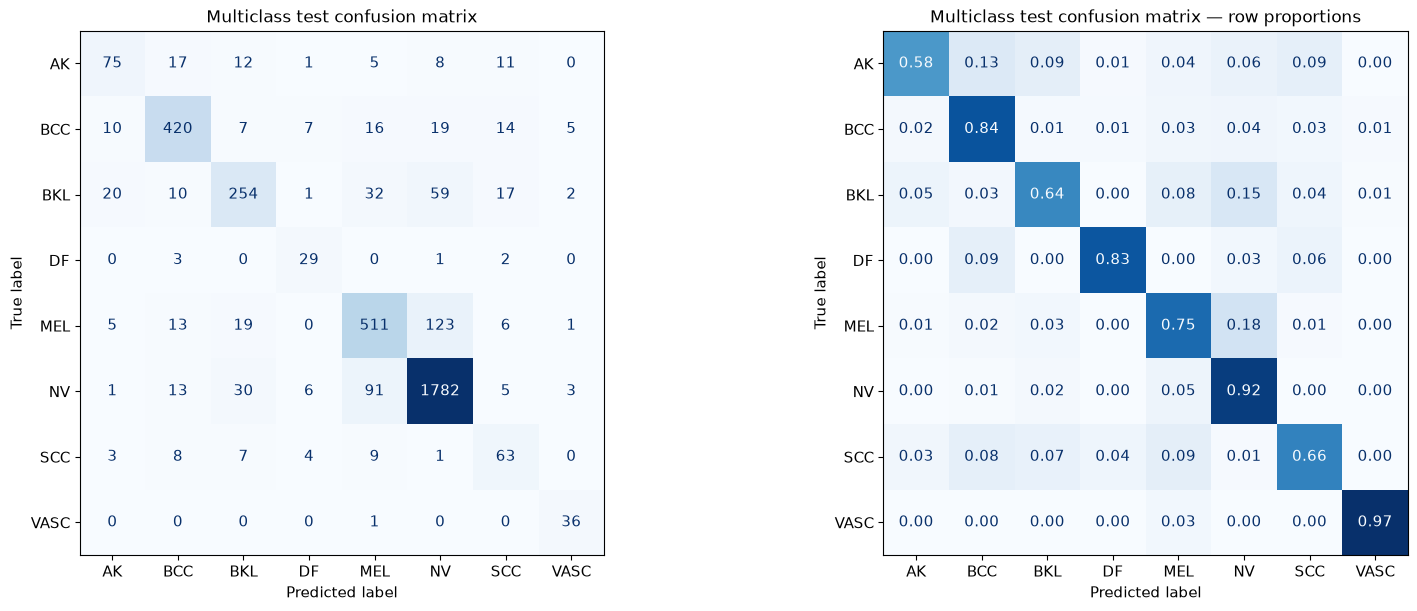

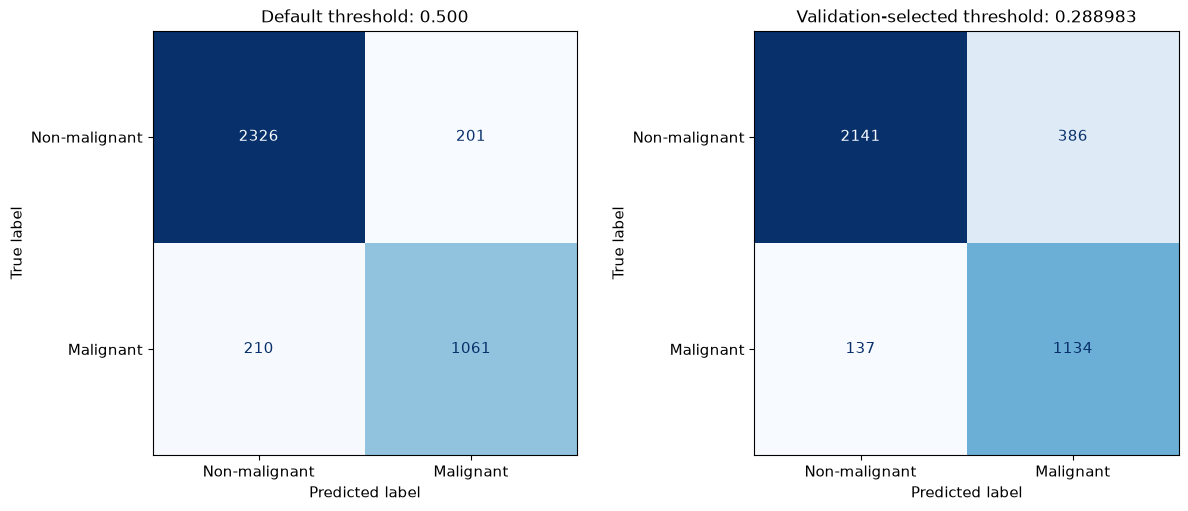

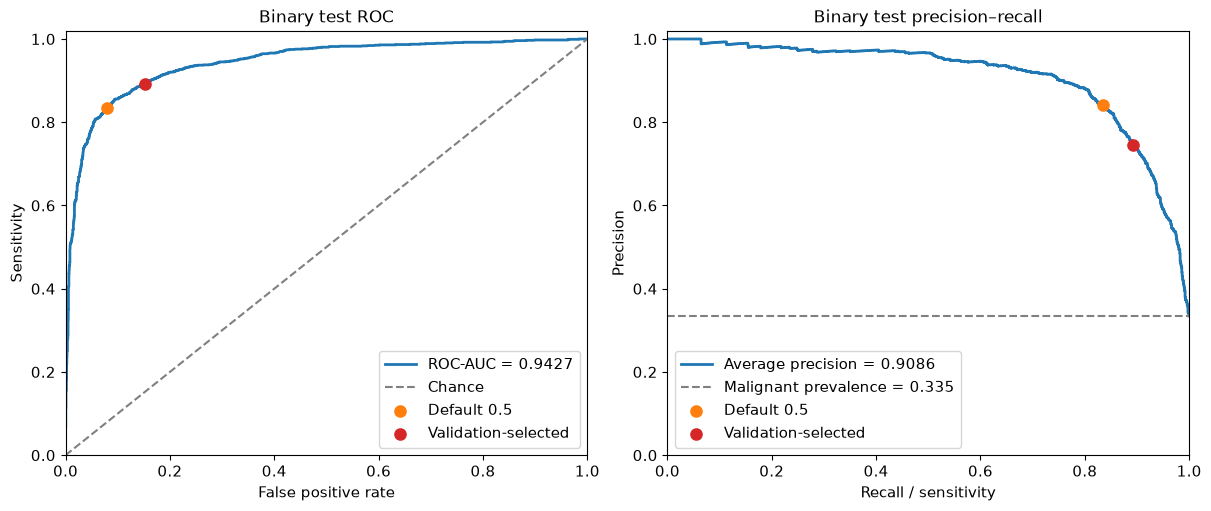

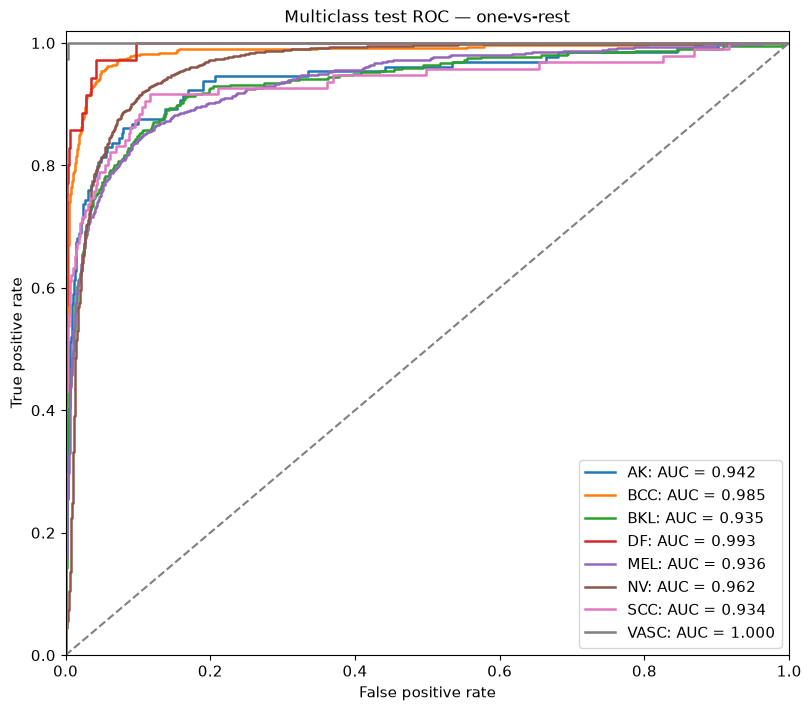

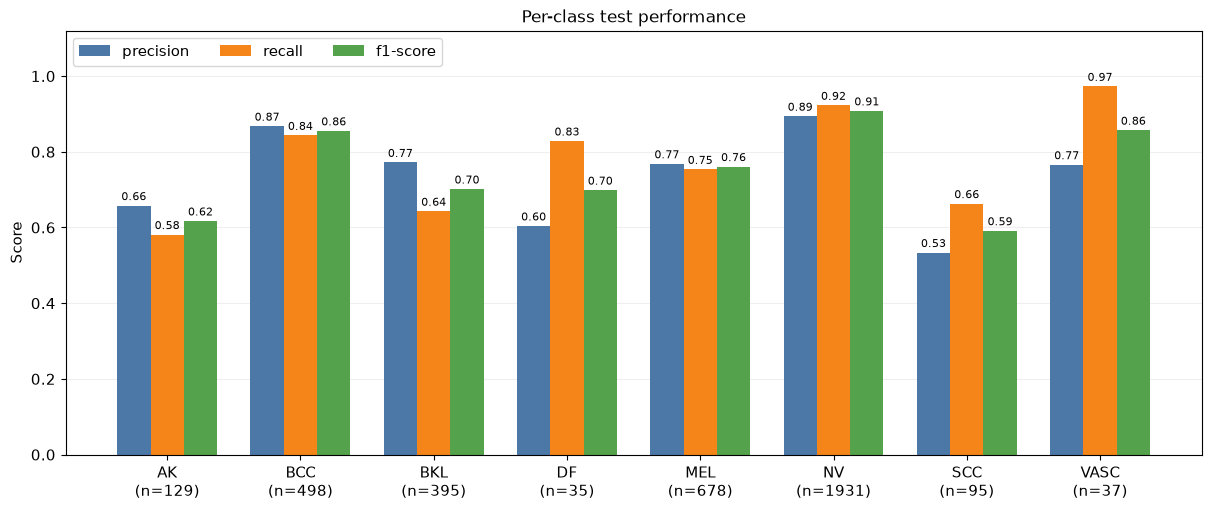

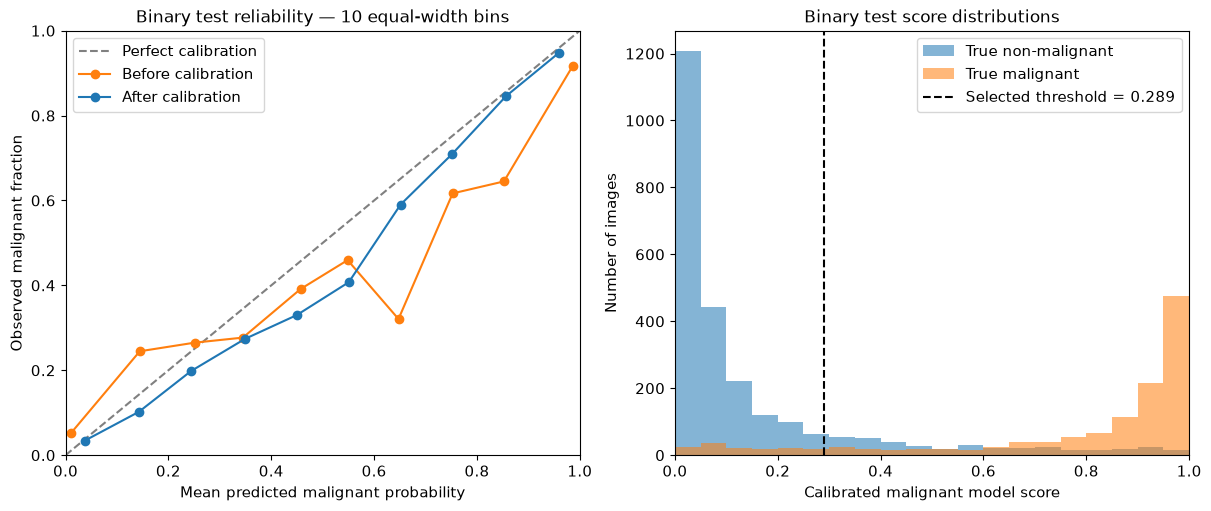

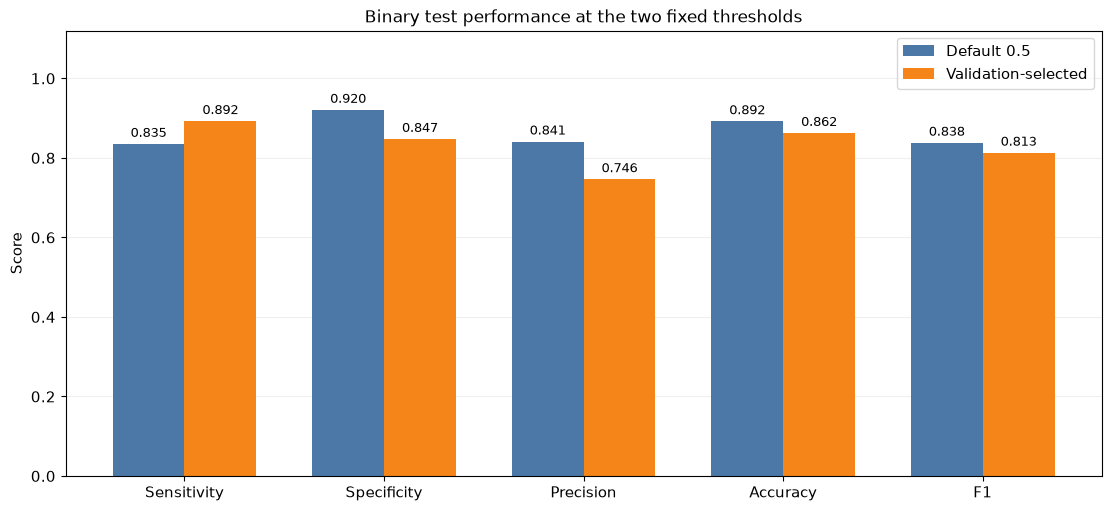


STEP 10 COMPLETED
Figures created: 7
Formats: PNG (300 DPI) and PDF
Saved to: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476\figures
Model training performed: NO
Model inference performed: NO
Threshold changed: NO


In [12]:
# STEP 10 — Test visualizations
# Uses Step 9 results. No training or model inference.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

required_names = [
    "RUN_DIR",
    "LABEL_NAMES",
    "test_y",
    "test_yb",
    "predicted",
    "raw_binary",
    "calibrated_binary",
    "calibrated_multi",
    "BINARY_THRESHOLD",
    "per_class_metrics",
    "binary_comparison",
    "save_test_csv",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        f"Run Step 9 in this kernel first. Missing: {missing}"
    )

FIGURE_DIR = Path(RUN_DIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

saved_figures = []


def finish_figure(fig, filename):
    # PNG for quick viewing; PDF for thesis export.
    fig.savefig(
        FIGURE_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / f"{filename}.pdf",
        bbox_inches="tight",
    )
    saved_figures.append(filename)
    plt.show()
    plt.close(fig)


# --------------------------------------------------
# 1. Multiclass confusion matrices
# --------------------------------------------------
fig, axes = plt.subplots(
    1, 2, figsize=(16, 6), constrained_layout=True
)

for ax, normalize, title, fmt in [
    (axes[0], None, "Multiclass test confusion matrix", "d"),
    (
        axes[1], "true",
        "Multiclass test confusion matrix — row proportions",
        ".2f",
    ),
]:
    cm = confusion_matrix(
        test_y,
        predicted,
        labels=np.arange(len(LABEL_NAMES)),
        normalize=normalize,
    )
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=LABEL_NAMES,
    ).plot(
        ax=ax,
        cmap="Blues",
        values_format=fmt,
        colorbar=False,
    )
    ax.set_title(title)

finish_figure(fig, "multiclass_confusion_matrices")


# --------------------------------------------------
# 2. Binary confusion matrices at both frozen rules
# --------------------------------------------------
fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True
)

for ax, threshold, title in [
    (axes[0], 0.5, "Default threshold: 0.500"),
    (
        axes[1],
        BINARY_THRESHOLD,
        f"Validation-selected threshold: {BINARY_THRESHOLD:.6f}",
    ),
]:
    binary_prediction = (
        calibrated_binary >= threshold
    ).astype(int)

    cm = confusion_matrix(
        test_yb, binary_prediction, labels=[0, 1]
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-malignant", "Malignant"],
    ).plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False,
    )
    ax.set_title(title)

finish_figure(fig, "binary_confusion_matrices")


# --------------------------------------------------
# 3. Binary ROC and precision–recall curves
# --------------------------------------------------
fpr, tpr, _ = roc_curve(test_yb, calibrated_binary)
precision, recall, _ = precision_recall_curve(
    test_yb, calibrated_binary
)

binary_auc = roc_auc_score(test_yb, calibrated_binary)
binary_ap = average_precision_score(
    test_yb, calibrated_binary
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True
)

axes[0].plot(
    fpr, tpr, linewidth=2,
    label=f"ROC-AUC = {binary_auc:.4f}",
)
axes[0].plot(
    [0, 1], [0, 1], "--", color="gray", label="Chance"
)

for rule, color in [
    ("Default 0.5", "tab:orange"),
    ("Validation-selected", "tab:red"),
]:
    row = binary_comparison.loc[rule]
    axes[0].scatter(
        1 - row["specificity"],
        row["sensitivity"],
        color=color,
        s=65,
        zorder=5,
        label=rule,
    )

axes[0].set(
    xlabel="False positive rate",
    ylabel="Sensitivity",
    title="Binary test ROC",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
axes[0].legend(loc="lower right")

axes[1].step(
    recall, precision,
    where="post",
    linewidth=2,
    label=f"Average precision = {binary_ap:.4f}",
)
axes[1].axhline(
    float(np.mean(test_yb)),
    linestyle="--",
    color="gray",
    label=f"Malignant prevalence = {np.mean(test_yb):.3f}",
)

for rule, color in [
    ("Default 0.5", "tab:orange"),
    ("Validation-selected", "tab:red"),
]:
    row = binary_comparison.loc[rule]
    axes[1].scatter(
        row["sensitivity"],
        row["precision"],
        color=color,
        s=65,
        zorder=5,
        label=rule,
    )

axes[1].set(
    xlabel="Recall / sensitivity",
    ylabel="Precision",
    title="Binary test precision–recall",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
axes[1].legend(loc="lower left")

finish_figure(fig, "binary_roc_precision_recall")


# --------------------------------------------------
# 4. Multiclass one-vs-rest ROC curves
# --------------------------------------------------
fig, ax = plt.subplots(
    figsize=(8, 7), constrained_layout=True
)

for i, name in enumerate(LABEL_NAMES):
    class_labels = (test_y == i).astype(int)
    class_probabilities = calibrated_multi[:, i]

    class_fpr, class_tpr, _ = roc_curve(
        class_labels, class_probabilities
    )
    class_auc = roc_auc_score(
        class_labels, class_probabilities
    )

    ax.plot(
        class_fpr,
        class_tpr,
        linewidth=1.8,
        label=f"{name}: AUC = {class_auc:.3f}",
    )

ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="Multiclass test ROC — one-vs-rest",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.legend(loc="lower right")

finish_figure(fig, "multiclass_roc")


# --------------------------------------------------
# 5. Per-class precision, recall and F1
# --------------------------------------------------
class_results = per_class_metrics.reindex(list(LABEL_NAMES))
x = np.arange(len(LABEL_NAMES))
width = 0.25

fig, ax = plt.subplots(
    figsize=(12, 5), constrained_layout=True
)

for offset, metric, color in [
    (-width, "precision", "#4C78A8"),
    (0, "recall", "#F58518"),
    (width, "f1-score", "#54A24B"),
]:
    bars = ax.bar(
        x + offset,
        class_results[metric].to_numpy(),
        width,
        label=metric,
        color=color,
    )
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

ax.set_xticks(
    x,
    [
        f"{name}\n(n={int(class_results.loc[name, 'support'])})"
        for name in LABEL_NAMES
    ],
)
ax.set(
    ylabel="Score",
    title="Per-class test performance",
    ylim=(0, 1.12),
)
ax.legend(loc="upper left", ncol=3)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

finish_figure(fig, "per_class_performance")


# --------------------------------------------------
# 6. Binary reliability diagrams and score distributions
# --------------------------------------------------
def reliability_table(labels, probabilities, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.minimum(
        (probabilities * n_bins).astype(int),
        n_bins - 1,
    )

    rows = []
    for i in range(n_bins):
        mask = bin_ids == i
        if not mask.any():
            continue

        rows.append({
            "bin_lower": float(edges[i]),
            "bin_upper": float(edges[i + 1]),
            "count": int(mask.sum()),
            "mean_probability": float(probabilities[mask].mean()),
            "observed_malignant_fraction": float(labels[mask].mean()),
        })

    return pd.DataFrame(rows)


reliability_raw = reliability_table(test_yb, raw_binary)
reliability_calibrated = reliability_table(
    test_yb, calibrated_binary
)

save_test_csv(
    Path(RUN_DIR) / "reliability_raw.csv",
    reliability_raw,
)
save_test_csv(
    Path(RUN_DIR) / "reliability_calibrated.csv",
    reliability_calibrated,
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True
)

axes[0].plot(
    [0, 1], [0, 1], "--",
    color="gray", label="Perfect calibration",
)

for table, label, color in [
    (reliability_raw, "Before calibration", "tab:orange"),
    (reliability_calibrated, "After calibration", "tab:blue"),
]:
    axes[0].plot(
        table["mean_probability"],
        table["observed_malignant_fraction"],
        marker="o",
        color=color,
        label=label,
    )

axes[0].set(
    xlabel="Mean predicted malignant probability",
    ylabel="Observed malignant fraction",
    title="Binary test reliability — 10 equal-width bins",
    xlim=(0, 1),
    ylim=(0, 1),
)
axes[0].legend()

bins = np.linspace(0, 1, 21)

for label, name, color in [
    (0, "True non-malignant", "tab:blue"),
    (1, "True malignant", "tab:orange"),
]:
    axes[1].hist(
        calibrated_binary[test_yb == label],
        bins=bins,
        alpha=0.55,
        color=color,
        label=name,
    )

axes[1].axvline(
    BINARY_THRESHOLD,
    color="black",
    linestyle="--",
    label=f"Selected threshold = {BINARY_THRESHOLD:.3f}",
)
axes[1].set(
    xlabel="Calibrated malignant model score",
    ylabel="Number of images",
    title="Binary test score distributions",
    xlim=(0, 1),
)
axes[1].legend()

finish_figure(fig, "calibration_and_scores")


# --------------------------------------------------
# 7. Test trade-off between the two decision rules
# --------------------------------------------------
comparison_metrics = [
    "sensitivity", "specificity", "precision", "accuracy", "f1"
]
x = np.arange(len(comparison_metrics))
width = 0.36

fig, ax = plt.subplots(
    figsize=(11, 5), constrained_layout=True
)

for offset, rule, color in [
    (-width / 2, "Default 0.5", "#4C78A8"),
    (width / 2, "Validation-selected", "#F58518"),
]:
    values = binary_comparison.loc[
        rule, comparison_metrics
    ].to_numpy(dtype=float)

    bars = ax.bar(
        x + offset, values, width,
        label=rule, color=color,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_xticks(x, [name.capitalize() for name in comparison_metrics])
ax.set(
    ylabel="Score",
    title="Binary test performance at the two fixed thresholds",
    ylim=(0, 1.12),
)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

finish_figure(fig, "binary_threshold_comparison")


print("\nSTEP 10 COMPLETED")
print("Figures created:", len(saved_figures))
print("Formats: PNG (300 DPI) and PDF")
print("Saved to:", FIGURE_DIR)
print("Model training performed: NO")
print("Model inference performed: NO")
print("Threshold changed: NO")

### Step 11: saved model backup ও reload verification(2nd Tuning Part)

In [13]:
# STEP 11 — Back up the completed run and verify model reload
# No training, calibration fitting or threshold selection.

from pathlib import Path
from datetime import datetime
from uuid import uuid4
import hashlib
import json
import os
import shutil

import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm


# --------------------------------------------------
# 1. Explicitly select the completed fine-tuning run
# --------------------------------------------------
SOURCE_RUN = Path(
    r"C:\SRS(ISIC_2019)\centralized_finetuning_runs"
    r"\cb_finetune_retry_20260922_191654_cb7c0476"
)
PROJECT_DIR = SOURCE_RUN.parent.parent
BACKUP_ROOT = PROJECT_DIR / "verified_model_backups"

required_definitions = [
    "ISIC_Fusion_Model",
    "val_transform",
    "device",
]
missing = [
    name for name in required_definitions
    if name not in globals()
]
if missing:
    raise RuntimeError(
        f"Run the architecture/transform definitions first: {missing}"
    )

required_files = [
    "best_centralized_model.pth",
    "calibration.json",
    "decision_policy.json",
    "split_validation.csv",
    "test_metrics.json",
    "test_evaluation_provenance.json",
]

for name in required_files:
    path = SOURCE_RUN / name
    if not path.is_file():
        raise FileNotFoundError(path)

# Capture saved notebook code alongside the model.
notebooks = sorted(PROJECT_DIR.glob("*.ipynb"))
if not notebooks:
    raise FileNotFoundError(
        f"No notebooks found in {PROJECT_DIR}. "
        "Save your notebook in the project folder first."
    )


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# --------------------------------------------------
# 2. Copy files into a new temporary backup folder
# --------------------------------------------------
BACKUP_ROOT.mkdir(parents=True, exist_ok=True)

backup_name = (
    SOURCE_RUN.name
    + "_"
    + datetime.now().strftime("%Y%m%d_%H%M%S")
    + "_"
    + uuid4().hex[:6]
)

FINAL_BACKUP = BACKUP_ROOT / backup_name
STAGING_BACKUP = BACKUP_ROOT / (backup_name + ".incomplete")

STAGING_BACKUP.mkdir(exist_ok=False)

copy_jobs = [
    (path, Path("run") / path.relative_to(SOURCE_RUN))
    for path in sorted(SOURCE_RUN.rglob("*"))
    if path.is_file()
]
copy_jobs += [
    (path, Path("notebooks") / path.name)
    for path in notebooks
]

manifest = {}

for source, relative in tqdm(copy_jobs, desc="Backing up files"):
    destination = STAGING_BACKUP / relative
    destination.parent.mkdir(parents=True, exist_ok=True)

    source_hash = sha256_file(source)

    with source.open("rb") as src, destination.open("wb") as dst:
        shutil.copyfileobj(src, dst, length=1024 * 1024)
        dst.flush()
        os.fsync(dst.fileno())

    if sha256_file(destination) != source_hash:
        raise RuntimeError(f"Backup verification failed: {source}")

    manifest[relative.as_posix()] = source_hash

print("Backup file hashes verified:", len(manifest))


# --------------------------------------------------
# 3. Verify model/calibration/threshold linkage
# --------------------------------------------------
copied_run = STAGING_BACKUP / "run"
model_path = copied_run / "best_centralized_model.pth"
calibration_path = copied_run / "calibration.json"
policy_path = copied_run / "decision_policy.json"

saved_calibration = json.loads(
    calibration_path.read_text(encoding="utf-8")
)
saved_policy = json.loads(
    policy_path.read_text(encoding="utf-8")
)

model_hash = sha256_file(model_path)

if saved_calibration["checkpoint_sha256"] != model_hash:
    raise ValueError("Calibration/checkpoint mismatch.")

if saved_policy["checkpoint_sha256"] != model_hash:
    raise ValueError("Policy/checkpoint mismatch.")

if saved_policy["calibration_sha256"] != sha256_file(calibration_path):
    raise ValueError("Policy/calibration mismatch.")

threshold = float(saved_policy["binary_threshold"])
temperatures = [
    float(saved_calibration["binary_temperature"]),
    float(saved_calibration["multiclass_temperature"]),
]

if not np.isfinite(threshold) or not 0 <= threshold <= 1:
    raise ValueError("Invalid saved threshold.")

if not all(np.isfinite(t) and t > 0 for t in temperatures):
    raise ValueError("Invalid saved temperatures.")


# --------------------------------------------------
# 4. Build a fresh model and restore backup weights
# --------------------------------------------------
checkpoint = torch.load(
    model_path,
    map_location="cpu",
    weights_only=True,
)

classes = tuple(checkpoint["classes"])
malignant_indices = tuple(checkpoint["malignant_indices"])

if classes != ("AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"):
    raise ValueError("Unexpected class mapping.")

if set(malignant_indices) != {1, 4, 6}:
    raise ValueError("Unexpected malignant mapping.")

epoch = int(checkpoint["epoch"])

if (
    epoch != int(saved_calibration["best_epoch"])
    or epoch != int(saved_policy["best_epoch"])
):
    raise ValueError("Saved epoch mismatch.")

restored_model = ISIC_Fusion_Model(
    num_classes=len(classes),
    pretrained=False,
)

restored_model.load_state_dict(
    checkpoint["state_dict"],
    strict=True,
)

# Check every restored parameter and buffer before moving to GPU.
for name, value in restored_model.state_dict().items():
    if not torch.equal(value.cpu(), checkpoint["state_dict"][name].cpu()):
        raise RuntimeError(f"Restored tensor mismatch: {name}")

del checkpoint
restored_model.to(device).eval()

print("Fresh model loaded from backup.")
print("All restored parameters and buffers match the checkpoint.")


# --------------------------------------------------
# 5. One-image inference smoke check
# --------------------------------------------------
validation_manifest = pd.read_csv(
    copied_run / "split_validation.csv"
)
probe_row = validation_manifest.iloc[0]
probe_path = Path(probe_row["image_path"])

if not probe_path.is_file():
    raise FileNotFoundError(probe_path)

if sha256_file(probe_path) != probe_row["sha256"]:
    raise ValueError("Verification image bytes changed.")

with Image.open(probe_path) as image:
    probe = val_transform(
        image.convert("RGB")
    ).unsqueeze(0).to(device)

# FP32 smoke check; it does not recompute test metrics.
with torch.inference_mode():
    outputs = restored_model(probe)

    binary_logits = torch.stack([
        binary.reshape(-1).float()
        for binary, multiclass in outputs
    ]).mean(dim=0)

    multiclass_logits = torch.stack([
        multiclass.float()
        for binary, multiclass in outputs
    ]).mean(dim=0)

if binary_logits.shape != (1,) or multiclass_logits.shape != (1, 8):
    raise RuntimeError("Unexpected restored-model output shapes.")

if (
    not torch.isfinite(binary_logits).all()
    or not torch.isfinite(multiclass_logits).all()
):
    raise RuntimeError("Restored model produced non-finite outputs.")

print("One-image inference check: PASSED")


# --------------------------------------------------
# 6. Record verification and finalize the backup
# --------------------------------------------------
verification = {
    "source_run": str(SOURCE_RUN),
    "best_epoch": epoch,
    "checkpoint_sha256": model_hash,
    "binary_threshold": threshold,
    "classes": list(classes),
    "malignant_indices": list(malignant_indices),
    "copied_files": len(manifest),
    "strict_model_load": "passed",
    "restored_tensor_comparison": "passed",
    "single_image_inference": "passed",
    "verification_image_id": str(probe_row["image_id"]),
    "validation_transform": repr(val_transform),
    "torch_version": str(torch.__version__),
    "device": str(device),
    "note": (
        "Inference reuse verified. Notebook architecture definitions "
        "and dependencies are still required. Exact training resume "
        "requires optimizer, scheduler, scaler and RNG states."
    ),
}

for name, data in [
    ("backup_manifest.json", manifest),
    ("reload_verification.json", verification),
]:
    with (STAGING_BACKUP / name).open(
        "w", encoding="utf-8"
    ) as file:
        json.dump(data, file, indent=2, allow_nan=False)
        file.flush()
        os.fsync(file.fileno())

# Only a fully checked backup receives its final folder name.
STAGING_BACKUP.rename(FINAL_BACKUP)

VERIFIED_BACKUP_DIR = FINAL_BACKUP

# Release the temporary model; keep the existing best_model.
del restored_model, probe, outputs, binary_logits, multiclass_logits
if device.type == "cuda":
    torch.cuda.empty_cache()

print("\nSTEP 11 COMPLETED")
print("Best fine-tuning epoch:", epoch)
print(f"Saved binary threshold: {threshold:.6f}")
print("Backup:", VERIFIED_BACKUP_DIR)
print("Saved notebooks:", [path.name for path in notebooks])
print("Backup integrity: PASSED")
print("Model reload: PASSED")
print("One-image inference: PASSED")
print("Training performed: NO")

Backing up files:   0%|          | 0/42 [00:00<?, ?it/s]

Backup file hashes verified: 42
Fresh model loaded from backup.
All restored parameters and buffers match the checkpoint.
One-image inference check: PASSED

STEP 11 COMPLETED
Best fine-tuning epoch: 7
Saved binary threshold: 0.288983
Backup: C:\SRS(ISIC_2019)\verified_model_backups\cb_finetune_retry_20260922_191654_cb7c0476_20260923_083152_0f604d
Saved notebooks: ['ISIC_Federated_Finetuning.ipynb', 'ISIC_Federated_Main.ipynb']
Backup integrity: PASSED
Model reload: PASSED
One-image inference: PASSED
Training performed: NO


### Step 1 : Federated Learning — Client data partition

In [14]:
# FL STEP 1 — Four clients from the saved training split
# No model training in this cell.

from pathlib import Path
from itertools import combinations
from uuid import uuid4
import hashlib
import json

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from IPython.display import display


# --------------------------------------------------
# 1. Load the original saved splits
# --------------------------------------------------
CENTRALIZED_RUN = Path(
    r"C:\SRS(ISIC_2019)\centralized_finetuning_runs"
    r"\cb_finetune_retry_20260922_191654_cb7c0476"
)

FL_LABEL_NAMES = (
    "AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"
)
FL_SEED = 42
NUM_CLIENTS = 4

# Keep FL variables separate from the centralized run.
FL_PARTITION_DIR = (
    CENTRALIZED_RUN.parent.parent
    / "fl_partitions"
    / "four_clients_stratified_seed42_v1"
)


def fl_file_hash(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


source_splits = {}
source_hashes = {}

for split_name in ("train", "validation", "calibration", "test"):
    path = CENTRALIZED_RUN / f"split_{split_name}.csv"
    if not path.is_file():
        raise FileNotFoundError(path)

    frame = pd.read_csv(path)

    required = {
        "image_path", "image_id", "label", "group_id", "sha256"
    }
    if not required.issubset(frame.columns):
        raise ValueError(f"Missing columns: {split_name}")

    if frame.empty or frame[list(required)].isna().any().any():
        raise ValueError(f"Empty/incomplete split: {split_name}")

    if frame.image_id.duplicated().any():
        raise ValueError(f"Repeated image IDs: {split_name}")

    labels = pd.to_numeric(frame.label, errors="raise")
    if not labels.isin(range(8)).all():
        raise ValueError(f"Invalid labels: {split_name}")
    frame["label"] = labels.astype(int)

    source_splits[split_name] = frame
    source_hashes[split_name] = fl_file_hash(path)

for (name_a, a), (name_b, b) in combinations(
    source_splits.items(), 2
):
    for column in ("image_id", "group_id", "sha256"):
        if set(a[column].astype(str)) & set(b[column].astype(str)):
            raise ValueError(
                f"Source split overlap: {name_a}/{name_b}, {column}"
            )

fl_train_df = source_splits["train"].reset_index(drop=True)

# Identical bytes must already belong to one indivisible group.
if fl_train_df.groupby("sha256").group_id.nunique().max() > 1:
    raise ValueError("Identical training images have different group IDs.")

if (
    fl_train_df.groupby("label").group_id.nunique()
    .reindex(range(8), fill_value=0)
    .min() < NUM_CLIENTS
):
    raise ValueError("Too few groups in at least one training class.")


# --------------------------------------------------
# 2. Assign entire groups to four clients
# --------------------------------------------------
splitter = StratifiedGroupKFold(
    n_splits=NUM_CLIENTS,
    shuffle=True,
    random_state=FL_SEED,
)

client_assignment = np.full(len(fl_train_df), -1, dtype=int)

for client_id, (_, held_indices) in enumerate(
    splitter.split(
        fl_train_df,
        fl_train_df.label,
        groups=fl_train_df.group_id,
    )
):
    client_assignment[held_indices] = client_id

if (client_assignment < 0).any():
    raise RuntimeError("Some training images were not assigned.")

fl_train_df["client_id"] = client_assignment

client_train_dfs = {
    client_id: fl_train_df[
        fl_train_df.client_id == client_id
    ].reset_index(drop=True)
    for client_id in range(NUM_CLIENTS)
}


# --------------------------------------------------
# 3. Verify coverage and client isolation
# --------------------------------------------------
for client_id, frame in client_train_dfs.items():
    if set(frame.label) != set(range(8)):
        raise ValueError(
            f"Client {client_id} is missing a class. "
            "Inspect the group distribution."
        )

for (id_a, a), (id_b, b) in combinations(
    client_train_dfs.items(), 2
):
    for column in ("image_id", "group_id", "sha256"):
        if set(a[column].astype(str)) & set(b[column].astype(str)):
            raise ValueError(
                f"Client overlap: {id_a}/{id_b}, {column}"
            )

combined = pd.concat(client_train_dfs.values(), ignore_index=True)

if (
    len(combined) != len(source_splits["train"])
    or combined.image_id.duplicated().any()
    or set(combined.image_id) != set(source_splits["train"].image_id)
):
    raise RuntimeError("Clients do not exactly cover the training split.")

client_counts = pd.crosstab(
    fl_train_df.label, fl_train_df.client_id
).reindex(index=range(8), columns=range(NUM_CLIENTS), fill_value=0)

client_counts.index = FL_LABEL_NAMES
client_counts.columns = [
    f"client_{i}" for i in range(NUM_CLIENTS)
]
client_counts.index.name = "class"

partition_config = {
    "num_clients": NUM_CLIENTS,
    "seed": FL_SEED,
    "method": "StratifiedGroupKFold",
    "description": (
        "Simulated clients with approximately similar class proportions. "
        "Whole recorded groups remain within a single client."
    ),
    "classes": list(FL_LABEL_NAMES),
    "source_split_sha256": source_hashes,
    "training_images": int(len(fl_train_df)),
    "limitations": (
        "Patient/lesion separation is only as complete as the supplied "
        "group metadata. This is not a hospital-based partition."
    ),
}


# --------------------------------------------------
# 4. Save once; verify and reuse on later runs
# --------------------------------------------------
expected_files = {
    "partition_config.json": (
        json.dumps(partition_config, indent=2) + "\n"
    ).encode("utf-8"),
    "client_class_counts.csv": (
        client_counts.to_csv().encode("utf-8")
    ),
}

for client_id, frame in client_train_dfs.items():
    expected_files[f"client_{client_id}_train.csv"] = (
        frame.to_csv(index=False).encode("utf-8")
    )

# Preserve the same development and test manifests.
for split_name in ("validation", "calibration", "test"):
    expected_files[f"split_{split_name}.csv"] = (
        CENTRALIZED_RUN / f"split_{split_name}.csv"
    ).read_bytes()

if FL_PARTITION_DIR.exists():
    for filename, payload in expected_files.items():
        path = FL_PARTITION_DIR / filename
        if not path.is_file() or path.read_bytes() != payload:
            raise RuntimeError(
                f"Existing partition differs: {filename}. "
                "It has not been overwritten."
            )
    print("Existing client partition verified and reused.")
else:
    FL_PARTITION_DIR.parent.mkdir(parents=True, exist_ok=True)
    staging = FL_PARTITION_DIR.with_name(
        FL_PARTITION_DIR.name + "." + uuid4().hex + ".incomplete"
    )
    staging.mkdir()

    for filename, payload in expected_files.items():
        (staging / filename).write_bytes(payload)

    staging.rename(FL_PARTITION_DIR)
    print("New client partition saved.")


print("\nCLIENT CLASS COUNTS")
display(client_counts)

print("\nClient totals:")
print({
    f"client_{client_id}": len(frame)
    for client_id, frame in client_train_dfs.items()
})

print("\nFL STEP 1 COMPLETED")
print("Total training images:", len(fl_train_df))
print("Number of clients:", NUM_CLIENTS)
print("Training coverage: PASSED")
print("Client image/group/hash isolation: PASSED")
print("Validation/calibration/test isolation: PASSED")
print("Partition saved:", FL_PARTITION_DIR)
print("Model training performed: NO")

Existing client partition verified and reused.

CLIENT CLASS COUNTS


,client_0,client_1,client_2,client_3
class,,,,
AK,153,152,152,152
BCC,582,582,582,581
BKL,459,458,459,459
DF,42,42,42,42
MEL,791,791,791,791
NV,2253,2253,2253,2253
SCC,109,110,109,110
VASC,45,44,45,44



Client totals:
{'client_0': 4434, 'client_1': 4432, 'client_2': 4433, 'client_3': 4432}

FL STEP 1 COMPLETED
Total training images: 17731
Number of clients: 4
Training coverage: PASSED
Client image/group/hash isolation: PASSED
Validation/calibration/test isolation: PASSED
Partition saved: C:\SRS(ISIC_2019)\fl_partitions\four_clients_stratified_seed42_v1
Model training performed: NO


In [15]:
# FL environment compatibility check
# No installation or training.

import importlib
import inspect
import platform
import torch

print("Operating system:", platform.system())
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

checks = [
    ("flwr.clientapp", "ClientApp"),
    ("flwr.clientapp.mod", "LocalDpMod"),
    ("flwr.serverapp", "ServerApp"),
    ("flwr.serverapp.strategy", "FedAvg"),
    ("flwr.serverapp", "PrivacyConfig"),
    ("flwr.serverapp", "RdpAccountant"),
    ("dp_accounting", None),
    ("ray", None),
]

print("\nFLOWER API AND DEPENDENCY CHECK")

for module_name, object_name in checks:
    label = (
        f"{module_name}.{object_name}"
        if object_name else module_name
    )

    try:
        module = importlib.import_module(module_name)

        if object_name:
            obj = getattr(module, object_name)
            print(f"\nOK: {label}")
            try:
                print("Signature:", inspect.signature(obj))
            except (TypeError, ValueError):
                pass
        else:
            print(f"\nOK: {label}")

    except Exception as exc:
        print(f"\nUNAVAILABLE: {label}")
        print(f"{type(exc).__name__}: {exc}")

print("\nCHECK COMPLETED — no training performed.")

Operating system: Windows
CUDA available: True
GPU: NVIDIA GeForce RTX 4090

FLOWER API AND DEPENDENCY CHECK

OK: flwr.clientapp.ClientApp
Signature: (client_fn: collections.abc.Callable[[flwr.app.message.context.Context], flwr.compat.client.client.Client] | None = None, mods: list[collections.abc.Callable[[flwr.app.message.message.Message, flwr.app.message.context.Context, collections.abc.Callable[[flwr.app.message.message.Message, flwr.app.message.context.Context], flwr.app.message.message.Message]], flwr.app.message.message.Message]] | None = None) -> None

OK: flwr.clientapp.mod.LocalDpMod
Signature: (clipping_norm: float, sensitivity: float, epsilon: float, delta: float) -> None

OK: flwr.serverapp.ServerApp
Signature: (server: flwr.server.server.Server | None = None, config: flwr.server.server_config.ServerConfig | None = None, strategy: flwr.server.strategy.strategy.Strategy | None = None, client_manager: flwr.server.client_manager.ClientManager | None = None, server_fn: collect

In [16]:
# FL setup — install the privacy-accounting dependency if missing
# No training.

import sys
import subprocess
import importlib
from importlib.metadata import version, PackageNotFoundError

try:
    installed_version = version("dp-accounting")
except PackageNotFoundError:
    installed_version = None

if installed_version is None:
    print("Installing Flower's optional DP dependencies...")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "flwr[dp]==1.37.0",
        ],
        check=True,
    )
    importlib.invalidate_caches()
else:
    print("dp-accounting already installed:", installed_version)

# Verify in a fresh Python process to avoid stale notebook imports.
verification_code = """
from importlib.metadata import version
from dp_accounting import dp_event, rdp
from flwr.serverapp import RdpAccountant

accountant = rdp.RdpAccountant()
accountant.compose(dp_event.GaussianDpEvent(2.0))
epsilon = accountant.get_epsilon(target_delta=1e-5)

assert epsilon > 0

print("Flower:", version("flwr"))
print("dp-accounting:", version("dp-accounting"))
print("Gaussian accounting smoke test: PASSED")
print("This is a synthetic check, not the FL experiment's privacy budget.")
"""

result = subprocess.run(
    [sys.executable, "-c", verification_code],
    capture_output=True,
    text=True,
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(
        "DP dependency verification failed. "
        "Send the error above; do not upgrade other packages."
    )

print("DP DEPENDENCY CHECK COMPLETED")
print("Training performed: NO")

dp-accounting already installed: 0.6.0
Flower: 1.37.0
dp-accounting: 0.6.0
Gaussian accounting smoke test: PASSED
This is a synthetic check, not the FL experiment's privacy budget.

DP DEPENDENCY CHECK COMPLETED
Training performed: NO


In [17]:
# FL STEP 2 — Calibrate client-side Gaussian noise
# No model training or private update release.

from pathlib import Path
import importlib
import json
import os
from uuid import uuid4

import numpy as np
import pandas as pd
from IPython.display import display

importlib.invalidate_caches()

from dp_accounting import dp_event, rdp


# --------------------------------------------------
# 1. Experimental protocol
# --------------------------------------------------
FL_NUM_CLIENTS = 4
FL_NUM_ROUNDS = 10
FL_LOCAL_EPOCHS = 1

FL_TARGET_EPSILON = 8.0
FL_TARGET_DELTA = 1e-5
FL_CLIPPING_NORM = 1.0

# Replacing one client's complete dataset can change a
# clipped update by at most 2 * clipping_norm.
FL_UPDATE_SENSITIVITY = 2.0 * FL_CLIPPING_NORM

# Every client participates in every round.
# Therefore, do not claim sampling amplification.
FL_CLIENT_SAMPLE_RATE = 1.0

FL_PRIVACY_DIR = Path(
    r"C:\SRS(ISIC_2019)\fl_protocols"
)
FL_PRIVACY_DIR.mkdir(parents=True, exist_ok=True)

FL_PRIVACY_PATH = (
    FL_PRIVACY_DIR / "client_update_dp_10rounds_v1.json"
)


# --------------------------------------------------
# 2. Account for repeated releases from ONE client
# --------------------------------------------------
def make_client_accountant(noise_multiplier, releases):
    accountant = rdp.RdpAccountant()

    if releases:
        accountant.compose(
            dp_event.GaussianDpEvent(
                noise_multiplier=float(noise_multiplier)
            ),
            count=int(releases),
        )

    return accountant


def composed_epsilon(noise_multiplier, releases):
    accountant = make_client_accountant(
        noise_multiplier, releases
    )
    return float(
        accountant.get_epsilon(
            target_delta=FL_TARGET_DELTA
        )
    )


# Noise multiplier is relative to the sensitivity bound,
# not directly to the clipping norm.
lower = 0.01
upper = 1.0

while composed_epsilon(upper, FL_NUM_ROUNDS) > FL_TARGET_EPSILON:
    upper *= 2.0
    if upper > 1e6:
        raise RuntimeError("Could not bracket a noise multiplier.")

for _ in range(60):
    midpoint = (lower + upper) / 2.0
    epsilon = composed_epsilon(midpoint, FL_NUM_ROUNDS)

    if epsilon > FL_TARGET_EPSILON:
        lower = midpoint
    else:
        upper = midpoint

# Small numerical margin below the requested budget.
FL_NOISE_MULTIPLIER = float(upper * 1.001)

# Standard deviation for EACH coordinate of each client's
# clipped update, BEFORE aggregation.
FL_NOISE_STD = float(
    FL_NOISE_MULTIPLIER * FL_UPDATE_SENSITIVITY
)


# --------------------------------------------------
# 3. Planned privacy expenditure per client
# --------------------------------------------------
privacy_schedule = pd.DataFrame([
    {
        "round": round_number,
        "releases_per_client": round_number,
        "epsilon_per_client": composed_epsilon(
            FL_NOISE_MULTIPLIER, round_number
        ),
        "delta": FL_TARGET_DELTA,
    }
    for round_number in range(1, FL_NUM_ROUNDS + 1)
])

final_epsilon = float(
    privacy_schedule.iloc[-1]["epsilon_per_client"]
)

if not np.isfinite(final_epsilon):
    raise RuntimeError("Non-finite privacy expenditure.")

if final_epsilon > FL_TARGET_EPSILON:
    raise RuntimeError("Planned privacy expenditure exceeds the target.")


# --------------------------------------------------
# 4. Freeze and save the protocol
# --------------------------------------------------
FL_PRIVACY_CONFIG = {
    "framework": "Flower",
    "mechanism": "client-side clipped Gaussian update",
    "num_clients": FL_NUM_CLIENTS,
    "max_rounds": FL_NUM_ROUNDS,
    "local_epochs": FL_LOCAL_EPOCHS,
    "participation": "all clients every round",
    "sampling_amplification": False,
    "protected_unit": "one fixed client's complete training dataset",
    "neighboring_relation": (
        "replacement of one client's training dataset, "
        "conditional on fixed client identities and partition"
    ),
    "clipping": "one global L2 norm over the transmitted update vector",
    "clipping_norm": FL_CLIPPING_NORM,
    "replacement_sensitivity_bound": FL_UPDATE_SENSITIVITY,
    "noise_multiplier_relative_to_sensitivity": FL_NOISE_MULTIPLIER,
    "noise_std_per_coordinate_before_aggregation": FL_NOISE_STD,
    "target_epsilon_per_client": FL_TARGET_EPSILON,
    "target_delta_per_client": FL_TARGET_DELTA,
    "planned_final_epsilon_per_client": final_epsilon,
    "accounting": "RDP composition of unsampled Gaussian releases",
    "release_rules": [
        "Clip the complete transmitted update before adding noise.",
        "Do not transmit unprotected data-dependent buffers or metrics.",
        "Use fresh noise; do not publish or reuse its random seed.",
        "Persist privacy expenditure across rounds and restarts.",
        "Account for additional private releases, including retries.",
    ],
    "scope": (
        "Accounting plan for training-update releases only. "
        "Not an end-to-end privacy certification of the notebook, "
        "partition construction, evaluation outputs or prior models."
    ),
}

if FL_PRIVACY_PATH.exists():
    existing = json.loads(
        FL_PRIVACY_PATH.read_text(encoding="utf-8")
    )
    if existing != FL_PRIVACY_CONFIG:
        raise RuntimeError(
            "An existing privacy protocol differs. "
            "It has not been overwritten."
        )
    print("Existing privacy protocol verified and reused.")
else:
    temporary = FL_PRIVACY_PATH.with_name(
        FL_PRIVACY_PATH.name + "." + uuid4().hex + ".tmp"
    )
    try:
        with temporary.open("w", encoding="utf-8") as file:
            json.dump(
                FL_PRIVACY_CONFIG,
                file,
                indent=2,
                allow_nan=False,
            )
            file.flush()
            os.fsync(file.fileno())

        os.replace(temporary, FL_PRIVACY_PATH)
    finally:
        temporary.unlink(missing_ok=True)


print("\nPLANNED PRIVACY SCHEDULE — PER CLIENT")
display(privacy_schedule.round({"epsilon_per_client": 4}))

print("\nFL STEP 2 COMPLETED")
print("Clients:", FL_NUM_CLIENTS)
print("Maximum rounds:", FL_NUM_ROUNDS)
print("Local epochs per round:", FL_LOCAL_EPOCHS)
print("Clipping norm:", FL_CLIPPING_NORM)
print("Replacement sensitivity bound:", FL_UPDATE_SENSITIVITY)
print(f"Noise multiplier: {FL_NOISE_MULTIPLIER:.6f}")
print(f"Noise standard deviation: {FL_NOISE_STD:.6f}")
print(f"Planned final epsilon per client: {final_epsilon:.4f}")
print("Target epsilon per client:", FL_TARGET_EPSILON)
print("Delta:", FL_TARGET_DELTA)
print("Saved protocol:", FL_PRIVACY_PATH)
print("Actual private releases so far: 0")
print("Training performed: NO")

Existing privacy protocol verified and reused.

PLANNED PRIVACY SCHEDULE — PER CLIENT


,round,releases_per_client,epsilon_per_client,delta
0,1,1,2.1437,0.00001
1,2,2,3.1561,0.00001
2,3,3,3.9696,0.00001
3,4,4,4.6787,0.00001
4,5,5,5.3207,0.00001
5,6,6,5.9148,0.00001
6,7,7,6.4723,0.00001
7,8,8,7.0007,0.00001
8,9,9,7.5057,0.00001
9,10,10,7.9904,0.00001



FL STEP 2 COMPLETED
Clients: 4
Maximum rounds: 10
Local epochs per round: 1
Clipping norm: 1.0
Replacement sensitivity bound: 2.0
Noise multiplier: 2.018507
Noise standard deviation: 4.037013
Planned final epsilon per client: 7.9904
Target epsilon per client: 8.0
Delta: 1e-05
Saved protocol: C:\SRS(ISIC_2019)\fl_protocols\client_update_dp_10rounds_v1.json
Actual private releases so far: 0
Training performed: NO


In [18]:
# FL Step 2B — Check noise magnitude before training
# No training, no noise injection, no model changes.

import math

required = [
    "best_model",
    "FL_NOISE_STD",
    "FL_CLIPPING_NORM",
    "FL_NUM_CLIENTS",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing previous definitions: {missing}")

# Full-model parameter transmission assumption.
# Data-dependent buffers, if transmitted, need separate handling.
parameter_count = sum(
    parameter.numel()
    for parameter in best_model.parameters()
)

client_noise_rms = (
    FL_NOISE_STD * math.sqrt(parameter_count)
)

# Equal averaging is the lowest-noise case for independent,
# equal-variance client noise among fixed normalized weights.
aggregate_noise_rms = (
    client_noise_rms / math.sqrt(FL_NUM_CLIENTS)
)

ratio_to_update_bound = (
    aggregate_noise_rms / FL_CLIPPING_NORM
)

print(f"Full-model parameters: {parameter_count:,}")
print(f"Clipped client update L2 bound: {FL_CLIPPING_NORM:.4f}")
print(f"Client noise RMS L2 norm: {client_noise_rms:,.2f}")
print(f"Equal-average noise RMS L2 norm: {aggregate_noise_rms:,.2f}")
print(
    "Noise RMS / maximum averaged clipped-update norm:",
    f"{ratio_to_update_bound:,.2f}",
)
print("Model weights changed: NO")
print("Training performed: NO")

Full-model parameters: 64,621,532
Clipped client update L2 bound: 1.0000
Client noise RMS L2 norm: 32,452.55
Equal-average noise RMS L2 norm: 16,226.27
Noise RMS / maximum averaged clipped-update norm: 16,226.27
Model weights changed: NO
Training performed: NO


### FL STEP 3 — Opacus setup and architecture inspection

In [19]:
# FL STEP 3 — Opacus setup and architecture inspection
# No model training or weight changes.

import sys
import subprocess
import tempfile
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

import pandas as pd
import torch
from IPython.display import display


# --------------------------------------------------
# 1. Install Opacus while preserving core package versions
# --------------------------------------------------
protected_packages = [
    "torch",
    "torchvision",
    "timm",
    "flwr",
    "numpy",
    "scipy",
    "scikit-learn",
    "dp-accounting",
]

protected_versions = {}
for package in protected_packages:
    try:
        protected_versions[package] = version(package)
    except PackageNotFoundError:
        pass

try:
    opacus_version = version("opacus")
    print("Opacus already installed:", opacus_version)

except PackageNotFoundError:
    print("Installing Opacus with existing core versions pinned...")

    with tempfile.TemporaryDirectory() as temporary_dir:
        constraints_path = (
            Path(temporary_dir) / "existing_versions.txt"
        )
        constraints_path.write_text(
            "\n".join(
                f"{package}=={installed}"
                for package, installed in protected_versions.items()
            ) + "\n",
            encoding="utf-8",
        )

        result = subprocess.run(
            [
                sys.executable,
                "-m", "pip", "install",
                "opacus",
                "--constraint", str(constraints_path),
            ],
            capture_output=True,
            text=True,
        )

        if result.returncode != 0:
            print(result.stdout[-6000:])
            print(result.stderr[-6000:])
            raise RuntimeError(
                "Opacus installation failed. Send the error above."
            )

    print("Opacus installed:", version("opacus"))

for package, previous_version in protected_versions.items():
    if version(package) != previous_version:
        raise RuntimeError(
            f"Unexpected version change detected: {package}"
        )


# --------------------------------------------------
# 2. Check imports in a fresh Python process
# --------------------------------------------------
check_code = """
from importlib.metadata import version
import torch

from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
from opacus.accountants.utils import get_noise_multiplier
from opacus.utils.batch_memory_manager import BatchMemoryManager

print("Opacus:", version("opacus"))
print("Flower:", version("flwr"))
print("PyTorch:", version("torch"))
print("CUDA available:", torch.cuda.is_available())
print("Required Opacus imports: PASSED")
"""

result = subprocess.run(
    [sys.executable, "-c", check_code],
    capture_output=True,
    text=True,
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Opacus import check failed.")


# --------------------------------------------------
# 3. Inspect the existing model structure only
# --------------------------------------------------
if "best_model" not in globals():
    raise RuntimeError(
        "Load the saved centralized model first, without training. "
        "It is needed here only to inspect the architecture."
    )

structure_rows = []

for name, module in best_model.named_children():
    structure_rows.append({
        "module": name,
        "type": type(module).__name__,
        "parameters": sum(
            p.numel() for p in module.parameters()
        ),
        "BatchNorm_layers": sum(
            isinstance(
                child,
                torch.nn.modules.batchnorm._BatchNorm,
            )
            for child in module.modules()
        ),
    })

print("\nTOP-LEVEL MODEL STRUCTURE")
display(pd.DataFrame(structure_rows))

print("\nTOP-LEVEL LINEAR / SEQUENTIAL MODULES")
for name, module in best_model.named_children():
    if isinstance(module, (torch.nn.Linear, torch.nn.Sequential)):
        # Limit output while retaining the fusion/head structure.
        description = repr(module)
        print(f"\n{name}:\n{description[:2000]}")

print("\nFL STEP 3 COMPLETED")
print("Core package versions preserved: YES")
print("Existing model used for structure inspection only: YES")
print("Model weights changed: NO")
print("Training performed: NO")

Opacus already installed: 1.6.0
Opacus: 1.6.0
Flower: 1.37.0
PyTorch: 2.11.0+cu128
CUDA available: True
Required Opacus imports: PASSED


TOP-LEVEL MODEL STRUCTURE


,module,type,parameters,BatchNorm_layers
0,features,FeatureExtractor,62615888,251
1,fusion,Sequential,1967616,1
2,cbam,CBAM,33411,0
3,pool,AdaptiveAvgPool2d,0,0
4,dropout,MultiSampleDropout,0,0
5,binary_classifier,Linear,513,0
6,class_classifier,Linear,4104,0



TOP-LEVEL LINEAR / SEQUENTIAL MODULES

fusion:
Sequential(
  (0): Conv2d(3840, 512, kernel_size=(1, 1), stride=(1, 1))
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
)

binary_classifier:
Linear(in_features=512, out_features=1, bias=True)

class_classifier:
Linear(in_features=512, out_features=8, bias=True)

FL STEP 3 COMPLETED
Core package versions preserved: YES
Existing model used for structure inspection only: YES
Model weights changed: NO
Training performed: NO


### FL STEP 4 — Public-pretrained frozen backbone + DP-compatible head

In [20]:
# FL STEP 4
# Public frozen encoder + trainable private head.
# Synthetic checks only; no training or DP noise injection.

from pathlib import Path
from copy import deepcopy
from uuid import uuid4
import gc
import os

import torch
import torch.nn as nn
import torch.nn.functional as F

from opacus import GradSampleModule
from opacus.validators import ModuleValidator


# --------------------------------------------------
# 1. Settings
# --------------------------------------------------
if "ISIC_Fusion_Model" not in globals():
    raise RuntimeError(
        "Run the original model architecture definitions cell first. "
        "Do not run centralized training."
    )

FL_DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

FL_CLASSES = (
    "AK", "BCC", "BKL", "DF",
    "MEL", "NV", "SCC", "VASC",
)

FL_INIT_SEED = 42
FL_ARCHITECTURE = "public_frozen_fusion_gn_v1"

FL_INIT_DIR = Path(
    r"C:\SRS(ISIC_2019)\fl_initializations"
) / FL_ARCHITECTURE

FL_INIT_PATH = FL_INIT_DIR / "initial_model.pth"


# --------------------------------------------------
# 2. Frozen encoder — corrected ViT handling
# --------------------------------------------------
class FLFrozenEncoder(nn.Module):
    def __init__(self, feature_extractor):
        super().__init__()
        self.features = feature_extractor

        for parameter in self.features.parameters():
            parameter.requires_grad_(False)

        self.eval()

    def train(self, mode=True):
        # Frozen BatchNorm must stay in evaluation mode.
        super().train(False)
        return self

    @torch.no_grad()
    def forward(self, images):
        self.features.eval()
        outputs = self.features(images)

        if not isinstance(outputs, (tuple, list)) or len(outputs) != 4:
            raise RuntimeError(
                "Expected four feature outputs: eff, res, dense, vit."
            )

        eff, res, dense, vit = outputs

        for name, feature in (
            ("efficientnet", eff),
            ("resnet", res),
            ("densenet", dense),
        ):
            if not isinstance(feature, torch.Tensor) or feature.ndim != 4:
                raise RuntimeError(
                    f"{name}: expected a 4D feature map; "
                    f"got {getattr(feature, 'shape', type(feature))}"
                )

        # Verified architecture: 224×224 input gives 197 ViT tokens.
        if not isinstance(vit, torch.Tensor):
            raise RuntimeError("ViT output must be a tensor.")

        if vit.ndim != 3 or tuple(vit.shape[1:]) != (197, 384):
            raise RuntimeError(
                "Expected ViT output [B, 197, 384]; "
                f"got {tuple(vit.shape)}. Use 224×224 images."
            )

        batch_size = images.shape[0]

        if any(
            feature.shape[0] != batch_size
            for feature in (eff, res, dense, vit)
        ):
            raise RuntimeError("Backbone output batch sizes disagree.")

        # Remove CLS token: [B, 197, 384] -> [B, 196, 384].
        vit = vit[:, 1:, :]

        # Convert 196 patch tokens into a 14×14 feature map.
        vit = (
            vit.transpose(1, 2)
            .reshape(batch_size, 384, 14, 14)
            .contiguous()
        )

        target_size = eff.shape[-2:]
        aligned = []

        for feature in (eff, res, dense, vit):
            if feature.shape[-2:] != target_size:
                feature = F.interpolate(
                    feature,
                    size=target_size,
                    mode="bilinear",
                    align_corners=False,
                )
            aligned.append(feature)

        fused = torch.cat(aligned, dim=1)

        if fused.shape[1] != 3840:
            raise RuntimeError(
                f"Expected 3840 channels; got {fused.shape[1]}."
            )

        if not torch.isfinite(fused).all():
            raise RuntimeError("Encoder features contain NaN or Inf.")

        return fused


# --------------------------------------------------
# 3. Trainable head
# --------------------------------------------------
class FLPrivateHead(nn.Module):
    def __init__(self, fresh_model):
        super().__init__()

        self.fusion = fresh_model.fusion

        if not isinstance(self.fusion[1], nn.BatchNorm2d):
            raise RuntimeError(
                "Expected BatchNorm2d at fusion[1]. "
                "The architecture definition has changed."
            )

        channels = self.fusion[1].num_features

        if channels % 32 != 0:
            raise RuntimeError("Fusion channels must be divisible by 32.")

        self.fusion[1] = nn.GroupNorm(
            num_groups=32,
            num_channels=channels,
        )

        self.cbam = fresh_model.cbam
        self.pool = fresh_model.pool

        # One dropout pass for the private head.
        self.dropout = nn.Dropout(p=0.5)

        self.class_classifier = fresh_model.class_classifier
        self.binary_classifier = fresh_model.binary_classifier

        for module in self.modules():
            if hasattr(module, "inplace"):
                module.inplace = False

        for parameter in self.parameters():
            parameter.requires_grad_(True)

    def forward(self, features):
        x = self.fusion(features)
        x = self.cbam(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)

        multiclass_logits = self.class_classifier(x)
        binary_logits = self.binary_classifier(x)

        # Columns 0:8 = multiclass; column 8 = binary.
        return torch.cat(
            [multiclass_logits, binary_logits],
            dim=1,
        )


# --------------------------------------------------
# 4. Build or restore this FL initialization
# --------------------------------------------------
reuse_initialization = FL_INIT_PATH.is_file()

if reuse_initialization:
    print("Restoring saved FL initialization...")
else:
    print("Loading public pretrained backbone weights...")
    print("First run may download weights if they are not cached.")

# Construct on CPU with a reproducible initialization seed.
with torch.random.fork_rng(devices=[]):
    torch.manual_seed(FL_INIT_SEED)

    fresh_model = ISIC_Fusion_Model(
        num_classes=len(FL_CLASSES),
        pretrained=not reuse_initialization,
    )

    fl_encoder = FLFrozenEncoder(fresh_model.features)
    fl_head = FLPrivateHead(fresh_model)

del fresh_model

if reuse_initialization:
    initial = torch.load(
        FL_INIT_PATH,
        map_location="cpu",
        weights_only=True,
    )

    if (
        initial.get("architecture") != FL_ARCHITECTURE
        or tuple(initial.get("classes", ())) != FL_CLASSES
        or initial.get("trained") is not False
    ):
        raise RuntimeError(
            "Saved initialization metadata does not match this setup."
        )

    fl_encoder.load_state_dict(
        initial["encoder_state_dict"], strict=True
    )
    fl_head.load_state_dict(
        initial["head_state_dict"], strict=True
    )

    del initial

fl_encoder = fl_encoder.to(FL_DEVICE).eval()
fl_head = fl_head.to(FL_DEVICE).train()

if any(p.requires_grad for p in fl_encoder.parameters()):
    raise RuntimeError("Encoder must be fully frozen.")

if any(
    isinstance(module, nn.modules.batchnorm._BatchNorm)
    for module in fl_head.modules()
):
    raise RuntimeError("Trainable head still contains BatchNorm.")

validation_errors = ModuleValidator.validate(
    fl_head,
    strict=False,
)

if validation_errors:
    raise RuntimeError(
        "Opacus head validation failed:\n"
        + "\n".join(str(error) for error in validation_errors)
    )

print("Opacus head validation: PASSED")


# --------------------------------------------------
# 5. Synthetic forward and per-sample gradient check
# --------------------------------------------------
with torch.no_grad():
    synthetic_images = torch.zeros(
        2, 3, 224, 224,
        device=FL_DEVICE,
    )
    synthetic_features = fl_encoder(synthetic_images)

feature_shape = tuple(synthetic_features.shape)

# Test a separate copy, preserving the actual initialization.
test_head = GradSampleModule(
    deepcopy(fl_head),
    batch_first=True,
    loss_reduction="mean",
    strict=True,
).train()

try:
    logits = test_head(synthetic_features)

    if tuple(logits.shape) != (2, 9):
        raise RuntimeError(
            f"Expected head output (2, 9); got {tuple(logits.shape)}."
        )

    if not torch.isfinite(logits).all():
        raise RuntimeError("Synthetic logits contain NaN or Inf.")

    synthetic_classes = torch.tensor(
        [0, 1], dtype=torch.long, device=FL_DEVICE
    )
    synthetic_binary = torch.tensor(
        [0.0, 1.0], device=FL_DEVICE
    )

    loss = (
        F.cross_entropy(logits[:, :8], synthetic_classes)
        + 0.5 * F.binary_cross_entropy_with_logits(
            logits[:, 8], synthetic_binary
        )
    )
    loss.backward()

    checked_parameters = 0

    for name, parameter in test_head.named_parameters():
        if not parameter.requires_grad:
            continue

        samples = getattr(parameter, "grad_sample", None)

        if not isinstance(samples, torch.Tensor):
            raise RuntimeError(
                f"Missing per-sample gradient tensor: {name}"
            )

        if samples.shape[0] != 2:
            raise RuntimeError(
                f"Incorrect per-sample gradient batch size: {name}"
            )

        if not torch.isfinite(samples).all():
            raise RuntimeError(
                f"Non-finite per-sample gradients: {name}"
            )

        checked_parameters += 1

    print("Synthetic forward check: PASSED")
    print("Per-sample gradient check: PASSED")
    print("Checked parameter tensors:", checked_parameters)

finally:
    test_head.remove_hooks()

del test_head, logits, loss
del synthetic_images, synthetic_features
del synthetic_classes, synthetic_binary

gc.collect()


# --------------------------------------------------
# 6. Save only after checks pass
# --------------------------------------------------
frozen_count = sum(
    parameter.numel()
    for parameter in fl_encoder.parameters()
)

trainable_count = sum(
    parameter.numel()
    for parameter in fl_head.parameters()
    if parameter.requires_grad
)

if not reuse_initialization:
    FL_INIT_DIR.mkdir(parents=True, exist_ok=True)

    initial = {
        "architecture": FL_ARCHITECTURE,
        "classes": list(FL_CLASSES),
        "malignant_indices": [1, 4, 6],
        "trained": False,
        "initialization_seed": FL_INIT_SEED,
        "backbone_source": (
            "ISIC_Fusion_Model(pretrained=True); "
            "no centralized checkpoint loaded"
        ),
        "frozen_encoder_parameters": frozen_count,
        "trainable_head_parameters": trainable_count,
        "head_dropout": 0.5,
        "head_normalization": "GroupNorm",
        "encoder_state_dict": {
            key: value.detach().cpu().clone()
            for key, value in fl_encoder.state_dict().items()
        },
        "head_state_dict": {
            key: value.detach().cpu().clone()
            for key, value in fl_head.state_dict().items()
        },
    }

    temporary = FL_INIT_PATH.with_name(
        FL_INIT_PATH.name + "." + uuid4().hex + ".tmp"
    )

    try:
        with temporary.open("wb") as file:
            torch.save(initial, file)
            file.flush()
            os.fsync(file.fileno())

        os.replace(temporary, FL_INIT_PATH)

    finally:
        temporary.unlink(missing_ok=True)

    del initial
    print("New FL initialization saved.")
else:
    print("Existing FL initialization reused.")

fl_encoder.eval()
fl_head.eval()

print("\nFL STEP 4 COMPLETED")
print("Device:", FL_DEVICE)
print("Frozen encoder parameters:", f"{frozen_count:,}")
print("Trainable head parameters:", f"{trainable_count:,}")
print("Feature shape:", feature_shape)
print("Head output shape: (2, 9)")
print("Initialization:", FL_INIT_PATH)
print("Centralized trained weights loaded: NO")
print("Optimizer steps performed: 0")
print("Training performed: NO")
print("DP noise injected: NO")

W0923 08:32:34.403000 1360 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Restoring saved FL initialization...
Opacus head validation: PASSED
Synthetic forward check: PASSED
Per-sample gradient check: PASSED
Checked parameter tensors: 14
Existing FL initialization reused.

FL STEP 4 COMPLETED
Device: cuda
Frozen encoder parameters: 62,615,888
Trainable head parameters: 2,005,644
Feature shape: (2, 3840, 7, 7)
Head output shape: (2, 9)
Initialization: C:\SRS(ISIC_2019)\fl_initializations\public_frozen_fusion_gn_v1\initial_model.pth
Centralized trained weights loaded: NO
Optimizer steps performed: 0
Training performed: NO
DP noise injected: NO


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


### FL Step 5 — Client loaders and DP-SGD privacy plan

In [21]:
# FL STEP 5
# Load fixed client partitions, define loaders, and plan DP-SGD.
# No model training, optimizer steps, or noise injection.

from pathlib import Path
from itertools import combinations
from uuid import uuid4
import hashlib
import json
import os

import pandas as pd
import torch
from PIL import Image
from IPython.display import display
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from opacus.accountants import RDPAccountant
from opacus.accountants.utils import get_noise_multiplier


# --------------------------------------------------
# 1. Settings — separate from the old weight-noise plan
# --------------------------------------------------
if "FL_INIT_PATH" not in globals() or not Path(FL_INIT_PATH).is_file():
    raise RuntimeError("Complete FL Step 4 first.")

FL_PARTITION_DIR = Path(
    r"C:\SRS(ISIC_2019)\fl_partitions"
    r"\four_clients_stratified_seed42_v1"
)

DP_PLAN_PATH = Path(
    r"C:\SRS(ISIC_2019)\fl_protocols"
    r"\record_dp_sgd_10rounds_v1.json"
)

DP_NUM_CLIENTS = 4
DP_ROUNDS = 10
DP_LOCAL_EPOCHS = 1

DP_TARGET_EPSILON = 8.0
DP_DELTA = 1e-5
DP_MAX_GRAD_NORM = 1.0

# Nominal logical batch size before Poisson conversion.
DP_BATCH_SIZE = 64

# Used later with Opacus BatchMemoryManager.
DP_MAX_PHYSICAL_BATCH_SIZE = 4

DP_NUM_WORKERS = 0
DP_IMAGE_SIZE = 224

# No weights estimated from private client class counts.
# Keep this fixed for both matched non-DP and DP experiments.
DP_CLASS_WEIGHTS = [1.0] * 8
DP_BINARY_LOSS_WEIGHT = 0.5


def fl_file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# --------------------------------------------------
# 2. Read saved partitions — do not create new splits
# --------------------------------------------------
required_columns = {
    "image_path", "image_id", "label", "group_id", "sha256"
}

client_train_dfs = {}
partition_hashes = {}

for client_id in range(DP_NUM_CLIENTS):
    path = FL_PARTITION_DIR / f"client_{client_id}_train.csv"

    if not path.is_file():
        raise FileNotFoundError(
            f"Missing saved client partition: {path}\n"
            "Complete the FL client-partition cell first. "
            "This cell does not repartition the dataset."
        )

    frame = pd.read_csv(path)

    if not required_columns.issubset(frame.columns):
        raise ValueError(f"Missing required columns in {path.name}.")

    if frame.empty or frame[list(required_columns)].isna().any().any():
        raise ValueError(f"Empty data or missing values: {path.name}")

    if frame.image_id.duplicated().any():
        raise ValueError(f"Repeated image IDs: {path.name}")

    if not frame.label.isin(range(8)).all():
        raise ValueError(f"Invalid class labels: {path.name}")

    frame["label"] = frame.label.astype(int)

    missing_paths = [
        str(image_path)
        for image_path in frame.image_path
        if not Path(image_path).is_file()
    ]

    if missing_paths:
        raise FileNotFoundError(
            f"Client {client_id}: {len(missing_paths)} image files missing. "
            f"First missing file: {missing_paths[0]}"
        )

    client_train_dfs[client_id] = frame.reset_index(drop=True)
    partition_hashes[path.name] = fl_file_sha256(path)


# Confirm isolation between clients.
for client_a, client_b in combinations(range(DP_NUM_CLIENTS), 2):
    a = client_train_dfs[client_a]
    b = client_train_dfs[client_b]

    for column in ("image_id", "group_id", "sha256"):
        if not set(a[column]).isdisjoint(set(b[column])):
            raise ValueError(
                f"{column} overlap between clients "
                f"{client_a} and {client_b}."
            )


# Check held-out split isolation using the saved manifests.
all_client_rows = pd.concat(
    client_train_dfs.values(), ignore_index=True
)

for split_name in ("validation", "calibration", "test"):
    path = FL_PARTITION_DIR / f"split_{split_name}.csv"

    if not path.is_file():
        raise FileNotFoundError(path)

    held_out = pd.read_csv(path)

    if not required_columns.issubset(held_out.columns):
        raise ValueError(f"Missing required columns: {path.name}")

    for column in ("image_id", "group_id", "sha256"):
        if not set(all_client_rows[column]).isdisjoint(
            set(held_out[column])
        ):
            raise ValueError(
                f"Client training data overlaps {split_name}: {column}"
            )

    partition_hashes[path.name] = fl_file_sha256(path)

print("Saved client partitions loaded.")
print("Client and held-out split overlap checks: PASSED")


# --------------------------------------------------
# 3. Transforms and datasets
# --------------------------------------------------
fl_train_transform = transforms.Compose([
    transforms.Resize((DP_IMAGE_SIZE, DP_IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])

fl_eval_transform = transforms.Compose([
    transforms.Resize((DP_IMAGE_SIZE, DP_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])


class FLImageDataset(Dataset):
    def __init__(self, frame, transform):
        self.paths = frame.image_path.astype(str).tolist()
        self.labels = frame.label.astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        with Image.open(self.paths[index]) as image:
            x = self.transform(image.convert("RGB"))

        y = torch.tensor(self.labels[index], dtype=torch.long)
        return x, y


fl_client_datasets = {
    client_id: FLImageDataset(frame, fl_train_transform)
    for client_id, frame in client_train_dfs.items()
}


def make_fl_base_loader(client_id):
    """Base loader; PrivacyEngine will enable Poisson sampling later."""
    client_id = int(client_id)

    if client_id not in fl_client_datasets:
        raise ValueError(f"Unknown client ID: {client_id}")

    return DataLoader(
        fl_client_datasets[client_id],
        batch_size=DP_BATCH_SIZE,
        shuffle=True,
        drop_last=False,
        num_workers=DP_NUM_WORKERS,
        pin_memory=(FL_DEVICE.type == "cuda"),
    )


# --------------------------------------------------
# 4. Compute the full 10-round privacy schedule
# --------------------------------------------------
# These are planning accountants only.
# Training will have separate persistent client accountants.
dp_client_plans = {}
schedule_rows = []

print("\nCalculating the DP-SGD privacy plan...")

for client_id in range(DP_NUM_CLIENTS):
    loader = make_fl_base_loader(client_id)

    n_images = len(loader.dataset)
    steps_per_epoch = len(loader)

    # Opacus PrivacyEngine / DPDataLoader conversion uses this q.
    sample_rate = 1.0 / steps_per_epoch

    steps_per_round = steps_per_epoch * DP_LOCAL_EPOCHS
    total_steps = steps_per_round * DP_ROUNDS

    noise_multiplier = float(get_noise_multiplier(
        target_epsilon=DP_TARGET_EPSILON,
        target_delta=DP_DELTA,
        sample_rate=sample_rate,
        steps=total_steps,
        accountant="rdp",
        epsilon_tolerance=0.01,
    ))

    planning_accountant = RDPAccountant()

    for round_id in range(1, DP_ROUNDS + 1):
        for _ in range(steps_per_round):
            planning_accountant.step(
                noise_multiplier=noise_multiplier,
                sample_rate=sample_rate,
            )

        planned_epsilon = float(
            planning_accountant.get_epsilon(delta=DP_DELTA)
        )

        schedule_rows.append({
            "client_id": client_id,
            "round": round_id,
            "cumulative_steps": round_id * steps_per_round,
            "planned_epsilon": planned_epsilon,
            "delta": DP_DELTA,
        })

    if planned_epsilon > DP_TARGET_EPSILON + 1e-6:
        raise RuntimeError(
            f"Client {client_id}: planned epsilon exceeds target."
        )

    dp_client_plans[client_id] = {
        "client_id": client_id,
        "n_images": n_images,
        "steps_per_epoch": steps_per_epoch,
        "steps_per_round": steps_per_round,
        "total_steps": total_steps,
        "sample_rate": sample_rate,
        "expected_poisson_batch_size": n_images * sample_rate,
        "noise_multiplier": noise_multiplier,
        "max_grad_norm": DP_MAX_GRAD_NORM,
        "noise_std_on_gradient_sum": (
            noise_multiplier * DP_MAX_GRAD_NORM
        ),
        "planned_final_epsilon": planned_epsilon,
    }

dp_plan_table = pd.DataFrame(
    list(dp_client_plans.values())
).set_index("client_id")

dp_schedule_table = pd.DataFrame(schedule_rows)


# --------------------------------------------------
# 5. Save the protocol without overwriting a different one
# --------------------------------------------------
dp_protocol = {
    "protocol": "record_dp_sgd_10rounds_v1",
    "status": "planned_not_trained",
    "privacy_unit": "one image record",
    "neighboring_relation": "add_remove",
    "accountant": "rdp",
    "sampling": "Poisson after PrivacyEngine conversion",
    "num_clients": DP_NUM_CLIENTS,
    "rounds": DP_ROUNDS,
    "local_epochs_per_round": DP_LOCAL_EPOCHS,
    "target_epsilon": DP_TARGET_EPSILON,
    "delta": DP_DELTA,
    "nominal_batch_size": DP_BATCH_SIZE,
    "max_physical_batch_size": DP_MAX_PHYSICAL_BATCH_SIZE,
    "max_grad_norm": DP_MAX_GRAD_NORM,
    "class_weights": DP_CLASS_WEIGHTS,
    "binary_loss_weight": DP_BINARY_LOSS_WEIGHT,
    "initialization_sha256": fl_file_sha256(FL_INIT_PATH),
    "partition_sha256": partition_hashes,
    "clients": list(dp_client_plans.values()),
    "schedule": schedule_rows,
    "scope": (
        "Conditional on fixed partitions, declared client sizes, "
        "and public pretrained initialization. Does not provide "
        "patient-level or whole-client privacy. Does not cover "
        "earlier non-private centralized results or private evaluation "
        "metrics released without protection."
    ),
    "accounting_requirement": (
        "Persist each client's accountant across rounds and restarts; "
        "additional private training attempts must also be accounted for."
    ),
}

DP_PLAN_PATH.parent.mkdir(parents=True, exist_ok=True)

if DP_PLAN_PATH.is_file():
    existing = json.loads(
        DP_PLAN_PATH.read_text(encoding="utf-8")
    )

    if existing != dp_protocol:
        raise RuntimeError(
            "A different protocol already exists at:\n"
            f"{DP_PLAN_PATH}\n"
            "It has not been overwritten. Send this output."
        )

    print("Existing matching privacy plan reused.")

else:
    temporary = DP_PLAN_PATH.with_name(
        DP_PLAN_PATH.name + "." + uuid4().hex + ".tmp"
    )

    try:
        with temporary.open("w", encoding="utf-8") as file:
            json.dump(dp_protocol, file, indent=2, allow_nan=False)
            file.flush()
            os.fsync(file.fileno())

        os.replace(temporary, DP_PLAN_PATH)

    finally:
        temporary.unlink(missing_ok=True)

    print("New DP-SGD privacy plan saved.")


# --------------------------------------------------
# 6. Output
# --------------------------------------------------
print("\nCLIENT PRIVACY PLAN")
display(dp_plan_table[[
    "n_images",
    "steps_per_round",
    "sample_rate",
    "expected_poisson_batch_size",
    "noise_multiplier",
    "planned_final_epsilon",
]].round(6))

print("\nPLANNED EPSILON AFTER EACH ROUND")
display(
    dp_schedule_table.pivot(
        index="round",
        columns="client_id",
        values="planned_epsilon",
    ).round(4)
)

print("\nFL STEP 5 COMPLETED")
print("Clients:", DP_NUM_CLIENTS)
print("Total client training images:", len(all_client_rows))
print("Maximum rounds:", DP_ROUNDS)
print("Local epochs per round:", DP_LOCAL_EPOCHS)
print("Nominal logical batch size:", DP_BATCH_SIZE)
print("Maximum physical batch size:", DP_MAX_PHYSICAL_BATCH_SIZE)
print("Privacy unit: one image record")
print("Target epsilon over all rounds:", DP_TARGET_EPSILON)
print("Delta:", DP_DELTA)
print("Saved protocol:", DP_PLAN_PATH)
print("Training performed: NO")
print("DP noise injected: NO")
print("No privacy budget spent by this planning calculation.")

Saved client partitions loaded.
Client and held-out split overlap checks: PASSED

Calculating the DP-SGD privacy plan...


c:\Users\Student\.conda\envs\gpu_env\Lib\site-packages\opacus\accountants\analysis\rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Existing matching privacy plan reused.

CLIENT PRIVACY PLAN


,n_images,steps_per_round,sample_rate,expected_poisson_batch_size,noise_multiplier,planned_final_epsilon
client_id,,,,,,
0,4434,70,0.014286,63.342857,0.650635,7.999643
1,4432,70,0.014286,63.314286,0.650635,7.999643
2,4433,70,0.014286,63.328571,0.650635,7.999643
3,4432,70,0.014286,63.314286,0.650635,7.999643



PLANNED EPSILON AFTER EACH ROUND


client_id,0,1,2,3
round,,,,
1,4.3530,4.3530,4.3530,4.3530
2,5.0030,5.0030,5.0030,5.0030
3,5.5103,5.5103,5.5103,5.5103
4,5.9530,5.9530,5.9530,5.9530
5,6.3576,6.3576,6.3576,6.3576
6,6.7183,6.7183,6.7183,6.7183
7,7.0664,7.0664,7.0664,7.0664
8,7.3899,7.3899,7.3899,7.3899
9,7.7073,7.7073,7.7073,7.7073



FL STEP 5 COMPLETED
Clients: 4
Total client training images: 17731
Maximum rounds: 10
Local epochs per round: 1
Nominal logical batch size: 64
Maximum physical batch size: 4
Privacy unit: one image record
Target epsilon over all rounds: 8.0
Delta: 1e-05
Saved protocol: C:\SRS(ISIC_2019)\fl_protocols\record_dp_sgd_10rounds_v1.json
Training performed: NO
DP noise injected: NO
No privacy budget spent by this planning calculation.


### Step 6 — Client training, DP-SGD ও checkpoint recovery

In [24]:
# Create a NEW cell below Step 5.
# Run Steps 6–15 in order.
# Steps 9 and 10 perform real training.
#
# Execution: single-PC, sequential Flower simulation.
# Client callbacks are scheduled locally; Flower performs FedAvg aggregation.
# This is not a deployment across four independent computers.
#
# Privacy scope: training image records, conditional on the saved protocol.
# This research implementation uses PyTorch PRNGs, not a certified CSPRNG.
# Do not describe it as production-grade cryptographic privacy.
#
# Recovery:
# - Each logical step is reserved in an atomic checkpoint before execution.
# - Successful updates are committed afterward.
# - A crash between reservation and commit consumes that slot conservatively.
# - Recovery keeps earlier committed updates; it does not repeat that slot.
# - Do not delete client checkpoints to restart a private experiment.

from pathlib import Path
from copy import deepcopy
from contextlib import contextmanager
from uuid import uuid4
import gc
import hashlib
import json
import math
import os
import platform
import time

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch.utils.data import TensorDataset
from opacus import GradSampleModule
from opacus.data_loader import DPDataLoader
from opacus.optimizers import DPOptimizer
from opacus.accountants import RDPAccountant
from tqdm.auto import tqdm

required_globals = [
    "fl_encoder", "fl_head", "FL_INIT_PATH", "DP_PLAN_PATH",
    "FL_PARTITION_DIR", "FLImageDataset", "fl_eval_transform",
    "fl_client_datasets", "FL_DEVICE", "FL_CLASSES",
]
missing = [name for name in required_globals if name not in globals()]
if missing:
    raise RuntimeError(f"Run Steps 4–5 first. Missing: {missing}")

FL_EXPERIMENT_ROOT = Path(
    r"C:\SRS(ISIC_2019)\flower_experiments"
    r"\public_frozen_record_dp_v1"
)
FL_EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)

FL_PROTOCOL = json.loads(Path(DP_PLAN_PATH).read_text(encoding="utf-8"))
FL_CLIENT_PLANS = {
    int(row["client_id"]): row for row in FL_PROTOCOL["clients"]
}

FL_TRAIN_SPEC = {
    "optimizer": "AdamW",
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "optimizer_reset": "at each new global round",
    "physical_batch_size": 4,
    "precision": "float32",
    "multiclass_loss": "unweighted cross entropy",
    "binary_loss_weight": 0.5,
    "per_record_clipping": True,
    "non_dp_reference": "same clipping and sampling, noise_multiplier=0",
    "aggregation": "equal-client Flower FedAvg",
    "execution": "single-process sequential client simulation",
    "selection": "maximum validation macro F1; earliest round breaks ties",
    "noise_rng": "PyTorch PRNG with OS-seeded private generator",
    "secure_noise_arithmetic": True,
    "recovery": "reserve then commit; uncertain steps are not repeated",
}


def file_hash(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def cpu_tree(value):
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, dict):
        return {key: cpu_tree(item) for key, item in value.items()}
    if isinstance(value, list):
        return [cpu_tree(item) for item in value]
    if isinstance(value, tuple):
        return tuple(cpu_tree(item) for item in value)
    return value


def atomic_write(path, writer):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + "." + uuid4().hex + ".tmp")
    try:
        with temporary.open("wb") as file:
            writer(file)
            file.flush()
            os.fsync(file.fileno())
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


def save_json(path, value):
    data = json.dumps(
        value, indent=2, sort_keys=True, allow_nan=False
    ).encode("utf-8")
    atomic_write(path, lambda file: file.write(data))


def save_checkpoint(path, value):
    atomic_write(path, lambda file: torch.save(value, file))


def save_csv(path, frame, index=False):
    data = frame.to_csv(index=index).encode("utf-8")
    atomic_write(path, lambda file: file.write(data))


def load_checkpoint(path):
    return torch.load(path, map_location="cpu", weights_only=True)


def state_hash(state):
    h = hashlib.sha256()
    for name in sorted(state):
        tensor = state[name].detach().cpu().contiguous()
        h.update(name.encode())
        h.update(str(tensor.dtype).encode())
        h.update(str(tuple(tensor.shape)).encode())
        h.update(tensor.numpy().tobytes())
    return h.hexdigest()


@contextmanager
def exclusive_lock(path):
    """OS lock is released automatically if the Python process exits."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    file = path.open("a+b")
    if path.stat().st_size == 0:
        file.write(b"0")
        file.flush()
    file.seek(0)
    acquired = False
    try:
        if os.name == "nt":
            import msvcrt
            msvcrt.locking(file.fileno(), msvcrt.LK_NBLCK, 1)
        else:
            import fcntl
            fcntl.flock(file.fileno(), fcntl.LOCK_EX | fcntl.LOCK_NB)
        acquired = True
        yield
    finally:
        if acquired:
            file.seek(0)
            if os.name == "nt":
                msvcrt.locking(file.fileno(), msvcrt.LK_UNLCK, 1)
            else:
                fcntl.flock(file.fileno(), fcntl.LOCK_UN)
        file.close()


if file_hash(FL_INIT_PATH) != FL_PROTOCOL["initialization_sha256"]:
    raise RuntimeError("FL initialization changed after Step 5.")

for filename, expected_hash in FL_PROTOCOL["partition_sha256"].items():
    if file_hash(FL_PARTITION_DIR / filename) != expected_hash:
        raise RuntimeError(f"Partition changed: {filename}")

FL_EXPERIMENT_CONFIG = {
    "protocol": FL_PROTOCOL,
    "training": FL_TRAIN_SPEC,
    "initialization_sha256": file_hash(FL_INIT_PATH),
}
FL_EXPERIMENT_ID = hashlib.sha256(
    json.dumps(FL_EXPERIMENT_CONFIG, sort_keys=True).encode()
).hexdigest()

config_path = FL_EXPERIMENT_ROOT / "experiment_config.json"
if config_path.exists():
    if json.loads(config_path.read_text()) != FL_EXPERIMENT_CONFIG:
        raise RuntimeError(
            "Existing experiment configuration differs. "
            "Do not overwrite or reset private accounting."
        )
else:
    save_json(config_path, FL_EXPERIMENT_CONFIG)

initial_checkpoint = load_checkpoint(FL_INIT_PATH)
FL_INITIAL_HEAD = cpu_tree(initial_checkpoint["head_state_dict"])
fl_encoder.load_state_dict(
    initial_checkpoint["encoder_state_dict"], strict=True
)
fl_encoder.to(FL_DEVICE).eval()
del initial_checkpoint


def fresh_head(state):
    model = deepcopy(fl_head).to(FL_DEVICE).float()
    model.load_state_dict(state, strict=True)
    return model


def private_epsilon(accountant):
    if not accountant.history:
        return 0.0
    return float(accountant.get_epsilon(delta=FL_PROTOCOL["delta"]))


def one_logical_update(model, optimizer, images, labels, encoder):
    """Clip physical chunks; add noise once per logical Poisson batch."""
    optimizer.zero_grad(set_to_none=True)

    if len(labels) == 0:
        # Empty Poisson batch: zero gradient sum, but still add noise.
        # A synthetic zero grad_sample avoids empty-shape module failures.
        for parameter in model.parameters():
            if parameter.requires_grad:
                parameter.grad = torch.zeros_like(parameter)
                parameter.grad_sample = torch.zeros_like(
                    parameter
                ).unsqueeze(0)
        optimizer.signal_skip_step(False)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        return

    chunk_size = FL_TRAIN_SPEC["physical_batch_size"]
    starts = list(range(0, len(labels), chunk_size))

    for chunk_index, start in enumerate(starts):
        x = images[start:start + chunk_size].to(
            FL_DEVICE, non_blocking=True
        )
        y = labels[start:start + chunk_size].to(
            FL_DEVICE, non_blocking=True
        )

        with torch.no_grad():
            features = encoder(x)

        logits = model(features)
        binary_targets = (
            (y == 1) | (y == 4) | (y == 6)
        ).float()

        loss = (
            F.cross_entropy(logits[:, :8], y)
            + FL_TRAIN_SPEC["binary_loss_weight"]
            * F.binary_cross_entropy_with_logits(
                logits[:, 8], binary_targets
            )
        )
        loss.backward()

        # Invalid numerical values stop the attempt.
        # The reserved slot remains accounted for.
        for parameter in model.parameters():
            if parameter.requires_grad:
                grad_sample = parameter.grad_sample
                if (
                    not torch.is_tensor(grad_sample)
                    or not torch.isfinite(grad_sample).all()
                ):
                    raise RuntimeError(
                        "Non-finite/missing per-record gradients. "
                        "Previous committed checkpoint is preserved."
                    )

        optimizer.signal_skip_step(chunk_index < len(starts) - 1)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    if not all(torch.isfinite(p).all() for p in model.parameters()):
        raise RuntimeError(
            "Non-finite updated parameters. Previous checkpoint preserved."
        )


def train_client_round(
    client_id, round_id, incoming_state, mode,
    root=None, dataset=None, plan=None, encoder=None,
):
    if mode not in {"non_dp", "dp"}:
        raise ValueError("mode must be 'non_dp' or 'dp'.")

    client_id, round_id = int(client_id), int(round_id)
    root = Path(root or FL_EXPERIMENT_ROOT)
    dataset = (
        fl_client_datasets[client_id] if dataset is None else dataset
    )
    plan = FL_CLIENT_PLANS[client_id] if plan is None else plan
    encoder = fl_encoder if encoder is None else encoder

    directory = root / mode / "clients" / f"client_{client_id}"
    directory.mkdir(parents=True, exist_ok=True)
    path = directory / f"round_{round_id:03d}.pth"

    identity = {
        "experiment_id": FL_EXPERIMENT_ID,
        "client_id": client_id,
        "round": round_id,
        "mode": mode,
        "input_state_sha256": state_hash(incoming_state),
        "plan": plan,
    }

    with exclusive_lock(directory / "client.lock"):
        if path.exists():
            state = load_checkpoint(path)
            if state["identity"] != identity:
                raise RuntimeError("Client checkpoint/input mismatch.")
            if state["complete"]:
                return state
        else:
            previous = None
            if round_id > 1:
                previous = load_checkpoint(
                    directory / f"round_{round_id - 1:03d}.pth"
                )
                if not previous["complete"]:
                    raise RuntimeError("Previous client round is incomplete.")

            state = {
                "identity": identity,
                "head": cpu_tree(incoming_state),
                "optimizer": None,
                "accountant": (
                    previous["accountant"] if previous else None
                ),
                "accounted_steps": (
                    previous["accounted_steps"] if previous else 0
                ),
                "committed_updates": (
                    previous["committed_updates"] if previous else 0
                ),
                "uncertain_slots": (
                    previous["uncertain_slots"] if previous else 0
                ),
                "slots_this_round": 0,
                "pending": False,
                "complete": False,
            }
            save_checkpoint(path, state)

        if state["pending"]:
            # The reservation survived but the updated state did not.
            # Keep the old committed weights and consume the reserved slot.
            state["pending"] = False
            state["uncertain_slots"] += 1
            save_checkpoint(path, state)
            print(f"Client {client_id}: recovered one reserved slot.")

        model = GradSampleModule(
            fresh_head(state["head"]).train(),
            batch_first=True,
            loss_reduction="mean",
            strict=True,
        )

        base_optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=FL_TRAIN_SPEC["learning_rate"],
            weight_decay=FL_TRAIN_SPEC["weight_decay"],
        )
        if state["optimizer"] is not None:
            base_optimizer.load_state_dict(state["optimizer"])

        sigma = float(plan["noise_multiplier"]) if mode == "dp" else 0.0
        q = float(plan["sample_rate"])

        # New OS-seeded generators on recovery; no published fixed noise seed.
        sampling_generator = torch.Generator(device="cpu")
        sampling_generator.seed()
        noise_generator = torch.Generator(device=FL_DEVICE)
        noise_generator.seed()

        loader = DPDataLoader(
            dataset,
            sample_rate=q,
            generator=sampling_generator,
            num_workers=0,
            pin_memory=(FL_DEVICE.type == "cuda"),
        )

        optimizer = DPOptimizer(
            base_optimizer,
            noise_multiplier=sigma,
            max_grad_norm=float(plan["max_grad_norm"]),
            expected_batch_size=max(1, int(len(dataset) * q)),
            loss_reduction="mean",
            generator=noise_generator,
            secure_mode=True,
        )

        accountant = RDPAccountant()
        if state["accountant"] is not None:
            accountant.load_state_dict(state["accountant"])

        # Accounting is reserved manually BEFORE each logical update.
        # Do not attach a second accounting hook to this optimizer.
        remaining = int(plan["steps_per_round"]) - state["slots_this_round"]
        iterator = iter(loader)

        try:
            for _ in tqdm(
                range(remaining),
                desc=f"{mode} | round {round_id} | client {client_id}",
            ):
                if mode == "dp":
                    if state["accounted_steps"] >= int(plan["total_steps"]):
                        raise RuntimeError("Private step budget exhausted.")

                    accountant.step(noise_multiplier=sigma, sample_rate=q)
                    state["accounted_steps"] += 1
                    state["accountant"] = cpu_tree(accountant.state_dict())

                state["slots_this_round"] += 1
                state["pending"] = True
                save_checkpoint(path, state)

                try:
                    images, labels = next(iterator)
                except StopIteration:
                    iterator = iter(loader)
                    images, labels = next(iterator)

                one_logical_update(
                    model, optimizer, images, labels, encoder
                )

                state["head"] = cpu_tree(model._module.state_dict())
                state["optimizer"] = cpu_tree(base_optimizer.state_dict())
                state["committed_updates"] += 1
                state["pending"] = False
                save_checkpoint(path, state)

            epsilon = private_epsilon(accountant) if mode == "dp" else None
            if epsilon is not None and epsilon > FL_PROTOCOL["target_epsilon"] + 1e-6:
                raise RuntimeError("Accounted epsilon exceeds the protocol.")

            state["epsilon"] = epsilon
            state["complete"] = True
            save_checkpoint(path, state)
            return state

        finally:
            model.remove_hooks()
            del model, optimizer, base_optimizer
            gc.collect()


print("STEP 6 COMPLETED")
print("Client training and atomic recovery functions defined.")
print("No training performed by this cell.")

STEP 6 COMPLETED
Client training and atomic recovery functions defined.
No training performed by this cell.


### Step 7 — Flower clients, FedAvg ও round validation

In [27]:
# Step 7-এর পুরো cell এই code দিয়ে replace করে run করো।
# তারপর corrected Step 8 run করবে।
# এই cell training শুরু করবে না।

import gc
import time
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import flwr as fl

from tqdm.auto import tqdm
from torch.utils.data import DataLoader

from flwr.common import (
    Code,
    FitIns,
    FitRes,
    Status,
    ndarrays_to_parameters,
    parameters_to_ndarrays,
)
from flwr.server.strategy import FedAvg

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)


# --------------------------------------------------
# 1. Check Step 6 dependencies
# --------------------------------------------------
FL_SMOKE_PASSED = False

required_names = [
    "FL_INITIAL_HEAD",
    "FL_EXPERIMENT_ROOT",
    "FL_EXPERIMENT_ID",
    "FL_PROTOCOL",
    "FL_PARTITION_DIR",
    "FL_DEVICE",
    "FLImageDataset",
    "fl_eval_transform",
    "fl_encoder",
    "fresh_head",
    "train_client_round",
    "state_hash",
    "cpu_tree",
    "save_checkpoint",
    "load_checkpoint",
    "save_csv",
    "exclusive_lock",
]

missing = [
    name for name in required_names
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Run the complete Step 6 cell first.\n"
        f"Missing definitions: {missing}"
    )

if not hasattr(FedAvg, "aggregate_fit"):
    raise RuntimeError(
        "Expected compatibility API: "
        "from flwr.server.strategy import FedAvg\n"
        "Do not use flwr.serverapp.strategy.FedAvg in this cell."
    )

FL_STATE_KEYS = tuple(FL_INITIAL_HEAD.keys())


# --------------------------------------------------
# 2. Convert head weights to/from Flower arrays
# --------------------------------------------------
def to_arrays(state):
    return [
        state[key].detach().cpu().numpy().copy()
        for key in FL_STATE_KEYS
    ]


def from_arrays(arrays):
    if len(arrays) != len(FL_STATE_KEYS):
        raise ValueError(
            "Incorrect number of model tensors received."
        )

    state = {}

    for key, array in zip(FL_STATE_KEYS, arrays):
        reference = FL_INITIAL_HEAD[key]
        array = np.asarray(array)

        if tuple(array.shape) != tuple(reference.shape):
            raise ValueError(
                f"Shape mismatch for {key}: "
                f"expected {tuple(reference.shape)}, "
                f"received {tuple(array.shape)}"
            )

        if not np.isfinite(array).all():
            raise ValueError(
                f"Non-finite values received in tensor: {key}"
            )

        state[key] = torch.from_numpy(
            array.copy()
        ).to(dtype=reference.dtype)

    return state


# --------------------------------------------------
# 3. Flower client
# --------------------------------------------------
class ISICFlowerClient(fl.client.NumPyClient):
    def __init__(self, client_id, mode):
        self.client_id = int(client_id)
        self.mode = str(mode)

        if self.mode not in {"non_dp", "dp"}:
            raise ValueError("mode must be 'non_dp' or 'dp'.")

    def get_parameters(self, config):
        return to_arrays(FL_INITIAL_HEAD)

    def fit(self, parameters, config):
        round_id = int(config["server_round"])

        result = train_client_round(
            client_id=self.client_id,
            round_id=round_id,
            incoming_state=from_arrays(parameters),
            mode=self.mode,
        )

        metadata = {
            "client_id": self.client_id,
            "accounted_steps": int(result["accounted_steps"]),
            "committed_updates": int(result["committed_updates"]),
            "uncertain_slots": int(result["uncertain_slots"]),
        }

        if self.mode == "dp":
            metadata["epsilon"] = float(result["epsilon"])

        # Fixed weight 1 for each client gives equal-client FedAvg.
        # This value is an aggregation weight, not the image count.
        return (
            to_arrays(result["head"]),
            1,
            metadata,
        )

    def evaluate(self, parameters, config):
        raise RuntimeError(
            "Client-side private evaluation is disabled. "
            "Evaluation uses the saved server validation split."
        )


# --------------------------------------------------
# 4. Flower FedAvg strategy
# --------------------------------------------------
def make_flower_strategy():
    return FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=0.0,
        min_fit_clients=4,
        min_available_clients=4,
        accept_failures=False,
        fit_metrics_aggregation_fn=lambda rows: {},
        inplace=False,
    )


# --------------------------------------------------
# 5. Read saved evaluation manifests
# --------------------------------------------------
def read_fl_split(split):
    if split not in {"validation", "calibration", "test"}:
        raise ValueError(f"Unknown split: {split}")

    path = (
        Path(FL_PARTITION_DIR)
        / f"split_{split}.csv"
    )

    if not path.is_file():
        raise FileNotFoundError(path)

    frame = pd.read_csv(path)
    required_columns = {"image_path", "image_id", "label"}

    if frame.empty or not required_columns.issubset(frame.columns):
        raise ValueError(f"Invalid split manifest: {path}")

    return frame


# --------------------------------------------------
# 6. Inference with a frozen encoder
# --------------------------------------------------
@torch.inference_mode()
def infer_state(head_state, frame, description):
    model = fresh_head(head_state).eval()
    fl_encoder.eval()

    dataset = FLImageDataset(
        frame,
        fl_eval_transform,
    )

    loader = DataLoader(
        dataset,
        batch_size=8,
        shuffle=False,
        num_workers=0,
        pin_memory=(FL_DEVICE.type == "cuda"),
    )

    multiclass_logits = []
    binary_logits = []
    labels = []

    try:
        for images, targets in tqdm(
            loader,
            desc=description,
        ):
            images = images.to(
                FL_DEVICE,
                non_blocking=True,
            )

            features = fl_encoder(images)
            output = model(features).float()

            if output.ndim != 2 or output.shape[1] != 9:
                raise RuntimeError(
                    f"Expected output [B, 9]; got {tuple(output.shape)}."
                )

            if not torch.isfinite(output).all():
                raise RuntimeError(
                    "Inference produced NaN or infinite values."
                )

            multiclass_logits.append(
                output[:, :8].cpu().numpy()
            )
            binary_logits.append(
                output[:, 8].cpu().numpy()
            )
            labels.append(targets.cpu().numpy())

    finally:
        del model
        gc.collect()

    return {
        "multiclass_logits": np.concatenate(multiclass_logits),
        "binary_logits": np.concatenate(binary_logits),
        "labels": np.concatenate(labels).astype(np.int64),
    }


# --------------------------------------------------
# 7. Validation metrics
# --------------------------------------------------
def validation_metrics(head_state):
    values = infer_state(
        head_state,
        read_fl_split("validation"),
        "FL validation",
    )

    labels = values["labels"]
    predictions = values["multiclass_logits"].argmax(axis=1)
    binary_labels = np.isin(
        labels, [1, 4, 6]
    ).astype(int)

    metrics = {
        "val_accuracy": float(
            accuracy_score(labels, predictions)
        ),
        "val_balanced_accuracy": float(
            balanced_accuracy_score(labels, predictions)
        ),
        "val_macro_f1": float(
            f1_score(
                labels,
                predictions,
                labels=np.arange(8),
                average="macro",
                zero_division=0,
            )
        ),
        "val_binary_auc": float(
            roc_auc_score(
                binary_labels,
                values["binary_logits"],
            )
        ),
    }

    if not all(np.isfinite(value) for value in metrics.values()):
        raise RuntimeError("Non-finite validation metrics.")

    return metrics


# --------------------------------------------------
# 8. Server checkpoint paths
# --------------------------------------------------
def mode_directory(mode):
    if mode not in {"non_dp", "dp"}:
        raise ValueError(mode)

    directory = Path(FL_EXPERIMENT_ROOT) / mode
    directory.mkdir(parents=True, exist_ok=True)
    return directory


def round_checkpoint_path(mode, round_id):
    return (
        mode_directory(mode)
        / "server"
        / f"round_{int(round_id):03d}.pth"
    )


# --------------------------------------------------
# 9. Sequential Flower simulation
# --------------------------------------------------
def run_flower_experiment(mode):
    """
    Local scheduling of Flower Client.fit callbacks.
    Flower FedAvg performs aggregation.
    This is a single-PC simulation, not a network deployment.
    """
    if mode not in {"non_dp", "dp"}:
        raise ValueError(mode)

    if not globals().get("FL_SMOKE_PASSED", False):
        raise RuntimeError(
            "Complete Step 8 successfully before training."
        )

    directory = mode_directory(mode)
    server_dir = directory / "server"
    server_dir.mkdir(parents=True, exist_ok=True)

    with exclusive_lock(directory / "experiment.lock"):
        zero_path = round_checkpoint_path(mode, 0)

        if not zero_path.exists():
            print(f"\n{mode}: evaluating initial global model...")

            initial_metrics = validation_metrics(FL_INITIAL_HEAD)

            save_checkpoint(zero_path, {
                "experiment_id": FL_EXPERIMENT_ID,
                "mode": mode,
                "round": 0,
                "head": cpu_tree(FL_INITIAL_HEAD),
                "metrics": initial_metrics,
                "clients": [],
                "round_wall_seconds": 0.0,
            })

        current = load_checkpoint(zero_path)

        if (
            current["experiment_id"] != FL_EXPERIMENT_ID
            or current["mode"] != mode
            or current["round"] != 0
            or state_hash(current["head"]) != state_hash(FL_INITIAL_HEAD)
        ):
            raise RuntimeError(
                "Initial server checkpoint does not match this experiment."
            )

        strategy = make_flower_strategy()

        clients = {
            client_id: ISICFlowerClient(
                client_id, mode
            ).to_client()
            for client_id in range(4)
        }

        maximum_rounds = int(FL_PROTOCOL["rounds"])

        for round_id in range(1, maximum_rounds + 1):
            path = round_checkpoint_path(mode, round_id)
            input_hash = state_hash(current["head"])

            if path.exists():
                candidate = load_checkpoint(path)

                if (
                    candidate["experiment_id"] != FL_EXPERIMENT_ID
                    or candidate["mode"] != mode
                    or candidate["round"] != round_id
                    or candidate["input_state_sha256"] != input_hash
                ):
                    raise RuntimeError(
                        f"Server checkpoint chain mismatch at round {round_id}."
                    )

                current = candidate
                print(
                    f"{mode}: reused saved round "
                    f"{round_id}/{maximum_rounds}."
                )
                continue

            started = time.perf_counter()

            print(
                f"\n{mode.upper()} — "
                f"ROUND {round_id}/{maximum_rounds}"
            )

            parameters = ndarrays_to_parameters(
                to_arrays(current["head"])
            )

            results = []

            # One client at a time on the shared GPU.
            for client_id, client in clients.items():
                response = client.fit(
                    FitIns(
                        parameters=parameters,
                        config={"server_round": round_id},
                    )
                )

                if response.status.code != Code.OK:
                    raise RuntimeError(
                        f"Client {client_id} fit failed: "
                        f"{response.status.message}"
                    )

                # FedAvg.aggregate_fit uses each FitRes in this local
                # simulation; no network ClientProxy is involved.
                results.append((None, response))

            aggregated, _ = strategy.aggregate_fit(
                server_round=round_id,
                results=results,
                failures=[],
            )

            if aggregated is None:
                raise RuntimeError(
                    "Flower aggregation returned no global model."
                )

            head_state = from_arrays(
                parameters_to_ndarrays(aggregated)
            )

            metrics = validation_metrics(head_state)

            checkpoint = {
                "experiment_id": FL_EXPERIMENT_ID,
                "mode": mode,
                "round": round_id,
                "input_state_sha256": input_hash,
                "head": head_state,
                "metrics": metrics,
                "clients": [
                    dict(response.metrics)
                    for _, response in results
                ],
                "round_wall_seconds": (
                    time.perf_counter() - started
                ),
            }

            save_checkpoint(path, checkpoint)
            current = checkpoint

            print({
                key: round(value, 4)
                for key, value in metrics.items()
            })
            print("Global round checkpoint saved:", path)

        history_rows = []

        for round_id in range(maximum_rounds + 1):
            checkpoint = load_checkpoint(
                round_checkpoint_path(mode, round_id)
            )

            history_rows.append({
                "round": round_id,
                "round_wall_seconds": checkpoint["round_wall_seconds"],
                **checkpoint["metrics"],
            })

        save_csv(
            directory / "round_history.csv",
            pd.DataFrame(history_rows),
        )

        print(f"\n{mode.upper()} TRAINING COMPLETED")
        print("Saved server checkpoints:", server_dir)

    return current


print("STEP 7 COMPLETED")
print("Flower version:", fl.__version__)
print("Flower serialization imports: READY")
print("make_flower_strategy(): READY")
print("Client and server functions: READY")
print("Execution: single-PC sequential simulation")
print("Aggregation: equal-client Flower FedAvg")
print("Training performed: NO")
print("Next: run Step 8.")

STEP 7 COMPLETED
Flower version: 1.37.0
Flower serialization imports: READY
make_flower_strategy(): READY
Client and server functions: READY
Execution: single-PC sequential simulation
Aggregation: equal-client Flower FedAvg
Training performed: NO
Next: run Step 8.


### Step 8 — Synthetic training, Flower aggregation ও recovery check

In [28]:
import numpy as np

from flwr.common import (
    FitRes,
    Status,
    Code,
    ndarrays_to_parameters,
    parameters_to_ndarrays,
)

FL_SMOKE_PASSED = False

if "make_flower_strategy" not in globals():
    raise RuntimeError(
        "Step 7 cell পুরোটা আগে run করো, তারপর Step 8 run করো।"
    )

print("Flower imports ready.")

Flower imports ready.


In [29]:
# NEW cell.
# Synthetic features only. No ISIC image training in this cell.

from tempfile import TemporaryDirectory

synthetic_generator = torch.Generator().manual_seed(123)
synthetic_features = torch.randn(
    4, 3840, 7, 7, generator=synthetic_generator
)
synthetic_labels = torch.tensor([0, 1, 4, 6])
synthetic_dataset = TensorDataset(
    synthetic_features, synthetic_labels
)

synthetic_plan = {
    "sample_rate": 0.5,
    "noise_multiplier": 2.0,
    "max_grad_norm": 1.0,
    "steps_per_round": 2,
    "total_steps": 2,
}

with TemporaryDirectory(prefix="isic_fl_smoke_") as temporary:
    first = train_client_round(
        client_id=0,
        round_id=1,
        incoming_state=FL_INITIAL_HEAD,
        mode="dp",
        root=Path(temporary),
        dataset=synthetic_dataset,
        plan=synthetic_plan,
        encoder=lambda x: x,
    )

    second = train_client_round(
        client_id=0,
        round_id=1,
        incoming_state=FL_INITIAL_HEAD,
        mode="dp",
        root=Path(temporary),
        dataset=synthetic_dataset,
        plan=synthetic_plan,
        encoder=lambda x: x,
    )

    assert first["complete"]
    assert first["accounted_steps"] == 2
    assert first["committed_updates"] == 2
    assert second["accounted_steps"] == first["accounted_steps"]
    assert state_hash(first["head"]) == state_hash(second["head"])
    assert state_hash(first["head"]) != state_hash(FL_INITIAL_HEAD)

    # Check reservation recovery without repeating a completed step.
    synthetic_path = (
        Path(temporary) / "dp" / "clients"
        / "client_0" / "round_001.pth"
    )
    interrupted = load_checkpoint(synthetic_path)
    interrupted["complete"] = False
    interrupted["pending"] = True
    save_checkpoint(synthetic_path, interrupted)

    recovered = train_client_round(
        0, 1, FL_INITIAL_HEAD, "dp",
        root=Path(temporary),
        dataset=synthetic_dataset,
        plan=synthetic_plan,
        encoder=lambda x: x,
    )
    assert recovered["accounted_steps"] == 2
    assert recovered["uncertain_slots"] == 1
    assert state_hash(recovered["head"]) == state_hash(first["head"])

# Verify Flower aggregation numerically.
from flwr.common import FitRes, Status, Code

synthetic_results = []
for cid in range(4):
    array = np.full((3,), float(cid), dtype=np.float32)
    response = FitRes(
        status=Status(code=Code.OK, message="synthetic"),
        parameters=ndarrays_to_parameters([array]),
        num_examples=1,
        metrics={},
    )
    synthetic_results.append((None, response))

aggregated, _ = make_flower_strategy().aggregate_fit(
    1, synthetic_results, failures=[]
)
np.testing.assert_allclose(
    parameters_to_ndarrays(aggregated)[0],
    np.full((3,), 1.5, dtype=np.float32),
)

FL_SMOKE_PASSED = True

del synthetic_features, synthetic_labels, synthetic_dataset
gc.collect()

print("STEP 8 COMPLETED")
print("Synthetic DP update: PASSED")
print("Checkpoint reload/idempotent retry: PASSED")
print("Reserved-slot recovery: PASSED")
print("Flower equal-client aggregation: PASSED")
print("ISIC training performed: NO")
print("Synthetic privacy accounting is separate from the real experiment.")

dp | round 1 | client 0:   0%|          | 0/2 [00:00<?, ?it/s]

Client 0: recovered one reserved slot.


dp | round 1 | client 0: 0it [00:00, ?it/s]

STEP 8 COMPLETED
Synthetic DP update: PASSED
Checkpoint reload/idempotent retry: PASSED
Reserved-slot recovery: PASSED
Flower equal-client aggregation: PASSED
ISIC training performed: NO
Synthetic privacy accounting is separate from the real experiment.


### ### Step 9 — Non-DP Flower baseline training

In [30]:
# NEW cell — REAL TRAINING STARTS HERE.
#
# Matched reference:
# same initialization, sampling, per-record clipping and optimizer;
# Gaussian noise is disabled.
#
# Re-running resumes/reuses this experiment's saved checkpoints.

if not globals().get("FL_SMOKE_PASSED", False):
    raise RuntimeError("Complete Step 8 first.")

non_dp_final_checkpoint = run_flower_experiment("non_dp")

print("STEP 9 COMPLETED")
print("Non-DP Flower baseline saved.")
print("This run does not provide differential privacy.")


non_dp: evaluating initial global model...


FL validation:   0%|          | 0/317 [00:00<?, ?it/s]


NON_DP — ROUND 1/10


non_dp | round 1 | client 0:   0%|          | 0/70 [00:00<?, ?it/s]

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


...

non_dp | round 10 | client 1:   0%|          | 0/70 [00:00<?, ?it/s]

non_dp | round 10 | client 2:   0%|          | 0/70 [00:00<?, ?it/s]

non_dp | round 10 | client 3:   0%|          | 0/70 [00:00<?, ?it/s]

FL validation:   0%|          | 0/317 [00:00<?, ?it/s]

{'val_accuracy': 0.7093, 'val_balanced_accuracy': 0.3942, 'val_macro_f1': 0.4165, 'val_binary_auc': 0.8843}
Global round checkpoint saved: C:\SRS(ISIC_2019)\flower_experiments\public_frozen_record_dp_v1\non_dp\server\round_010.pth

NON_DP TRAINING COMPLETED
Saved server checkpoints: C:\SRS(ISIC_2019)\flower_experiments\public_frozen_record_dp_v1\non_dp\server
STEP 9 COMPLETED
Non-DP Flower baseline saved.
This run does not provide differential privacy.


### Step 10 — DP Flower training ও persistent privacy accounting

In [31]:
# NEW cell — REAL DP TRAINING STARTS HERE.
#
# Uses the original FL initialization, not the trained non-DP model.
# Do not delete this run directory to obtain a fresh privacy budget.

if not globals().get("FL_SMOKE_PASSED", False):
    raise RuntimeError("Complete Step 8 first.")

dp_final_checkpoint = run_flower_experiment("dp")

privacy_rows = []
for cid in range(4):
    path = (
        mode_directory("dp") / "clients" / f"client_{cid}"
        / f"round_{FL_PROTOCOL['rounds']:03d}.pth"
    )
    checkpoint = load_checkpoint(path)

    if not checkpoint["complete"]:
        raise RuntimeError(f"Client {cid} is incomplete.")

    privacy_rows.append({
        "client_id": cid,
        "accounted_steps": checkpoint["accounted_steps"],
        "committed_updates": checkpoint["committed_updates"],
        "uncertain_slots": checkpoint["uncertain_slots"],
        "epsilon": checkpoint["epsilon"],
        "delta": FL_PROTOCOL["delta"],
    })

privacy_report = pd.DataFrame(privacy_rows)
save_csv(
    mode_directory("dp") / "final_privacy_accounting.csv",
    privacy_report,
)
display(privacy_report)

print("STEP 10 COMPLETED")
print("Accounted steps include conservatively reserved crash slots.")
print("The reported bound covers this DP run under the saved scope.")
print("It does not cover earlier non-private model releases.")


dp: evaluating initial global model...


FL validation:   0%|          | 0/317 [00:00<?, ?it/s]


DP — ROUND 1/10


dp | round 1 | client 0:   0%|          | 0/70 [00:00<?, ?it/s]

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


...

dp | round 10 | client 3:   0%|          | 0/70 [00:00<?, ?it/s]

FL validation:   0%|          | 0/317 [00:00<?, ?it/s]

{'val_accuracy': 0.6007, 'val_balanced_accuracy': 0.2338, 'val_macro_f1': 0.2004, 'val_binary_auc': 0.8043}
Global round checkpoint saved: C:\SRS(ISIC_2019)\flower_experiments\public_frozen_record_dp_v1\dp\server\round_010.pth

DP TRAINING COMPLETED
Saved server checkpoints: C:\SRS(ISIC_2019)\flower_experiments\public_frozen_record_dp_v1\dp\server


,client_id,accounted_steps,committed_updates,uncertain_slots,epsilon,delta
0,0,700,700,0,7.999643,0.00001
1,1,700,700,0,7.999643,0.00001
2,2,700,700,0,7.999643,0.00001
3,3,700,700,0,7.999643,0.00001


STEP 10 COMPLETED
Accounted steps include conservatively reserved crash slots.
The reported bound covers this DP run under the saved scope.
It does not cover earlier non-private model releases.


###  Step 11 — Validation-selected global models save

In [32]:
# NEW cell.
# Select using validation macro F1 only; no test access.
# Round 0 is initialization, not a trained candidate.

FL_SELECTED = {}

for mode in ("non_dp", "dp"):
    candidates = [
        load_checkpoint(round_checkpoint_path(mode, round_id))
        for round_id in range(1, FL_PROTOCOL["rounds"] + 1)
    ]

    selected = max(
        candidates,
        key=lambda value: (
            value["metrics"]["val_macro_f1"],
            -value["round"],
        ),
    )

    selection = {
        "experiment_id": FL_EXPERIMENT_ID,
        "mode": mode,
        "selected_round": selected["round"],
        "classes": list(FL_CLASSES),
        "malignant_indices": [1, 4, 6],
        "head_state_dict": cpu_tree(selected["head"]),
        "initialization_sha256": file_hash(FL_INIT_PATH),
        "validation_metrics": selected["metrics"],
        "selection_rule": FL_TRAIN_SPEC["selection"],
        "privacy_scope": FL_PROTOCOL["scope"],
    }

    path = mode_directory(mode) / "best_fl_model.pth"
    if path.exists():
        previous = load_checkpoint(path)
        if (
            previous["selected_round"] != selection["selected_round"]
            or state_hash(previous["head_state_dict"])
            != state_hash(selection["head_state_dict"])
        ):
            raise RuntimeError("Existing selected model differs.")
    else:
        save_checkpoint(path, selection)

    FL_SELECTED[mode] = selection

    print(f"\n{mode.upper()}")
    print("Selected round:", selection["selected_round"])
    print("Validation metrics:", selection["validation_metrics"])
    print("Saved:", path)

print("\nSTEP 11 COMPLETED")
print("No retraining or test evaluation performed.")


NON_DP
Selected round: 9
Validation metrics: {'val_accuracy': 0.7085308056872038, 'val_balanced_accuracy': 0.4029856449190411, 'val_macro_f1': 0.4229034690721924, 'val_binary_auc': 0.8839773121402472}
Saved: C:\SRS(ISIC_2019)\flower_experiments\public_frozen_record_dp_v1\non_dp\best_fl_model.pth

DP
Selected round: 9
Validation metrics: {'val_accuracy': 0.5995260663507109, 'val_balanced_accuracy': 0.23236820407027786, 'val_macro_f1': 0.20069427663489725, 'val_binary_auc': 0.801920550450359}
Saved: C:\SRS(ISIC_2019)\flower_experiments\public_frozen_record_dp_v1\dp\best_fl_model.pth

STEP 11 COMPLETED
No retraining or test evaluation performed.


### Step 12 — Selected models-এর probability calibration

In [33]:
# NEW cell.
# Calibration is fitted only on the saved calibration split.
# Cached logits avoid repeated inference.

from scipy.optimize import minimize_scalar
from scipy.special import expit, softmax, logsumexp


def cached_selected_logits(mode, split):
    directory = mode_directory(mode)
    model_path = directory / "best_fl_model.pth"
    manifest_path = FL_PARTITION_DIR / f"split_{split}.csv"
    cache_path = directory / f"{split}_logits.npz"

    provenance = json.dumps({
        "model_sha256": file_hash(model_path),
        "manifest_sha256": file_hash(manifest_path),
        "initialization_sha256": file_hash(FL_INIT_PATH),
        "transform": "resize224_imagenet_normalization_v1",
    }, sort_keys=True)

    if cache_path.exists():
        with np.load(cache_path, allow_pickle=False) as saved:
            if saved["provenance"].item() != provenance:
                raise RuntimeError(f"Stale logits cache: {cache_path}")
            return {
                key: saved[key].copy()
                for key in (
                    "multiclass_logits", "binary_logits",
                    "labels", "image_ids",
                )
            }

    selected = load_checkpoint(model_path)
    frame = read_fl_split(split)
    values = infer_state(
        selected["head_state_dict"], frame, f"{mode}: {split}"
    )
    values["image_ids"] = frame.image_id.astype(str).to_numpy(dtype=str)

    atomic_write(
        cache_path,
        lambda file: np.savez_compressed(
            file, **values, provenance=np.array(provenance)
        ),
    )
    return values


def binary_nll(logits, labels):
    logits = np.asarray(logits, dtype=np.float64)
    return float(np.mean(np.logaddexp(0.0, logits) - labels * logits))


def multiclass_nll(logits, labels):
    logits = np.asarray(logits, dtype=np.float64)
    return float(np.mean(
        logsumexp(logits, axis=1)
        - logits[np.arange(len(labels)), labels]
    ))


def fit_temperature(logits, labels, binary):
    objective_nll = binary_nll if binary else multiclass_nll

    def objective(log_temperature):
        return objective_nll(
            logits / np.exp(log_temperature), labels
        )

    result = minimize_scalar(
        objective,
        bounds=(np.log(0.05), np.log(20.0)),
        method="bounded",
    )
    if not result.success or not np.isfinite(result.fun):
        raise RuntimeError("Temperature fitting failed.")

    # Include T=1 explicitly so fitting cannot worsen calibration-set NLL.
    temperature = float(np.exp(result.x))
    if objective_nll(logits, labels) <= objective_nll(
        logits / temperature, labels
    ):
        temperature = 1.0

    return temperature


FL_CALIBRATIONS = {}

for mode in ("non_dp", "dp"):
    directory = mode_directory(mode)
    path = directory / "calibration.json"

    provenance = {
        "model_sha256": file_hash(directory / "best_fl_model.pth"),
        "manifest_sha256": file_hash(
            FL_PARTITION_DIR / "split_calibration.csv"
        ),
    }

    if path.exists():
        calibration = json.loads(path.read_text())
        if calibration["provenance"] != provenance:
            raise RuntimeError("Calibration provenance mismatch.")
    else:
        values = cached_selected_logits(mode, "calibration")
        y = values["labels"]
        yb = np.isin(y, [1, 4, 6]).astype(int)
        b = values["binary_logits"].astype(np.float64)
        c = values["multiclass_logits"].astype(np.float64)

        tb = fit_temperature(b, yb, binary=True)
        tm = fit_temperature(c, y, binary=False)

        calibration = {
            "provenance": provenance,
            "fit_split": "calibration",
            "n_images": len(y),
            "binary_temperature": tb,
            "multiclass_temperature": tm,
            "binary_nll_before": binary_nll(b, yb),
            "binary_nll_after": binary_nll(b / tb, yb),
            "multiclass_nll_before": multiclass_nll(c, y),
            "multiclass_nll_after": multiclass_nll(c / tm, y),
        }
        save_json(path, calibration)

    FL_CALIBRATIONS[mode] = calibration
    print(mode, calibration)

print("\nSTEP 12 COMPLETED")
print("Training performed: NO")
print("Test data used: NO")

non_dp: calibration:   0%|          | 0/159 [00:00<?, ?it/s]

non_dp {'provenance': {'model_sha256': '168d4c20fba43b795d6d3f3a284a8eed4e9cd15a03489d588500562f9aa2b868', 'manifest_sha256': '81e4cd4c67e627406b2357d2a3985a6ace5b33cb75c2207f9e293162ab710f73'}, 'fit_split': 'calibration', 'n_images': 1266, 'binary_temperature': 3.114594470474537, 'multiclass_temperature': 2.2810442060262126, 'binary_nll_before': 0.7146876772161841, 'binary_nll_after': 0.4282045035276072, 'multiclass_nll_before': 1.25621174551688, 'multiclass_nll_after': 0.8693021350907307}


dp: calibration:   0%|          | 0/159 [00:00<?, ?it/s]

dp {'provenance': {'model_sha256': '45d0bf78692755f62975a8e582b343a585945bcbdbc3dfbc1077a280573f2d64', 'manifest_sha256': '81e4cd4c67e627406b2357d2a3985a6ace5b33cb75c2207f9e293162ab710f73'}, 'fit_split': 'calibration', 'n_images': 1266, 'binary_temperature': 2.1027180293030225, 'multiclass_temperature': 1.5433331749218802, 'binary_nll_before': 0.5929711336235575, 'binary_nll_after': 0.5095176932021324, 'multiclass_nll_before': 1.2827471156743273, 'multiclass_nll_after': 1.1960994999242711}

STEP 12 COMPLETED
Training performed: NO
Test data used: NO


### Step 13 — Validation binary threshold selection.

In [34]:
# NEW cell.
# Predeclared target: validation sensitivity >= 0.90.
# Maximize specificity subject to that target.
# Do not change the threshold after inspecting test results.

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
)

FL_TARGET_SENSITIVITY = 0.90


def binary_metrics(labels, probabilities, threshold):
    prediction = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        labels, prediction, labels=[0, 1]
    ).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(labels, prediction)),
        "sensitivity": float(tp / (tp + fn)) if tp + fn else 0.0,
        "specificity": float(tn / (tn + fp)) if tn + fp else 0.0,
        "precision": float(
            precision_score(labels, prediction, zero_division=0)
        ),
        "f1": float(f1_score(labels, prediction, zero_division=0)),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


FL_POLICIES = {}

for mode in ("non_dp", "dp"):
    directory = mode_directory(mode)
    path = directory / "decision_policy.json"

    provenance = {
        "model_sha256": file_hash(directory / "best_fl_model.pth"),
        "calibration_sha256": file_hash(directory / "calibration.json"),
        "manifest_sha256": file_hash(
            FL_PARTITION_DIR / "split_validation.csv"
        ),
    }

    if path.exists():
        policy = json.loads(path.read_text())
        if (
            policy["provenance"] != provenance
            or policy["target_sensitivity"] != FL_TARGET_SENSITIVITY
        ):
            raise RuntimeError("Decision policy mismatch.")
    else:
        values = cached_selected_logits(mode, "validation")
        yb = np.isin(values["labels"], [1, 4, 6]).astype(int)
        probabilities = expit(
            values["binary_logits"].astype(np.float64)
            / FL_CALIBRATIONS[mode]["binary_temperature"]
        )

        fpr, tpr, thresholds = roc_curve(
            yb, probabilities, drop_intermediate=False
        )

        eligible = np.flatnonzero(
            np.isfinite(thresholds)
            & (tpr >= FL_TARGET_SENSITIVITY)
        )
        if not len(eligible):
            raise RuntimeError("No eligible validation threshold.")

        chosen = min(
            eligible,
            key=lambda index: (
                float(fpr[index]),
                -float(thresholds[index]),
            ),
        )
        threshold = float(thresholds[chosen])

        policy = {
            "provenance": provenance,
            "selection_split": "validation",
            "target_sensitivity": FL_TARGET_SENSITIVITY,
            "binary_threshold": threshold,
            "default_0_5": binary_metrics(yb, probabilities, 0.5),
            "selected": binary_metrics(yb, probabilities, threshold),
            "selection_rule": (
                "maximum specificity with sensitivity >= target; "
                "highest threshold breaks ties"
            ),
        }
        save_json(path, policy)

    FL_POLICIES[mode] = policy
    comparison = pd.DataFrame({
        "Default 0.5": policy["default_0_5"],
        "Validation-selected": policy["selected"],
    }).T

    save_csv(
        directory / "validation_threshold_comparison.csv",
        comparison, index=True,
    )
    print(f"\n{mode.upper()}")
    display(comparison.round(4))

print("STEP 13 COMPLETED")
print("Thresholds frozen before test evaluation.")

non_dp: validation:   0%|          | 0/317 [00:00<?, ?it/s]


NON_DP


,threshold,accuracy,sensitivity,specificity,precision,f1,TN,FP,FN,TP
Default 0.5,0.5000,0.8179,0.7013,0.8766,0.7406,0.7204,1477.0,208.0,253.0,594.0
Validation-selected,0.1761,0.7263,0.9008,0.6386,0.5561,0.6877,1076.0,609.0,84.0,763.0


dp: validation:   0%|          | 0/317 [00:00<?, ?it/s]


DP


,threshold,accuracy,sensitivity,specificity,precision,f1,TN,FP,FN,TP
Default 0.5,0.5000,0.7543,0.5218,0.8712,0.6707,0.5870,1468.0,217.0,405.0,442.0
Validation-selected,0.1759,0.6236,0.9008,0.4843,0.4675,0.6156,816.0,869.0,84.0,763.0


STEP 13 COMPLETED
Thresholds frozen before test evaluation.


### Step 14 — Final test evaluation and metrics

In [35]:
# NEW cell.
# Test results are exploratory because this test set was inspected earlier.
# Do not use these results to adjust training or thresholds.

from sklearn.metrics import (
    classification_report,
    average_precision_score,
    brier_score_loss,
)


def reliability_table(labels, probabilities, bins=10):
    probabilities = np.asarray(probabilities, dtype=np.float64)
    indices = np.minimum(
        (probabilities * bins).astype(int), bins - 1
    )

    rows = []
    for index in range(bins):
        mask = indices == index
        if mask.any():
            rows.append({
                "bin": index,
                "count": int(mask.sum()),
                "mean_probability": float(probabilities[mask].mean()),
                "observed_fraction": float(labels[mask].mean()),
            })
    return pd.DataFrame(rows)


def expected_calibration_error(labels, probabilities):
    table = reliability_table(labels, probabilities)
    return float(np.sum(
        table["count"].to_numpy() / len(labels)
        * np.abs(
            table["mean_probability"].to_numpy()
            - table["observed_fraction"].to_numpy()
        )
    ))


FL_TEST_RESULTS = {}

for mode in ("non_dp", "dp"):
    directory = mode_directory(mode)
    provenance_path = directory / "test_provenance.json"

    provenance = {
        "model_sha256": file_hash(directory / "best_fl_model.pth"),
        "calibration_sha256": file_hash(directory / "calibration.json"),
        "policy_sha256": file_hash(directory / "decision_policy.json"),
        "test_manifest_sha256": file_hash(
            FL_PARTITION_DIR / "split_test.csv"
        ),
    }

    if provenance_path.exists():
        if json.loads(provenance_path.read_text()) != provenance:
            raise RuntimeError("Existing test-result provenance differs.")

    values = cached_selected_logits(mode, "test")
    y = values["labels"]
    yb = np.isin(y, [1, 4, 6]).astype(int)

    b = values["binary_logits"].astype(np.float64)
    c = values["multiclass_logits"].astype(np.float64)

    calibration = FL_CALIBRATIONS[mode]
    threshold = FL_POLICIES[mode]["binary_threshold"]
    tb = calibration["binary_temperature"]
    tm = calibration["multiclass_temperature"]

    raw_binary = expit(b)
    calibrated_binary = expit(b / tb)
    calibrated_multi = softmax(c / tm, axis=1)
    predicted = calibrated_multi.argmax(axis=1)

    report_text = classification_report(
        y, predicted,
        labels=np.arange(8),
        target_names=list(FL_CLASSES),
        digits=4, zero_division=0,
    )
    report_dict = classification_report(
        y, predicted,
        labels=np.arange(8),
        target_names=list(FL_CLASSES),
        output_dict=True, zero_division=0,
    )

    per_class = pd.DataFrame({
        name: report_dict[name] for name in FL_CLASSES
    }).T
    per_class.index.name = "class"

    binary_comparison = pd.DataFrame({
        "Default 0.5": binary_metrics(yb, calibrated_binary, 0.5),
        "Validation-selected": binary_metrics(
            yb, calibrated_binary, threshold
        ),
    }).T

    selected_binary = binary_comparison.loc[
        "Validation-selected"
    ].to_dict()

    metrics = {
        "selected_round": int(FL_SELECTED[mode]["selected_round"]),
        "n_test": int(len(y)),
        "multiclass_accuracy": float(accuracy_score(y, predicted)),
        "multiclass_balanced_accuracy": float(
            balanced_accuracy_score(y, predicted)
        ),
        "multiclass_macro_precision": float(
            report_dict["macro avg"]["precision"]
        ),
        "multiclass_macro_recall": float(
            report_dict["macro avg"]["recall"]
        ),
        "multiclass_macro_f1": float(
            report_dict["macro avg"]["f1-score"]
        ),
        "multiclass_weighted_f1": float(
            report_dict["weighted avg"]["f1-score"]
        ),
        "multiclass_macro_roc_auc": float(roc_auc_score(
            y, calibrated_multi,
            multi_class="ovr", average="macro",
            labels=np.arange(8),
        )),
        "multiclass_nll_raw": multiclass_nll(c, y),
        "multiclass_nll_calibrated": multiclass_nll(c / tm, y),
        "binary_roc_auc": float(roc_auc_score(yb, calibrated_binary)),
        "binary_average_precision": float(
            average_precision_score(yb, calibrated_binary)
        ),
        "binary_brier_raw": float(brier_score_loss(yb, raw_binary)),
        "binary_brier_calibrated": float(
            brier_score_loss(yb, calibrated_binary)
        ),
        "binary_ece_raw": expected_calibration_error(yb, raw_binary),
        "binary_ece_calibrated": expected_calibration_error(
            yb, calibrated_binary
        ),
        "binary_nll_raw": binary_nll(b, yb),
        "binary_nll_calibrated": binary_nll(b / tb, yb),
    }

    for key, value in selected_binary.items():
        if key in {"TN", "FP", "FN", "TP"}:
            metrics[key] = int(value)
        else:
            metrics[f"binary_{key}"] = float(value)

    if mode == "dp":
        privacy = pd.read_csv(
            directory / "final_privacy_accounting.csv"
        )
        metrics["accounted_epsilon_max_full_run"] = float(
            privacy.epsilon.max()
        )
        metrics["privacy_delta"] = float(FL_PROTOCOL["delta"])

    prediction_frame = pd.DataFrame({
        "image_id": values["image_ids"],
        "true_label": y,
        "predicted_label": predicted,
        "true_binary": yb,
        "binary_probability_raw": raw_binary,
        "binary_probability_calibrated": calibrated_binary,
        "binary_prediction_default": (
            calibrated_binary >= 0.5
        ).astype(int),
        "binary_prediction_selected": (
            calibrated_binary >= threshold
        ).astype(int),
    })

    for index, name in enumerate(FL_CLASSES):
        prediction_frame[f"probability_{name}"] = calibrated_multi[:, index]

    save_json(directory / "test_metrics.json", metrics)
    save_csv(
        directory / "test_metrics.csv",
        pd.Series(metrics, name="value").rename_axis("metric").to_frame(),
        index=True,
    )
    save_csv(directory / "per_class_metrics.csv", per_class, index=True)
    save_csv(
        directory / "binary_test_comparison.csv",
        binary_comparison, index=True,
    )
    save_csv(directory / "test_predictions.csv", prediction_frame)

    atomic_write(
        directory / "classification_report.txt",
        lambda file: file.write(report_text.encode("utf-8")),
    )
    save_csv(
        directory / "reliability_raw.csv",
        reliability_table(yb, raw_binary),
    )
    save_csv(
        directory / "reliability_calibrated.csv",
        reliability_table(yb, calibrated_binary),
    )
    save_json(provenance_path, provenance)

    FL_TEST_RESULTS[mode] = metrics

    print(f"\n{mode.upper()} — MULTICLASS TEST REPORT")
    print(report_text)
    print("BINARY TEST COMPARISON")
    display(binary_comparison.round(4))
    print("ALL TEST METRICS")
    display(pd.Series(metrics, name="value").to_frame().round(4))

print("\nSTEP 14 COMPLETED")
print("Training performed: NO")
print("Calibration refitted on test: NO")
print("Threshold selected on test: NO")

non_dp: test:   0%|          | 0/475 [00:00<?, ?it/s]


NON_DP — MULTICLASS TEST REPORT
              precision    recall  f1-score   support

          AK     0.3919    0.2248    0.2857       129
         BCC     0.5869    0.8614    0.6981       498
         BKL     0.5305    0.3519    0.4231       395
          DF     0.0000    0.0000    0.0000        35
         MEL     0.6483    0.5029    0.5664       678
          NV     0.8060    0.9125    0.8560      1931
         SCC     0.6667    0.0421    0.0792        95
        VASC     0.6923    0.2432    0.3600        37

    accuracy                         0.7143      3798
   macro avg     0.5403    0.3924    0.4086      3798
weighted avg     0.6944    0.7143    0.6871      3798

BINARY TEST COMPARISON


,threshold,accuracy,sensitivity,specificity,precision,f1,TN,FP,FN,TP
Default 0.5,0.5000,0.8204,0.7341,0.8639,0.7306,0.7323,2183.0,344.0,338.0,933.0
Validation-selected,0.1761,0.7296,0.9017,0.6431,0.5596,0.6906,1625.0,902.0,125.0,1146.0


ALL TEST METRICS


,value
selected_round,9.0000
n_test,3798.0000
multiclass_accuracy,0.7143
multiclass_balanced_accuracy,0.3924
multiclass_macro_precision,0.5403
multiclass_macro_recall,0.3924
multiclass_macro_f1,0.4086
multiclass_weighted_f1,0.6871
multiclass_macro_roc_auc,0.9127
multiclass_nll_raw,1.2144


...


DP — MULTICLASS TEST REPORT
              precision    recall  f1-score   support

          AK     0.0000    0.0000    0.0000       129
         BCC     0.4038    0.7249    0.5187       498
         BKL     0.0000    0.0000    0.0000       395
          DF     0.0000    0.0000    0.0000        35
         MEL     0.4959    0.2684    0.3483       678
          NV     0.7052    0.9265    0.8008      1931
         SCC     0.0000    0.0000    0.0000        95
        VASC     0.0000    0.0000    0.0000        37

    accuracy                         0.6140      3798
   macro avg     0.2006    0.2400    0.2085      3798
weighted avg     0.5000    0.6140    0.5373      3798

BINARY TEST COMPARISON


,threshold,accuracy,sensitivity,specificity,precision,f1,TN,FP,FN,TP
Default 0.5,0.5000,0.7578,0.5201,0.8773,0.6807,0.5897,2217.0,310.0,610.0,661.0
Validation-selected,0.1759,0.6340,0.9150,0.4927,0.4757,0.6259,1245.0,1282.0,108.0,1163.0


ALL TEST METRICS


,value
selected_round,9.0000
n_test,3798.0000
multiclass_accuracy,0.6140
multiclass_balanced_accuracy,0.2400
multiclass_macro_precision,0.2006
multiclass_macro_recall,0.2400
multiclass_macro_f1,0.2085
multiclass_weighted_f1,0.5373
multiclass_macro_roc_auc,0.7622
multiclass_nll_raw,1.2244



STEP 14 COMPLETED
Training performed: NO
Calibration refitted on test: NO
Threshold selected on test: NO


### Step 15 — Visualizations, comparison, backup ও saved-model reuse

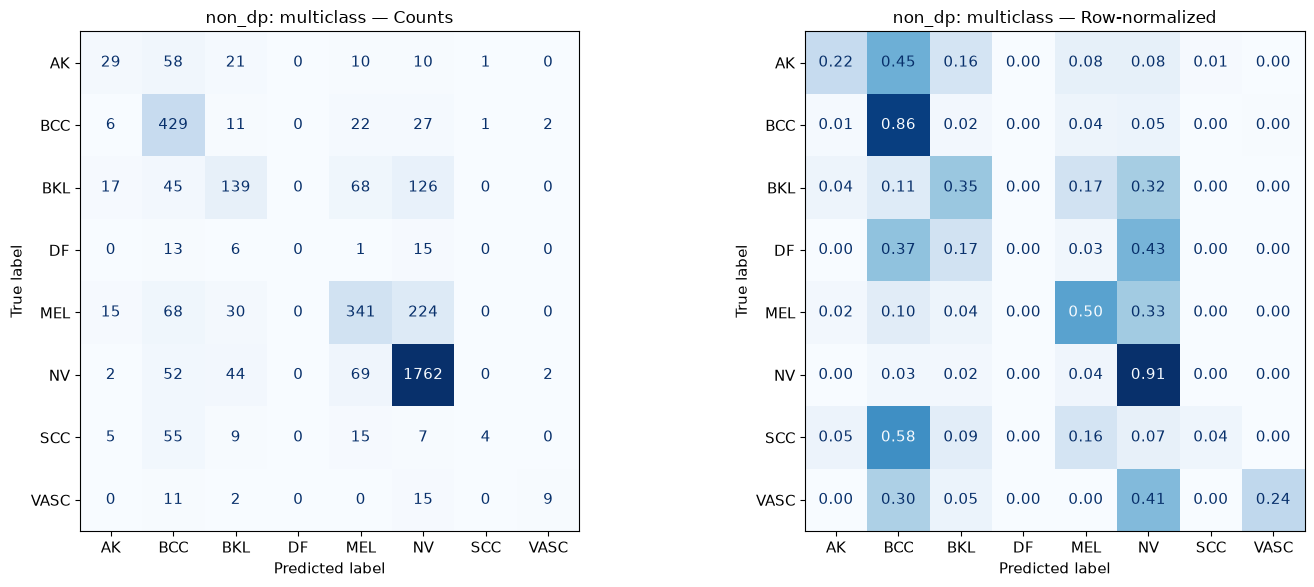

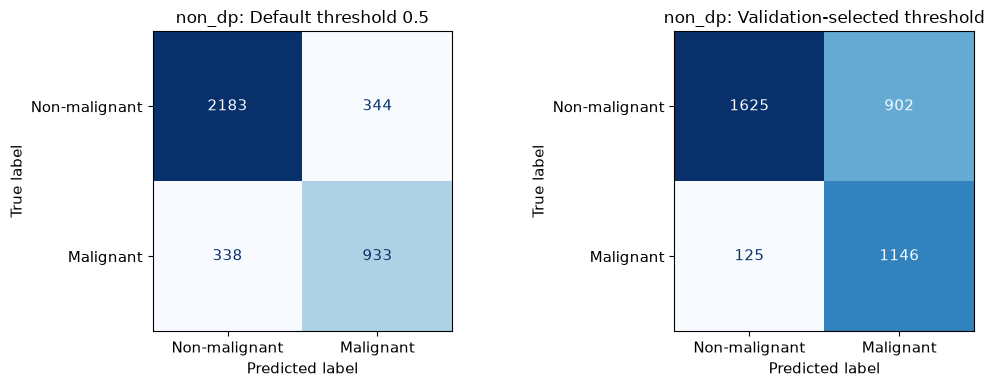

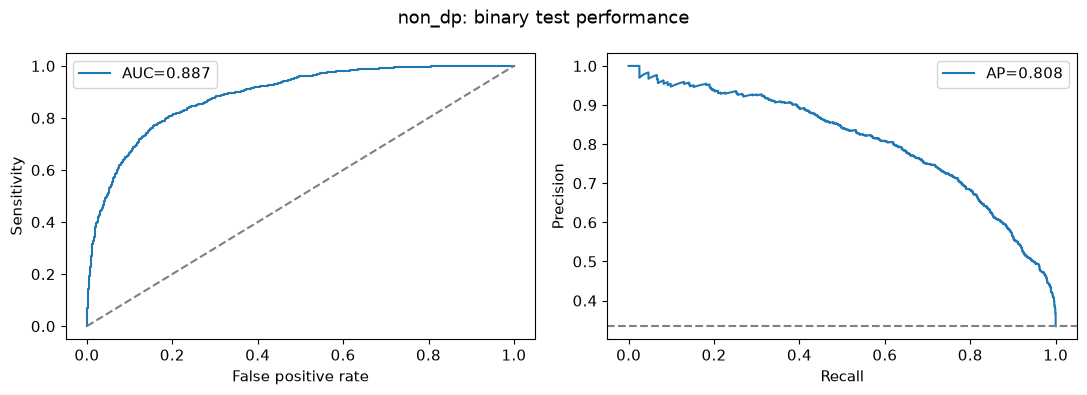

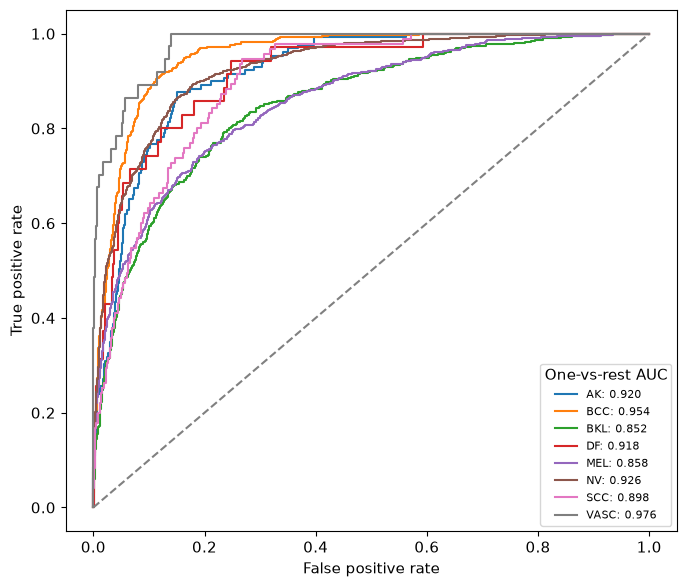

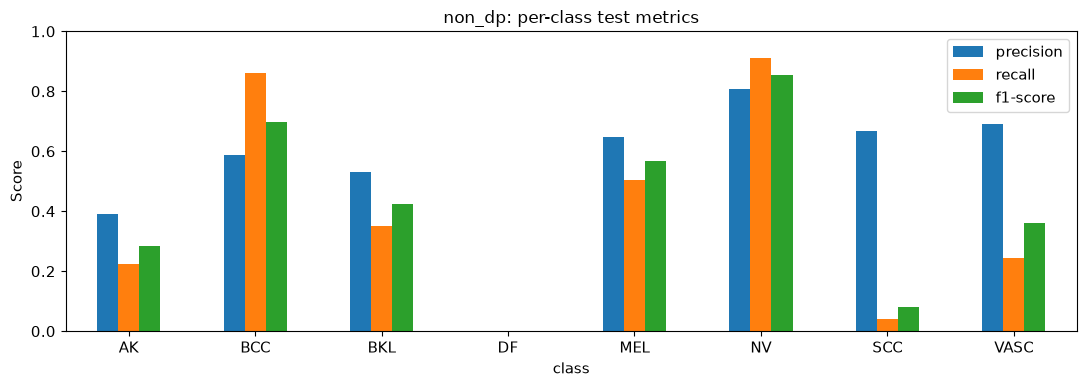

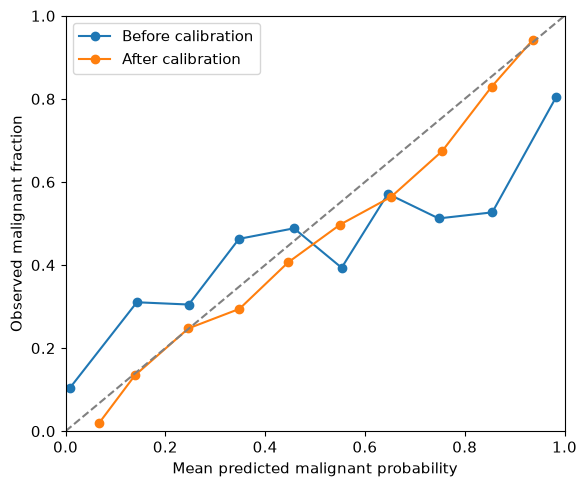

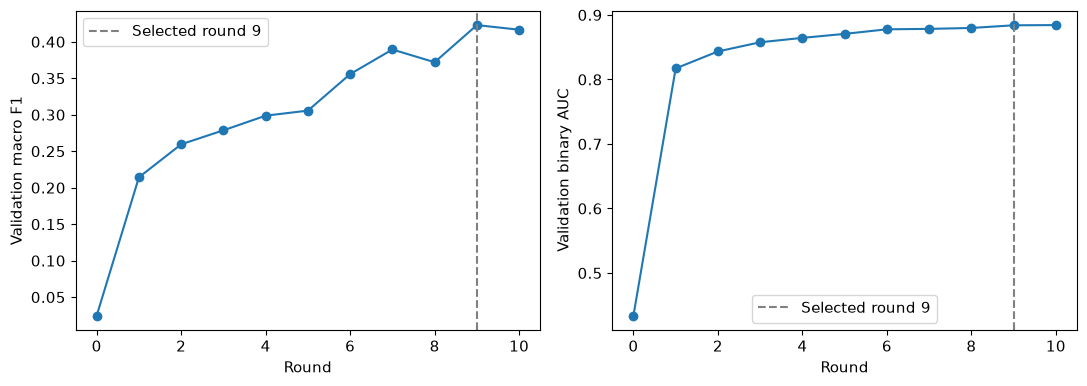

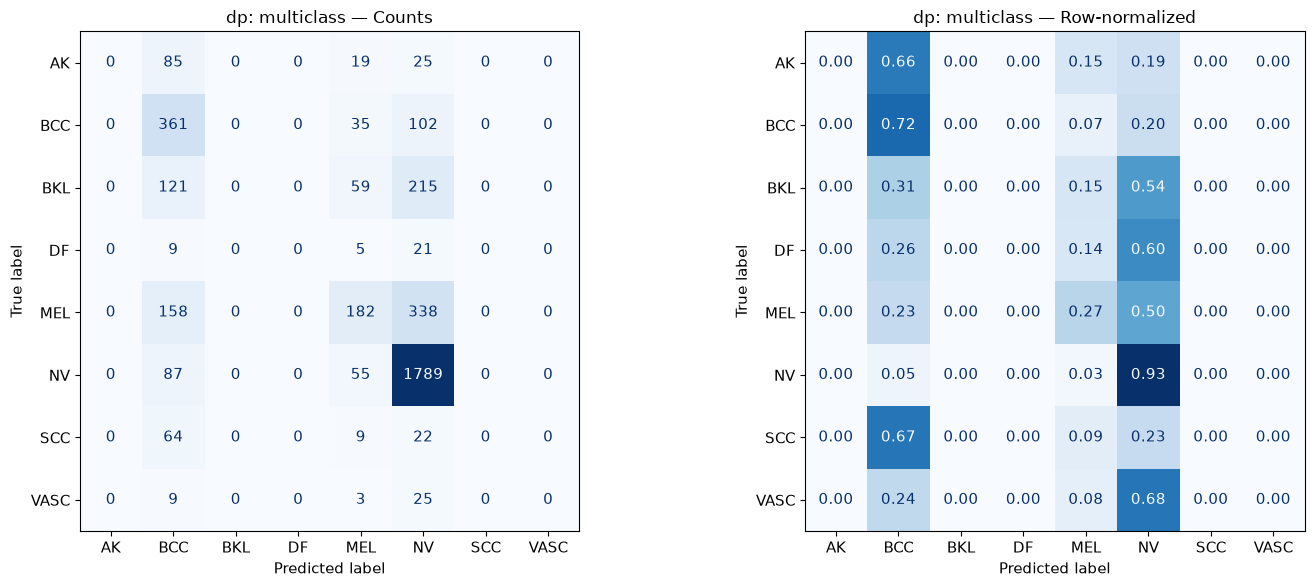

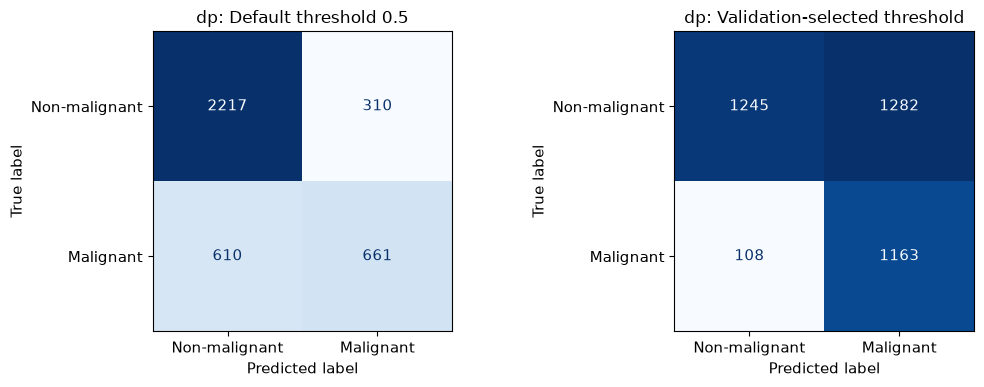

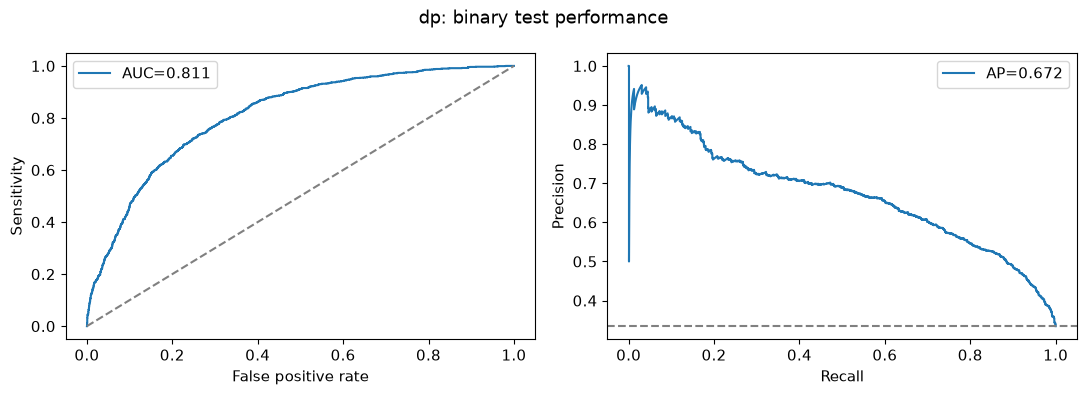

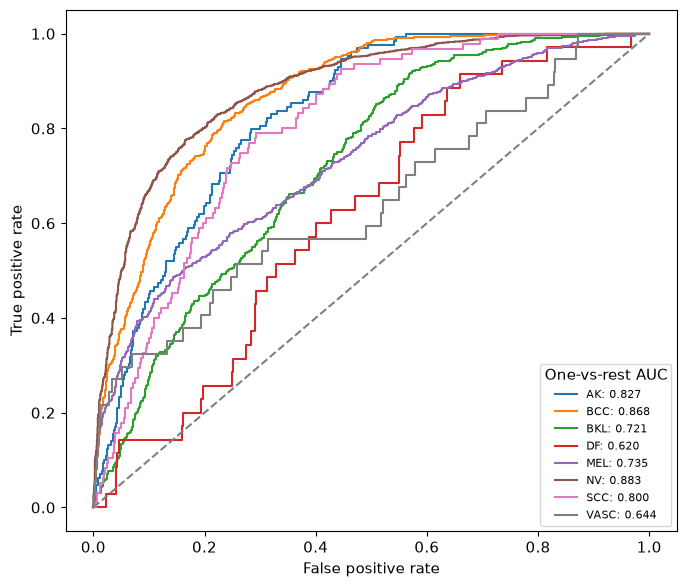

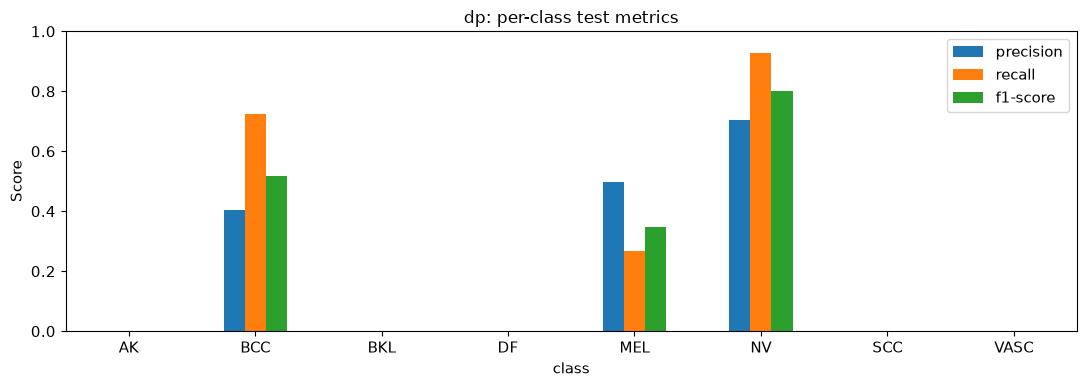

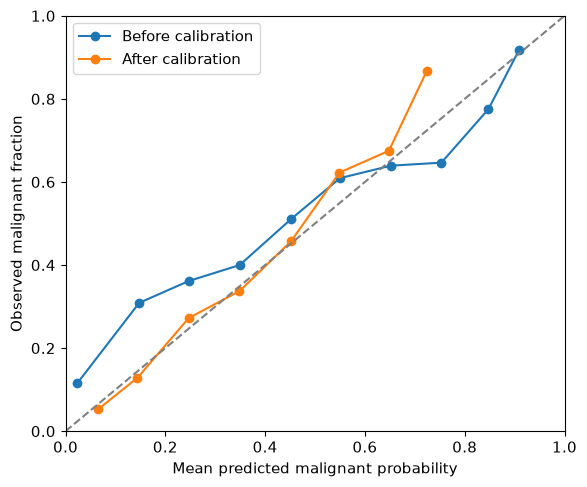

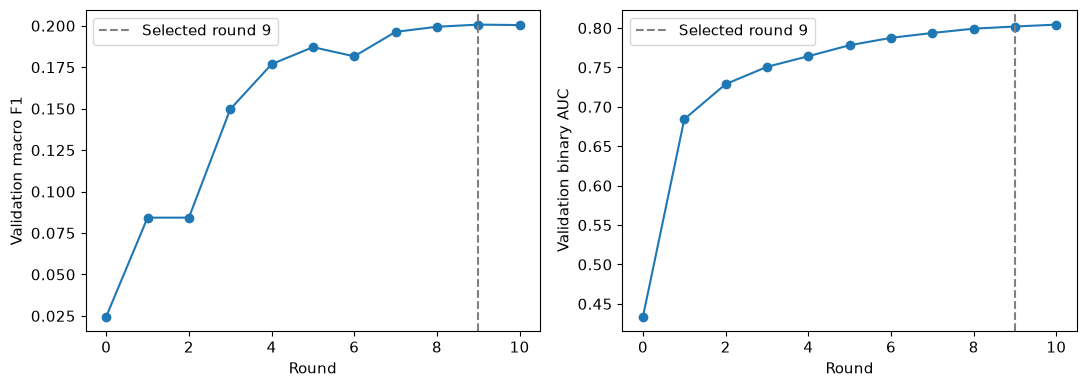

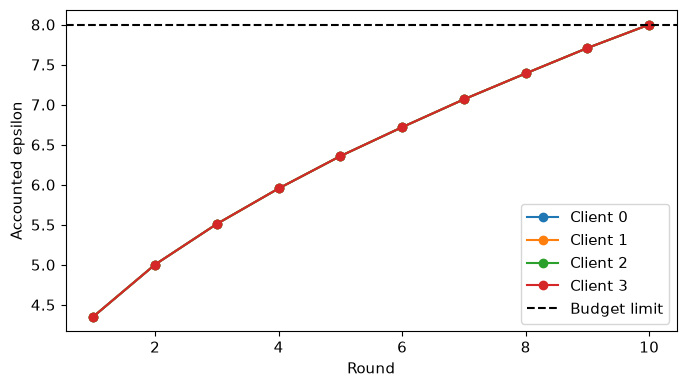

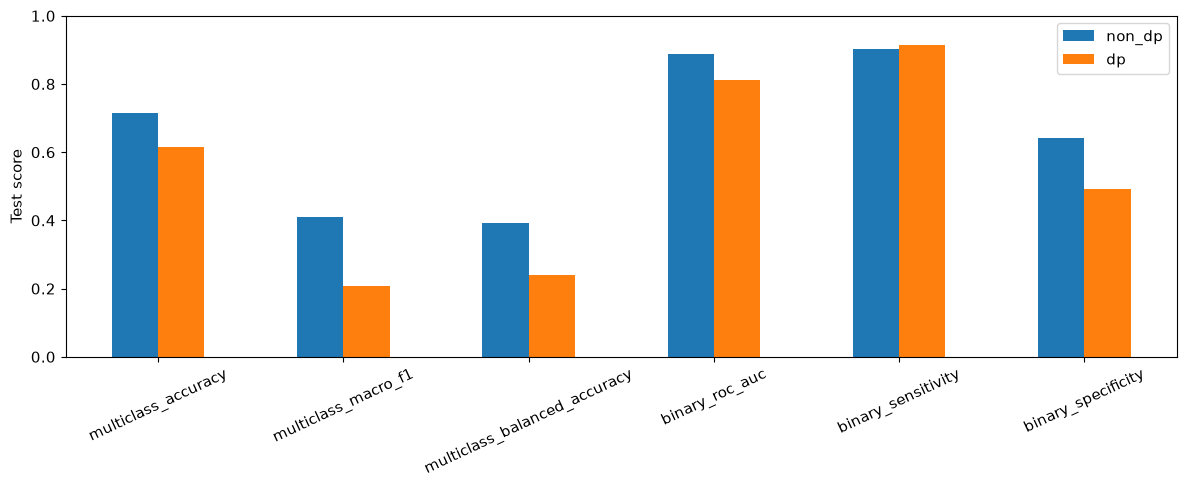

,multiclass_accuracy,multiclass_macro_f1,multiclass_balanced_accuracy,binary_roc_auc,binary_sensitivity,binary_specificity
non_dp,0.7143,0.4086,0.3924,0.8870,0.9017,0.6431
dp,0.6140,0.2085,0.2400,0.8113,0.9150,0.4927


non_dp: fresh bundle reload and one-image inference PASSED.
dp: fresh bundle reload and one-image inference PASSED.

STEP 15 COMPLETED
Figures: C:\SRS(ISIC_2019)\flower_experiments\public_frozen_record_dp_v1\comparison
Inference bundles: C:\SRS(ISIC_2019)\flower_experiments\public_frozen_record_dp_v1\exports
Verified backup: C:\SRS(ISIC_2019)\verified_fl_backups\public_frozen_record_dp_v1_20260923_122904_a2b36c
Verified backup files: 177
Copied notebooks: ['ISIC_Federated_Finetuning.ipynb', 'ISIC_Federated_Main.ipynb']
Backup model reload/inference: PASSED
Save the notebook with Ctrl+S, including these new cells.
Copy the backup to another disk/location for machine-loss protection.
No additional model training performed by Step 15.


In [36]:
# NEW cell.
# Generates figures from saved results and exports reusable inference bundles.
# Client optimizer/accountant checkpoints remain in the experiment directory.
# Copy the verified backup to another disk/location for machine-loss protection.

import shutil
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    precision_recall_curve,
)

FL_COMPARISON_DIR = FL_EXPERIMENT_ROOT / "comparison"
FL_COMPARISON_DIR.mkdir(exist_ok=True)


def save_figure(figure, directory, name):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    figure.tight_layout()
    figure.savefig(directory / f"{name}.png", dpi=300, bbox_inches="tight")
    figure.savefig(directory / f"{name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(figure)


for mode in ("non_dp", "dp"):
    directory = mode_directory(mode)
    figures = directory / "figures"
    predictions = pd.read_csv(directory / "test_predictions.csv")
    history = pd.read_csv(directory / "round_history.csv")
    per_class = pd.read_csv(
        directory / "per_class_metrics.csv", index_col=0
    )

    y = predictions.true_label.to_numpy()
    predicted = predictions.predicted_label.to_numpy()
    yb = predictions.true_binary.to_numpy()
    probability = predictions.binary_probability_calibrated.to_numpy()

    # 1. Multiclass confusion matrices.
    figure, axes = plt.subplots(1, 2, figsize=(15, 6))
    for axis, normalize, title in zip(
        axes, (None, "true"), ("Counts", "Row-normalized")
    ):
        matrix = confusion_matrix(
            y, predicted, labels=np.arange(8), normalize=normalize
        )
        ConfusionMatrixDisplay(
            matrix, display_labels=FL_CLASSES
        ).plot(
            ax=axis, cmap="Blues", colorbar=False,
            values_format=".2f" if normalize else "d",
        )
        axis.set_title(f"{mode}: multiclass — {title}")
    save_figure(figure, figures, "multiclass_confusion")

    # 2. Binary confusion matrices.
    figure, axes = plt.subplots(1, 2, figsize=(11, 4))
    for axis, column, title in zip(
        axes,
        ("binary_prediction_default", "binary_prediction_selected"),
        ("Default threshold 0.5", "Validation-selected threshold"),
    ):
        matrix = confusion_matrix(yb, predictions[column], labels=[0, 1])
        ConfusionMatrixDisplay(
            matrix, display_labels=["Non-malignant", "Malignant"]
        ).plot(ax=axis, cmap="Blues", colorbar=False, values_format="d")
        axis.set_title(f"{mode}: {title}")
    save_figure(figure, figures, "binary_confusion")

    # 3. Binary ROC and precision–recall.
    figure, axes = plt.subplots(1, 2, figsize=(11, 4))
    fpr, tpr, _ = roc_curve(yb, probability)
    precision, recall, _ = precision_recall_curve(yb, probability)

    axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(yb, probability):.3f}")
    axes[0].plot([0, 1], [0, 1], "--", color="gray")
    axes[0].set(xlabel="False positive rate", ylabel="Sensitivity")
    axes[0].legend()

    axes[1].plot(
        recall, precision,
        label=f"AP={average_precision_score(yb, probability):.3f}",
    )
    axes[1].axhline(yb.mean(), linestyle="--", color="gray")
    axes[1].set(xlabel="Recall", ylabel="Precision")
    axes[1].legend()
    figure.suptitle(f"{mode}: binary test performance")
    save_figure(figure, figures, "binary_roc_pr")

    # 4. Multiclass one-vs-rest ROC.
    figure, axis = plt.subplots(figsize=(7, 6))
    for index, name in enumerate(FL_CLASSES):
        truth = (y == index).astype(int)
        scores = predictions[f"probability_{name}"].to_numpy()
        fpr, tpr, _ = roc_curve(truth, scores)
        axis.plot(
            fpr, tpr,
            label=f"{name}: {roc_auc_score(truth, scores):.3f}",
        )
    axis.plot([0, 1], [0, 1], "--", color="gray")
    axis.set(xlabel="False positive rate", ylabel="True positive rate")
    axis.legend(title="One-vs-rest AUC", fontsize=8)
    save_figure(figure, figures, "multiclass_roc")

    # 5. Per-class metrics.
    figure, axis = plt.subplots(figsize=(11, 4))
    per_class[["precision", "recall", "f1-score"]].plot.bar(ax=axis)
    axis.set(ylim=(0, 1), ylabel="Score", title=f"{mode}: per-class test metrics")
    axis.tick_params(axis="x", rotation=0)
    save_figure(figure, figures, "per_class_metrics")

    # 6. Reliability.
    figure, axis = plt.subplots(figsize=(6, 5))
    for suffix, label in (
        ("raw", "Before calibration"),
        ("calibrated", "After calibration"),
    ):
        table = pd.read_csv(directory / f"reliability_{suffix}.csv")
        axis.plot(
            table.mean_probability, table.observed_fraction,
            marker="o", label=label,
        )
    axis.plot([0, 1], [0, 1], "--", color="gray")
    axis.set(
        xlabel="Mean predicted malignant probability",
        ylabel="Observed malignant fraction",
        xlim=(0, 1), ylim=(0, 1),
    )
    axis.legend()
    save_figure(figure, figures, "binary_reliability")

    # 7. Round validation curves.
    figure, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["round"], history.val_macro_f1, marker="o")
    axes[0].set(xlabel="Round", ylabel="Validation macro F1")
    axes[1].plot(history["round"], history.val_binary_auc, marker="o")
    axes[1].set(xlabel="Round", ylabel="Validation binary AUC")
    selected_round = FL_SELECTED[mode]["selected_round"]
    for axis in axes:
        axis.axvline(
            selected_round, linestyle="--", color="gray",
            label=f"Selected round {selected_round}",
        )
        axis.legend()
    save_figure(figure, figures, "validation_round_curves")


# 8. Actual accounted privacy schedule.
privacy_rows = []
for round_id in range(1, FL_PROTOCOL["rounds"] + 1):
    for cid in range(4):
        checkpoint = load_checkpoint(
            mode_directory("dp") / "clients" / f"client_{cid}"
            / f"round_{round_id:03d}.pth"
        )
        privacy_rows.append({
            "round": round_id,
            "client_id": cid,
            "epsilon": checkpoint["epsilon"],
            "accounted_steps": checkpoint["accounted_steps"],
            "committed_updates": checkpoint["committed_updates"],
            "uncertain_slots": checkpoint["uncertain_slots"],
        })

privacy_history = pd.DataFrame(privacy_rows)
save_csv(
    mode_directory("dp") / "privacy_round_history.csv",
    privacy_history,
)

figure, axis = plt.subplots(figsize=(7, 4))
for cid, frame in privacy_history.groupby("client_id"):
    axis.plot(frame["round"], frame.epsilon, marker="o", label=f"Client {cid}")
axis.axhline(
    FL_PROTOCOL["target_epsilon"], linestyle="--",
    color="black", label="Budget limit",
)
axis.set(xlabel="Round", ylabel="Accounted epsilon")
axis.legend()
save_figure(figure, FL_COMPARISON_DIR, "privacy_budget")


# 9. Matched FL comparison.
comparison = pd.DataFrame(FL_TEST_RESULTS).T
save_csv(
    FL_COMPARISON_DIR / "matched_fl_test_comparison.csv",
    comparison, index=True,
)

metrics_to_plot = [
    "multiclass_accuracy",
    "multiclass_macro_f1",
    "multiclass_balanced_accuracy",
    "binary_roc_auc",
    "binary_sensitivity",
    "binary_specificity",
]
figure, axis = plt.subplots(figsize=(12, 5))
comparison[metrics_to_plot].T.plot.bar(ax=axis)
axis.set(ylim=(0, 1), ylabel="Test score")
axis.tick_params(axis="x", rotation=25)
save_figure(figure, FL_COMPARISON_DIR, "matched_fl_comparison")
display(comparison[metrics_to_plot].round(4))

# Optional centralized reference: architecture/training differ.
centralized_path = Path(
    r"C:\SRS(ISIC_2019)\centralized_finetuning_runs"
    r"\cb_finetune_retry_20260922_191654_cb7c0476\test_metrics.json"
)
if centralized_path.is_file():
    centralized_metrics = json.loads(centralized_path.read_text())
    reference = pd.DataFrame({
        "centralized_reference": centralized_metrics,
        **FL_TEST_RESULTS,
    }).T
    save_csv(
        FL_COMPARISON_DIR / "centralized_and_fl_reference.csv",
        reference, index=True,
    )


# 10. Export complete inference bundles and verify fresh loading.
exports = FL_EXPERIMENT_ROOT / "exports"
exports.mkdir(exist_ok=True)

initial = load_checkpoint(FL_INIT_PATH)

for mode in ("non_dp", "dp"):
    selected = load_checkpoint(mode_directory(mode) / "best_fl_model.pth")
    bundle = {
        "format": "isic_fl_inference_v1",
        "mode": mode,
        "architecture": "public_frozen_fusion_gn_v1",
        "classes": list(FL_CLASSES),
        "malignant_indices": [1, 4, 6],
        "selected_round": selected["selected_round"],
        "encoder_state_dict": cpu_tree(initial["encoder_state_dict"]),
        "head_state_dict": cpu_tree(selected["head_state_dict"]),
        "calibration": FL_CALIBRATIONS[mode],
        "decision_policy": FL_POLICIES[mode],
        "preprocessing": {
            "resize": [224, 224],
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225],
        },
        "test_metrics": FL_TEST_RESULTS[mode],
        "privacy_scope": FL_PROTOCOL["scope"],
        "noise_rng": FL_TRAIN_SPEC["noise_rng"],
    }
    save_checkpoint(exports / f"{mode}_inference_bundle.pth", bundle)

del initial


def load_fl_bundle(bundle_path):
    bundle = load_checkpoint(bundle_path)
    if bundle["format"] != "isic_fl_inference_v1":
        raise ValueError("Unknown inference bundle format.")
    if tuple(bundle["classes"]) != tuple(FL_CLASSES):
        raise ValueError("Class mapping mismatch.")

    # Definitions needed after restart:
    # original model architecture + FLFrozenEncoder + FLPrivateHead.
    architecture = ISIC_Fusion_Model(
        num_classes=len(bundle["classes"]), pretrained=False
    )
    encoder = FLFrozenEncoder(architecture.features)
    head = FLPrivateHead(architecture)
    del architecture

    encoder.load_state_dict(bundle["encoder_state_dict"], strict=True)
    head.load_state_dict(bundle["head_state_dict"], strict=True)

    encoder.to(FL_DEVICE).eval()
    head.to(FL_DEVICE).eval()
    return encoder, head, bundle


@torch.inference_mode()
def predict_fl_image(image_path, loaded_bundle):
    encoder, head, bundle = loaded_bundle
    path = Path(image_path)
    if not path.is_file():
        raise FileNotFoundError(path)

    with Image.open(path) as image:
        x = fl_eval_transform(image.convert("RGB")).unsqueeze(0)
    device = next(head.parameters()).device
    output = head(encoder(x.to(device))).float().cpu().numpy()[0]

    calibration = bundle["calibration"]
    p = float(expit(output[8] / calibration["binary_temperature"]))
    class_p = softmax(
        output[:8].astype(np.float64)
        / calibration["multiclass_temperature"]
    )
    threshold = bundle["decision_policy"]["binary_threshold"]

    return {
        "image": path.name,
        "model_mode": bundle["mode"],
        "selected_round": bundle["selected_round"],
        "malignant_model_score_percent": 100 * p,
        "non_malignant_model_score_percent": 100 * (1 - p),
        "binary_threshold": threshold,
        "binary_prediction": (
            "malignant" if p >= threshold else "non-malignant"
        ),
        "top_multiclass_prediction": bundle["classes"][int(class_p.argmax())],
        "class_scores_percent": {
            name: float(100 * score)
            for name, score in zip(bundle["classes"], class_p)
        },
        "note": (
            "Research prediction for dermoscopic lesion images; "
            "not a diagnosis. Non-malignant includes AK. "
            "The binary and multiclass heads may disagree."
        ),
    }


probe_path = read_fl_split("validation").iloc[0].image_path

for mode in ("non_dp", "dp"):
    loaded = load_fl_bundle(exports / f"{mode}_inference_bundle.pth")
    result = predict_fl_image(probe_path, loaded)
    if not np.isfinite(result["malignant_model_score_percent"]):
        raise RuntimeError("Bundle inference check failed.")
    del loaded
    gc.collect()
    print(f"{mode}: fresh bundle reload and one-image inference PASSED.")


# 11. Preserve notebook source and copy the complete experiment.
notebook_names = (
    "ISIC_Federated_Finetuning.ipynb",
    "ISIC_Federated_Main.ipynb",
)
source_directory = FL_EXPERIMENT_ROOT / "notebook_sources"
source_directory.mkdir(exist_ok=True)

copied_notebooks = []
for name in notebook_names:
    candidates = [Path.cwd() / name, Path(r"C:\SRS(ISIC_2019)") / name]
    source = next((path for path in candidates if path.is_file()), None)
    if source is not None:
        shutil.copy2(source, source_directory / name)
        copied_notebooks.append(name)

backup_root = Path(r"C:\SRS(ISIC_2019)\verified_fl_backups")
backup_root.mkdir(exist_ok=True)
backup_path = backup_root / (
    FL_EXPERIMENT_ROOT.name + "_" + time.strftime("%Y%m%d_%H%M%S")
    + "_" + uuid4().hex[:6]
)

shutil.copytree(
    FL_EXPERIMENT_ROOT,
    backup_path,
    ignore=shutil.ignore_patterns("*.lock", "*.tmp"),
)

backup_manifest = {}
for source in FL_EXPERIMENT_ROOT.rglob("*"):
    if not source.is_file() or source.suffix in {".lock", ".tmp"}:
        continue
    relative = source.relative_to(FL_EXPERIMENT_ROOT)
    destination = backup_path / relative
    expected = file_hash(source)
    if file_hash(destination) != expected:
        raise RuntimeError(f"Backup verification failed: {relative}")
    backup_manifest[relative.as_posix()] = expected

save_json(backup_path / "backup_manifest.json", backup_manifest)

# Verify loading from the backup itself.
backup_loaded = load_fl_bundle(
    backup_path / "exports" / "dp_inference_bundle.pth"
)
backup_prediction = predict_fl_image(probe_path, backup_loaded)
del backup_loaded
gc.collect()

print("\nSTEP 15 COMPLETED")
print("Figures:", FL_COMPARISON_DIR)
print("Inference bundles:", exports)
print("Verified backup:", backup_path)
print("Verified backup files:", len(backup_manifest))
print("Copied notebooks:", copied_notebooks)
print("Backup model reload/inference: PASSED")
print("Save the notebook with Ctrl+S, including these new cells.")
print("Copy the backup to another disk/location for machine-loss protection.")
print("No additional model training performed by Step 15.")

# Later use — after loading the architecture and inference definitions:
#
# loaded_model = load_fl_bundle(
#     r"C:\SRS(ISIC_2019)\flower_experiments"
#     r"\public_frozen_record_dp_v1\exports\dp_inference_bundle.pth"
# )
# result = predict_fl_image(
#     r"C:\path\to\your\actual_dermoscopic_image.jpg",
#     loaded_model,
# )
# print(json.dumps(result, indent=2))